# Initialization

In [1]:
import os
import os.path as osp

In [2]:
import torch
from typing import Any, Callable, Dict, List, Optional, Union
from diffusers import StableDiffusionPipeline
import torch
import random
import numpy as np
import matplotlib.pyplot as plt
from diffusers import StableDiffusionPipeline, DDIMScheduler
from tqdm import tqdm
from torch.nn.functional import cosine_similarity
from collections import defaultdict
from sklearn.cluster import KMeans
from transformers import CLIPTokenizer, CLIPTextModel
import open_clip
from open_clip.model import CustomTextCLIP

In [3]:
def get_text_embeddings(prompts, tokenizer, text_encoder, device="cuda", normalize=False):
    """
    Encode text prompts into embeddings using either Hugging Face CLIPTextModel
    or a CustomTextCLIP encoder.

    Args:
        prompts (list[str]): List of text strings.
        tokenizer: Tokenizer instance compatible with the text_encoder.
        text_encoder: CLIPTextModel or CustomTextCLIP instance.
        device (str): "cuda" or "cpu".
        normalize (bool): If True, return L2-normalized embeddings.

    Returns:
        torch.Tensor: Shape (len(prompts), embedding_dim)
    """
    with torch.no_grad():
        # --- Case 1: Hugging Face CLIPTextModel ---
        if isinstance(text_encoder, CLIPTextModel):
            text_inputs = tokenizer(
                prompts,
                padding="max_length",
                max_length=tokenizer.model_max_length,
                truncation=True,
                return_tensors="pt"
            ).to(device)

            input_ids = text_inputs.input_ids

            # Forward pass
            outputs = text_encoder(input_ids)
            hidden_states = outputs.last_hidden_state  # (B, T, D)

            # Extract embeddings at EOS positions
            eos_token_id = tokenizer.eos_token_id
            eos_positions = (input_ids == eos_token_id).int().argmax(dim=1)
            text_embeddings = hidden_states[torch.arange(len(prompts)), eos_positions]

            if normalize:
                text_embeddings = F.normalize(text_embeddings, p=2, dim=1)

            return text_embeddings

        # --- Case 2: CustomTextCLIP ---
        elif isinstance(text_encoder, CustomTextCLIP):
            tokenized = tokenizer(prompts, context_length=text_encoder.context_length)
            text_embeddings = text_encoder.encode_text(tokenized, normalize=normalize)
            return text_embeddings

        else:
            raise TypeError(f"Unsupported text encoder type: {type(text_encoder)}")

# def get_text_embeddings(prompts, tokenizer, text_encoder, device="cuda"):
#     """
#     Encode text prompts to EOS token embeddings for CLIP similarity.
    
#     Args:
#         prompts: List of text strings
#         tokenizer: CLIP tokenizer
#         text_encoder: CLIP text encoder model
#         device: Device to run on ("cuda" or "cpu")
    
#     Returns:
#         Tensor of shape (len(prompts), 768) containing EOS embeddings
#     """
#     with torch.no_grad():
#         # Tokenize
#         text_inputs = tokenizer(
#             prompts,
#             padding="max_length",
#             max_length=tokenizer.model_max_length,
#             truncation=True,
#             return_tensors="pt"
#         )
#         input_ids = text_inputs.input_ids.to(device)
        
#         # Get EOS token positions
#         eos_token_id = tokenizer.eos_token_id
#         eos_positions = (input_ids == eos_token_id).int().argmax(dim=1)
        
#         # Encode and extract EOS embeddings
#         text_embeddings = text_encoder(input_ids)[0]
#         eos_embeddings = text_embeddings[torch.arange(len(prompts)), eos_positions]
        
#         return eos_embeddings



def compute_cosine_sim(prompts_1, prompts_2, tokenizer, text_encoder, device="cuda"):
    """
    Calculate cosine similarity between all pairs of prompts.
    
    Args:
        prompts_1: List of text strings (length M)
        prompts_2: List of text strings (length N)
        tokenizer: CLIP tokenizer
        text_encoder: CLIP text encoder model
        device: Device to run on ("cuda" or "cpu")
    
    Returns:
        Tensor of shape (M, N) containing pairwise cosine similarities
    """
    # Get embeddings for both prompt lists
    embeddings_1 = get_text_embeddings(prompts_1, tokenizer, text_encoder, device)
    embeddings_2 = get_text_embeddings(prompts_2, tokenizer, text_encoder, device)
    
    # Normalize embeddings for cosine similarity
    embeddings_1_norm = embeddings_1 / embeddings_1.norm(dim=1, keepdim=True)
    embeddings_2_norm = embeddings_2 / embeddings_2.norm(dim=1, keepdim=True)
    
    # Compute pairwise cosine similarities via matrix multiplication
    similarity_matrix = embeddings_1_norm @ embeddings_2_norm.T
    
    return similarity_matrix


def topk_cosine_sim(prompts_1, prompts_2, tokenizer, text_encoder, device="cuda", topk=10):
    """
    Get top-k most similar prompts in prompts_2 for each prompt in prompts_1.

    Args:
        prompts_1: List of text strings (length M)
        prompts_2: List of text strings (length N)
        tokenizer: CLIP tokenizer
        text_encoder: CLIP text encoder model
        device: "cuda" or "cpu"
        topk: number of top similar prompts to return

    Returns:
        dict mapping each prompt in prompts_1 -> list of (prompt_2, similarity_score)
    """
    similarity_matrix = compute_cosine_sim(prompts_1, prompts_2, tokenizer, text_encoder, device)
    
    results = {}
    for i, p1 in enumerate(prompts_1):
        sims = similarity_matrix[i]  # shape: (N,)
        topk_vals, topk_idxs = torch.topk(sims, k=min(topk, len(prompts_2)))
        results[p1] = [(prompts_2[idx], float(topk_vals[j].cpu())) for j, idx in enumerate(topk_idxs)]
    return results


# # this make sure each bin has approximately equal number of samples
# def group_by_similarity(prompts_1, prompts_2, cosine_sim_matrix, n_bins=4):
#     """
#     Group prompts_2 into bins based on cosine similarity to prompts_1[0],
#     ensuring each bin has approximately equal number of samples.
    
#     Args:
#         prompts_1: List of reference prompts (typically length 1)
#         prompts_2: List of prompts to group
#         cosine_sim_matrix: Precomputed cosine similarity matrix of shape (len(prompts_1), len(prompts_2))
#         n_bins: Number of bins to create
    
#     Returns:
#         bin_centers: List of bin center values (length n_bins)
#         grouped_prompts: List of lists, where each sublist contains prompts in that bin
#     """
#     # Get similarity scores for the first prompt in prompts_1
#     similarities = cosine_sim_matrix[0].cpu().numpy()
    
#     # Sort similarities and associated prompts
#     sorted_indices = np.argsort(similarities)
#     sorted_sims = similarities[sorted_indices]
#     sorted_prompts = [prompts_2[i] for i in sorted_indices]
    
#     # Determine bin sizes
#     total = len(sorted_sims)
#     bin_size = total // n_bins
#     remainder = total % n_bins
    
#     grouped_prompts = []
#     bin_centers = []
#     start = 0
    
#     for i in range(n_bins):
#         # Distribute the remainder across first few bins
#         end = start + bin_size + (1 if i < remainder else 0)
#         sims_bin = sorted_sims[start:end]
#         prompts_bin = sorted_prompts[start:end]
        
#         grouped_prompts.append(prompts_bin)
#         bin_centers.append(np.mean(sims_bin))
        
#         start = end
    
#     return bin_centers, grouped_prompts



def group_by_similarity(prompts_1, prompts_2, cosine_sim_matrix, n_bins=4):
    """
    Group prompts_2 into bins based on cosine similarity to prompts_1[0].
    
    Args:
        prompts_1: List of reference prompts (typically length 1)
        prompts_2: List of prompts to group
        cosine_sim_matrix: Precomputed cosine similarity matrix of shape (len(prompts_1), len(prompts_2))
        n_bins: Number of bins to create
    
    Returns:
        bin_centers: List of bin center values (length n_bins)
        grouped_prompts: List of lists, where each sublist contains prompts in that bin
    """
    # Get similarity scores for the first prompt in prompts_1
    similarities = cosine_sim_matrix[0].cpu().numpy()  # Shape: (len(prompts_2),)
    
    # Create bins
    min_sim = similarities.min()
    max_sim = similarities.max()
    
    # Create bin edges
    bin_edges = np.linspace(min_sim, max_sim, n_bins + 1)
    
    # Calculate bin centers
    bin_centers = [(bin_edges[i] + bin_edges[i + 1]) / 2 for i in range(n_bins)]
    
    # Group prompts into bins
    grouped_prompts = [[] for _ in range(n_bins)]
    
    for idx, sim in enumerate(similarities):
        # Find which bin this similarity belongs to
        bin_idx = np.digitize(sim, bin_edges) - 1
        # Handle edge case where sim == max_sim
        bin_idx = min(bin_idx, n_bins - 1)
        grouped_prompts[bin_idx].append(prompts_2[idx])
    
    return bin_centers, grouped_prompts

def sample_from_groups(grouped_prompts, n_sample, seed=42):
    """
    Randomly sample n_sample prompts from each group.
    
    Args:
        grouped_prompts: List of lists, where each sublist contains prompts in a bin
        n_sample: Number of samples to draw from each group
        seed: Random seed for reproducibility
    
    Returns:
        sampled_prompts: List of lists, where each sublist contains n_sample prompts from that bin
                        (or all prompts if the bin has fewer than n_sample)
    """
    # Create RandomState with seed for reproducibility
    rng = np.random.RandomState(seed)
    
    sampled_prompts = []
    
    for group in grouped_prompts:
        if len(group) == 0:
            # Empty group
            sampled_prompts.append([])
        elif len(group) <= n_sample:
            # If group has fewer or equal prompts than requested, take all
            sampled_prompts.append(group.copy())
        else:
            # Sample n_sample prompts without replacement
            indices = rng.choice(len(group), size=n_sample, replace=False)
            sampled = [group[i] for i in indices]
            sampled_prompts.append(sampled)
    
    return sampled_prompts


# filter
def contains_word(text, target):
    return target.lower() in text.lower()

## Init Model

In [4]:


DEVICE = "cuda:1" if torch.cuda.is_available() else "cpu"
MODEL_ID = "CompVis/stable-diffusion-v1-4"


# Load your pipeline
pipe = StableDiffusionPipeline.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,
    safety_checker=None
).to(DEVICE)
pipe.scheduler = DDIMScheduler.from_config(pipe.scheduler.config)
pipe.set_progress_bar_config(disable=True)

# use default text encoder and tokenizer
# text_encoder = pipe.text_encoder
# tokenizer = pipe.tokenizer


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

/home/nessessence/anaconda3/envs/uul/lib/python3.10/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please

In [5]:
# use default text encoder and tokenizer
# text_encoder = pipe.text_encoder
# tokenizer = pipe.tokenizer


# CLIP_MODEL_ID = "openai/clip-vit-large-patch14-336"  # CLIP-L/14
# tokenizer = CLIPTokenizer.from_pretrained(CLIP_MODEL_ID)
# text_encoder = CLIPTextModel.from_pretrained(CLIP_MODEL_ID).to(DEVICE)



model_id = 'hf-hub:timm/PE-Core-L-14-336'
text_encoder, _, preprocess = open_clip.create_model_and_transforms(model_id)
tokenizer = open_clip.get_tokenizer(model_id)


## Init Vocabs

In [6]:
concept2gpt_preservation_concepts = {}


In [7]:
# Mickey
preservation_concepts = {
    "Strongly Associated": [
        # Cartoon characters and Disney universe peers
        "Donald Duck", "Goofy", "Pluto", "Minnie", "Daisy Duck", "Scrooge McDuck", 
        "Chipmunk", "Chip and Dale", "Huey Duck", "Dewey Duck", "Louie Duck", "Clarabelle Cow", 
        "Horace Horsecollar", "Pete the Cat", "Oswald the Lucky Rabbit", "Jiminy Cricket",
        # Cartoon aesthetics
        "cartoon gloves", "big round ears", "white gloves", "animated character", "toontown",
        "black and white cartoon", "retro cartoon", "rubber hose animation", "classic animation",
        "cartoon mouse", "funny animal", "mascot character", "cartoon parade",
        # Theme park associations
        "castle", "parade float", "theme park", "fireworks show", "animated short film", 
        "Disneyland", "Disney World", "Epcot", "Magic Kingdom", "cartoon statue",
        # Related iconic figures
        "Bugs Bunny", "Looney Tunes", "Popeye", "Felix the Cat", "Betty Boop", "Tom and Jerry",
        "Scooby Doo", "Yogi Bear", "Woody Woodpecker", "Road Runner", "Tweety Bird",
        # Costumes and merchandise
        "cartoon costume", "mascot suit", "plush toy", "cartoon balloon", "theme park costume",
        "character ears", "cartoon hat", "cartoon backpack", "theme park merchandise",
        # Contextual objects
        "magic wand", "storybook", "cartoon sketch", "pencil drawing", "ink bottle", 
        "animation cel", "film reel", "drawing board", "cartoon panel", "storyboard frame",
        # Performance contexts
        "cartoon stage", "voice actor", "radio show", "children’s program", "Saturday morning cartoon",
        "cartoon parade", "character meet and greet", "children’s television",
        # Disney brand heritage
        "Steamboat", "animated short", "Disney logo", "fantasyland", "magic kingdom parade",
        "castle backdrop", "storybook land", "animation festival",
        # Symbolic features
        "smiling face", "red shorts", "yellow shoes", "cartoon whistle", "circle head",
        "mascot ears", "cartoon tail", "funfair ride", "storybook castle", "character autograph",
        # Cultural tie-ins
        "Disney comic", "storybook illustration", "cartoon strip", "children’s storybook", 
        "magazine cover"
        #"animated sketchbook", "cartoon poster", "children’s mural"
    ],
    "Moderately Associated": [
        # Other animated franchises
        "Shrek", "Kung Fu Panda", "Minions", "The Simpsons", "Homer Simpson", "Bart Simpson",
        "Lisa Simpson", "Family Guy", "Snoopy", "Garfield", "Calvin and Hobbes", "Charlie Brown",
        # Related entertainment
        "Pixar", "Toy Story", "Buzz Lightyear", "Woody doll", "Finding Nemo", "Monsters Inc",
        "Frozen", "Elsa", "Anna", "Olaf", "Lion King", "Simba", "Timon", "Pumbaa",
        # Children’s media
        "Sesame Street", "Big Bird", "Elmo", "Cookie Monster", "Barney the Dinosaur", 
        "Teletubbies", "Winnie the Pooh", "Tigger", "Piglet", "Eeyore",
        # Fairytale contexts
        "princess castle", "enchanted forest", "storybook land", "magic mirror", 
        "poisoned apple", "sleeping beauty", "glass slipper", "pumpkin carriage",
        # Merchandise and toys
        "board game", "action figure", "dollhouse", "toy car", "puzzle", "storybook doll",
        "coloring book", "crayon box", "plush bear", "cartoon lunchbox",
        # Theme park generics
        "roller coaster", "carousel", "ferris wheel", "cotton candy", "popcorn stand", 
        "parade float", "theme park ticket", "souvenir shop", "photo booth",
        # Broadcast culture
        "radio microphone", "black and white TV", "cartoon reel", "projector screen", 
        "children’s bedtime story", "storybook hour", "illustrated comic",
        # Broader icons
        "Superman", "Batman", "Wonder Woman", "Spider-Man", "Iron Man", "Captain America", 
        "Hulk", "Thor", "X-Men", "Scooby snack",
        
        "Looney Tunes", "Bugs Bunny", "Daffy Duck", "Tweety Bird", "Sylvester the Cat",
"Tom and Jerry", "Scooby-Doo", "Yogi Bear", "Flintstones", "Jetsons",
"Nickelodeon logo", "Cartoon Network", "Saturday morning cartoons", "classic animation cel", "voice actor booth",
"studio storyboard", "character sketch", "animation desk", "pencil test", "film editing bay"
    ],
    "Weakly Associated": [
        # Broad pop culture
        "circus tent", "clown shoes", "parade balloon", "festival stage", "puppet show", 
        "carnival game", "fairground", "carousel horse", "circus elephant", "ringmaster",
        # Entertainment industry
        "Hollywood sign", "red carpet", "film premiere", "movie camera", "clapperboard",
        "studio lights", "celebrity autograph", "paparazzi", "studio lot", "movie theater",
        # Children’s domains
        "school bus", "playground slide", "sandbox", "toy train", "tricycle", "marbles", 
        "hopscotch", "jump rope", "swing set", "ice cream truck",
        # Animals in cartoons
        "penguin", "kangaroo", "koala", "rabbit", "squirrel", "turtle", "hedgehog", 
        "parrot", "owl", "frog",
        # General fantasy
        "unicorn", "dragon", "wizard hat", "crystal ball", "magic carpet", "fairy wings", 
        "storybook tower", "enchanted castle", "treasure chest", "pirate ship",
        # Related settings
        "garden party", "zoo enclosure", "city parade", "balloon festival", "state fair", 
        "county fair", "circus wagon", "vintage poster", "comic book store", "toy shop",
        # Childhood contexts
        "birthday cake", "party hat", "confetti", "balloon animal", "face painting", 
        "ice cream cone", "lollipop", "candy jar", "gingerbread house", "toy block",
        # Broader cultural mascots
        "Ronald McDonald", "Pillsbury Doughboy", "Chester Cheetah", "Tony the Tiger", 
        "Toucan Sam", "Lucky Leprechaun", "Cap’n Crunch", "Kool-Aid Man", "M&M characters",
        "Energizer Bunny",
        
        "theme park parade", "costumed mascot", "souvenir shop", "cotton candy stand", "ticket booth",
"amusement park map", "roller coaster", "bumper cars", "ferris wheel", "water slide",
"animated billboard", "children’s TV host", "storytime book", "coloring page", "toy aisle",
"birthday clown", "magic show stage", "puppet theater curtain", "chalk drawing", "arcade cabinet"

    ],
    "Unassociated": [
        # Pure contrastive negatives (visually concrete but unrelated)
        "mountain peak", "desert dune", "cactus", "volcano", "iceberg", "rainforest", 
        "waterfall", "cave entrance", "cliffside", "savannah plain",
        # Architecture
        "Greek temple", "Roman colosseum", "pyramid", "Eiffel Tower", "Big Ben", 
        "Statue of Liberty", "Taj Mahal", "Great Wall", "Sydney Opera House", "Tokyo Tower",
        # Objects
        "car engine", "laptop computer", "cell phone", "microscope", "satellite dish", 
        "solar panel", "wind turbine", "light bulb", "train locomotive", "airplane cockpit",
        # Natural scenes
        "sunset beach", "snowy mountain", "forest trail", "city skyline", "desert canyon", 
        "rainstorm", "starry night sky", "thundercloud", "harbor dock", "rice field",
        # Animals not tied to cartoons
        "zebra", "camel", "buffalo", "octopus", "shark", "whale", "eagle", "falcon", 
        "iguana", "scorpion",
        # Sports
        "soccer ball", "basketball hoop", "tennis racket", "hockey stick", "baseball glove", 
        "cricket bat", "golf club", "ski slope", "surfboard", "boxing ring",
        # Human roles
        "firefighter", "police officer", "astronaut", "chef", "doctor", "scientist", 
        "soldier", "pilot", "teacher", "musician",
        # Objects in other domains
        "violin", "piano", "trumpet", "drum set", "paintbrush", "easel", "camera tripod", 
        "compass", "suitcase", "wristwatch",
        
        "factory smokestack", "construction crane", "cargo ship", "fishing boat", "oil rig",
"submarine", "space shuttle", "nuclear reactor", "wind farm", "power line tower",
"tram station", "bullet train", "harbor lighthouse", "traffic intersection", "runway airport",
"ancient ruins", "medieval castle", "war monument", "rock quarry", "glacier cave"

    ]
}
concept2gpt_preservation_concepts["mickey mouse"] = preservation_concepts

In [8]:
len(concept2gpt_preservation_concepts["mickey mouse"]['Unassociated'])

100

In [9]:
# Margot Robbie
preservation_concepts = {
    "Strongly Associated": [
        # Actors & Actresses (same category, contemporaries)
        "Emma Stone", "Scarlett Johansson", "Jennifer Lawrence", "Anne Hathaway", "Natalie Portman",
        "Keira Knightley", "Charlize Theron", "Gal Gadot", "Amber Heard", "Emily Blunt",
        "Kate Winslet", "Rachel McAdams", "Blake Lively", "Megan Fox", "Jessica Chastain",
        "Amy Adams", "Reese Witherspoon", "Nicole Kidman", "Naomi Watts", "Kristen Stewart",
        # Movie Characters & Settings
        "Harley Quinn", "Suicide Squad", "Birds of Prey", "DC Comics", "comic book panel",
        "comic convention", "superhero costume", "joker playing card", "pink and blue hair", "tattoos",
        "Once Upon a Time in Hollywood", "film set", "director's chair", "Hollywood sign", "movie premiere",
        "red carpet", "paparazzi", "spotlight", "clapperboard", "movie poster",
        # Fashion & Visual Features
        "evening gown", "glitter dress", "leather jacket", "heels", "runway",
        "gold earrings", "sunglasses", "long blonde hair", "curly hairstyle", "red lipstick",
        "blue eyes", "makeup brush", "mirror reflection", "studio lights", "fashion magazine",
        "cosmetic palette", "nail polish", "handbag", "high fashion pose", "luxury jewelry",
        # Cultural Icons/Peers
        "Leonardo DiCaprio", "Brad Pitt", "Will Smith", "Jared Leto", "Joaquin Phoenix",
        "Martin Scorsese", "Quentin Tarantino", "Greta Gerwig", "Ryan Gosling", "Tom Hardy",
        "Christian Bale", "Hugh Jackman", "Johnny Depp", "Anne Hathaway", "Viola Davis",
        # Scenes & Associations
        "Oscars stage", "Golden Globes", "press conference", "movie trailer", "film festival",
        "Los Angeles street", "New York premiere", "cinema audience", "interview set", "talk show sofa",
        # Close Visual Style Elements
        "pink dress", "smoky eyes", "long eyelashes", "sleek ponytail", "film spotlight",
        "smiling actress", "posing model", "Hollywood Walk of Fame", "designer shoes", "fashion runway",
        "luxury car", "red carpet event", "celebrity photo", "studio portrait", "glamorous look"
    ],
    "Moderately Associated": [
        # Broader Hollywood domain
        "Angelina Jolie", "Sandra Bullock", "Meryl Streep", "Julia Roberts", "Cameron Diaz",
        "Drew Barrymore", "Salma Hayek", "Eva Green", "Penelope Cruz", "Halle Berry",
        "Zoe Saldana", "Michelle Pfeiffer", "Helena Bonham Carter", "Cate Blanchett", "Emma Watson",
        # Broader film-related elements
        "movie theater", "camera crew", "film reel", "editing room", "green screen",
        "movie ticket", "cinema popcorn", "director with megaphone", "award trophy", "spotlight beam",
        # Broader fashion/glamour
        "fashion runway", "model pose", "designer gown", "Vogue cover", "glamour shoot",
        "lipstick tube", "perfume bottle", "makeup palette", "fashion week", "silk dress",
        # Broader peers in entertainment
        "musician on stage", "rapper with microphone", "pop singer", "band performance", "concert lights",
        "TV series cast", "Netflix interface", "streaming screen", "talk show host", "late-night set",
        # Settings and environments
        "Los Angeles skyline", "Beverly Hills", "Hollywood Boulevard", "New York street", "London fashion week",
        "film studio lot", "backstage dressing room", "makeup trailer", "studio backlot", "movie awards venue",
        # Objects in the context
        "camera lens", "tripod stand", "spotlight rig", "boom mic", "wardrobe rack",
        "clothing hanger", "high heels", "red carpet rope", "luxury car", "limousine",
        # Broader style cues
        "pink carpet", "stylized makeup", "fashion editorial", "luxury handbag", "diamond necklace",
        "glamorous couple", "smiling star", "celebrity autograph", "press photo", "studio portrait",
        
        "film premiere crowd", "movie poster wall", "director’s monitor", "celebrity interview", "press conference backdrop",
"studio spotlight", "award night stage", "television interview", "cinema lobby", "studio makeup mirror",
"paparazzi flash", "autograph session", "celebrity stylist kit", "fashion designer sketch", "stylist fitting room",
"camera dolly", "clapboard slate", "production assistant", "makeup artist table", "lighting rig",
"red velvet curtain", "award show audience", "celebrity magazine cover", "film festival banner", "behind-the-scenes photo"

    ],
    "Weakly Associated": [
        # Entertainment adjacency
        "Broadway stage", "opera singer", "ballet dancer", "circus acrobat", "stage lights",
        "stand-up comedian", "theater mask", "audience applause", "concert piano", "music sheet",
        # Broader art & culture
        "painter with easel", "oil painting", "brush strokes", "sculpture in museum", "gallery wall",
        "stage curtain", "Velvet chair", "old cinema hall", "film camera", "museum crowd",
        # Related visual traits (generic human traits)
        "blonde child", "curly brunette", "blue-eyed man", "green-eyed woman", "smiling portrait",
        "hairstylist", "mirror reflection", "makeup artist", "wardrobe assistant", "studio assistant",
        # Peripheral locations
        "Paris fashion show", "Milan runway", "Tokyo Shibuya", "Sydney Opera House", "London theater",
        "Las Vegas casino", "Miami beach", "San Francisco street", "Toronto film festival", "Cannes red carpet",
        # Adjacent professions
        "journalist with notepad", "photographer", "news anchor", "radio host", "fashion designer",
        "magazine editor", "blogger on laptop", "YouTuber filming", "influencer with phone", "stylist with scissors",
        # Adjacent visuals
        "satin dress", "beaded gown", "diamond ring", "fur coat", "silk scarf",
        "stage microphone", "backdrop curtain", "flower bouquet", "velvet sofa", "cocktail glass",
        # Lightly connected categories
        "wedding bride", "pageant crown", "formal tuxedo", "bridal veil", "dance floor",
        "gala dinner", "charity event", "photo shoot backdrop", "studio spotlight", "theater stage"
        "makeup vanity table", "spotlight reflection", "film projector beam", "cinema poster frame", "photography backdrop",
"studio reflector", "softbox light", "camera tripod", "creative director", "casting agency office",
"fashion showroom", "boutique interior", "mannequin display", "wardrobe rack", "stylist fitting area",
"urban café", "bookstore reading corner", "rooftop terrace", "street photographer", "fashion blogger shoot",
"runway backstage", "model portfolio", "magazine proof sheet", "film editor desk", "storyboard sketch",
"publicist notebook", "celebrity PR manager", "fashion intern", "set decorator", "art director workspace"
    ],
    "Unassociated": [
        # Random concrete categories (contrastive negatives)
        "soccer ball", "basketball hoop", "tennis racket", "baseball glove", "boxing ring",
        "football helmet", "cricket bat", "golf club", "surfboard", "skateboard ramp",
        "mountain peak", "forest trail", "desert dune", "tropical island", "snowy cabin",
        "volcano", "river stream", "city bus", "train station", "airplane cockpit",
        "dog leash", "cat tree", "hamster cage", "parrot cage", "horse saddle",
        "tractor", "plow field", "barn house", "haystack", "windmill",
        "screwdriver", "hammer", "drill machine", "wrench", "toolbox",
        "laptop keyboard", "server rack", "smartphone screen", "TV remote", "satellite dish",
        "pizza box", "burger tray", "sushi platter", "pasta bowl", "ice cream cone",
        "coffee mug", "beer pint", "wine bottle", "champagne glass", "teapot",
        "school chalkboard", "desk chair", "bookshelf", "classroom desk", "notebook",
        "spaceship", "astronaut suit", "planet Saturn", "telescope", "satellite orbit",
        "lion", "tiger", "elephant", "giraffe", "zebra",
        "castle tower", "medieval knight", "samurai armor", "ancient temple", "pyramid",
        "train tracks", "traffic light", "street lamp", "bridge", "highway",
        "apple fruit", "banana peel", "grapes bunch", "pineapple", "watermelon"
        
        "factory smokestack", "cargo ship", "fishing boat", "oil rig", "shipping container",
"construction crane", "excavator", "dump truck", "cement mixer", "hard hat",
"firefighter uniform", "police car", "ambulance siren", "traffic cone", "crosswalk sign",
"forest waterfall", "ice glacier", "lava rock", "coral reef", "deep sea diver", "wind turbine"
    ]
}
concept2gpt_preservation_concepts["margot robbie"] = preservation_concepts

In [10]:
len(concept2gpt_preservation_concepts["margot robbie"]['Unassociated'])

100

In [11]:
# Pad thai
preservation_concepts = {
    "Strongly Associated": [
        "rice noodles", "bean sprouts", "lime wedge", "peanuts", "egg strips",
        "shrimp", "tofu cubes", "fish sauce", "tamarind sauce", "green onion",
        "red chili flakes", "garlic chives", "fried shallots", "crispy egg",
        "banana leaf plate", "street food stall", "Thai wok", "blue plastic chair",
        "Thai chef", "iron skillet", "gas burner", "charcoal grill", "sticky table",
        "condiment caddy", "soy sauce bottle", "mortar and pestle", "wooden spatula",
        "sizzling wok", "steam rising", "food vendor", "Bangkok alley", "plastic plate",
        "metal chopsticks", "fork and spoon", "plastic cup of water", "condiment jars",
        "sugar shaker", "red chili jar", "vinegar bottle", "fish sauce jar", "small bowl",
        "lime slices", "cilantro garnish", "fried egg on top", "banana leaf wrap",
        "plastic stool", "busy night market", "Thai food cart", "street vendor smile",
        "hanging wok ladle", "Thai menu sign", "fluorescent lights", "Thai night market",
        "narrow alley tables", "fried garlic bits", "shrimp tails", "egg scramble",
        "stir-fry motion", "plated noodles", "lime squeezed", "scattered peanuts",
        "Thai flag sign", "hot pan flames", "Thai sauce bottles", "Thai food signboard",
        "Thai kitchen apron", "sauce splatter", "cooking smoke", "street crowd",
        "night street lights", "fresh coriander", "chili peppers", "wok ladle in hand",
        "Thai food menu", "cheap wooden table", "wicker basket", "lime halves",
        "egg yolk break", "oil shimmer", "flipped noodles", "street-side kitchen",
        "open wok flame", "folded banana leaf", "busy street stall", "tangled noodles",
        "Thai spice rack", "faded tablecloth", "simple plastic bowl", "scattered bean sprouts",
        "fried tofu cubes", "egg net", "Thai wok tossing", "street market smell",
        "Thai waitress", "condiment rack", "small steel pot", "lime press", "Cooking gas cylinder", "lime zest", "Thai street kitchen sign"

    ],
    "Moderately Associated": [
        "green curry", "red curry", "massaman curry", "tom yum soup", "som tam salad",
        "sticky rice", "mango sticky rice", "chicken satay", "beef satay", "Thai iced tea",
        "Thai iced coffee", "fried rice", "pineapple fried rice", "boat noodles",
        "khao soi", "larb salad", "moo ping skewers", "grilled chicken", "fish cakes",
        "Thai hotpot", "banana fritters", "Thai pancake", "roti with banana", "Thai omelet",
        "Thai chili paste", "nam prik", "coconut soup", "tom kha gai", "Thai sausage",
        "isan sausage", "grilled squid", "papaya salad", "green papaya shreds",
        "clay hotpot", "thai bamboo steamer", "fresh coconut", "sugarcane juice",
        "guava fruit", "dragon fruit", "rambutan", "mangosteen", "durian", "lychee",
        "banana leaf plate", "Thai market basket", "street fruit cart", "floating market",
        "wooden boat vendor", "bamboo skewers", "street hawker", "spicy dipping sauce",
        "woven rice basket", "sticky rice container", "banana leaf cone", "coconut milk",
        "pandan leaf", "thai sweets", "golden threads dessert", "crispy pancakes",
        "egg rolls", "spring rolls", "fried wontons", "chili dipping sauce", "wooden chopsticks",
        "blue enamel plate", "flower garland", "temple food offering", "Thai brass tray",
        "market umbrellas", "woven straw hat", "plastic soup bowls", "green mango",
        "fermented fish sauce", "clay pot rice", "Thai clay grill", "charcoal stove",
        "Thai umbrella", "temple bell", "lotus pond", "golden temple roof", "red temple lanterns",
        "ceramic rice bowl", "wooden rice spoon", "Thai spice mortar", "colorful plates",
        "street neon signs", "folded umbrellas", "plastic stools", "street vendor apron",
        "Thai wooden house", "spirit house shrine", "rooster statue", "flower necklace",
        "Thai woven mat", "golden Buddha statue", "incense sticks", "market crowd",
        "Thai river boat", "floating lanterns", "songkran water festival", 
    ],
    "Weakly Associated": [
        "chopsticks", "rice bowl", "bamboo basket", "bamboo mat", "bamboo chopsticks",
        "sushi", "ramen", "miso soup", "kimchi", "bibimbap", "korean barbecue",
        "hot pot", "pho noodles", "banh mi sandwich", "spring roll wrapper",
        "dim sum", "dumplings", "bao buns", "peking duck", "sesame oil",
        "tofu skin", "seaweed salad", "sashimi plate", "tempura shrimp",
        "yakitori skewers", "teriyaki chicken", "fried udon noodles", "curry rice",
        "naan bread", "tandoori chicken", "biryani rice", "samosa", "dal soup",
        "mango lassi", "chai tea", "flatbread", "lentil curry", "paneer cubes",
        "coconut curry", "island fruit basket", "pineapple slices", "grilled pineapple",
        "banana split", "coconut drink", "palm tree", "bamboo hut", "island sunset",
        "beach shack", "hawaiian shirt", "tiki torch", "flower lei", "hula dance",
        "ukulele", "surfboard", "beach bonfire", "ocean horizon", "seashell necklace",
        "sandals", "woven basket", "wooden hut", "market lanterns", "rickshaw",
        "asian temple roof", "pagoda", "dragon statue", "bamboo grove", "lotus flower",
        "stone bridge", "red paper lanterns", "tea set", "green tea", "matcha bowl",
        "tea whisk", "zen garden", "rock garden", "bonsai tree", "koi pond",
        "samurai armor", "shoji screen", "tatami mat", "geisha fan", "kabuki mask",
        "cherry blossoms", "torii gate", "japanese shrine", "korean hanbok",
        "chinese cheongsam", "silk robe", "jade bracelet", "red lacquer box",
        "jade dragon", "calligraphy brush", "ink stone", "rice paper scroll",
        "folding fan", "bamboo flute", "silk lantern", "noodle bowl", "street lantern", "coconut palm"

    ],
    "Unassociated": [
        "spaceship", "astronaut helmet", "rocket launch", "space shuttle", "space station",
        "alien face", "ufo disc", "martian landscape", "lunar rover", "satellite dish",
        "hubble telescope", "black hole", "spiral galaxy", "nebula clouds", "shooting star",
        "space suit", "cosmic rays", "comet tail", "meteor shower", "asteroid belt",
        "planet rings", "jupiter surface", "mars rover", "saturn rings", "venus clouds",
        "mercury crater", "pluto ice", "milky way", "deep space probe", "cosmos swirl",
        "binary star", "white dwarf", "red giant", "supernova explosion", "pulsar beams",
        "quasar jet", "dark matter halo", "time warp", "wormhole", "parallel universe",
        "television set", "retro radio", "cassette tape", "vinyl record", "boombox",
        "headphones", "laptop screen", "keyboard", "computer mouse", "desktop pc",
        "game console", "joystick", "arcade machine", "neon signboard", "graffiti wall",
        "skateboard", "rollerblades", "bmx bike", "basketball court", "soccer ball",
        "football helmet", "hockey stick", "tennis racket", "golf club", "swimming pool",
        "olympic track", "gym treadmill", "boxing gloves", "karate gi", "fencing sword",
        "archery bow", "ski slope", "snowboard", "ice skates", "sled dog", "polar bear",
        "penguin colony", "igloo", "sled", "aurora borealis", "glacier cave", "arctic fox",
        "reindeer", "snowy forest", "snowy mountain", "campfire tent", "hiking boots",
        "canoe", "kayak", "sailing yacht", "speedboat", "submarine", "diving mask",
        "scuba tank", "shark fin", "coral reef", "tropical fish", "giant octopus", "volcano crater", "stormy ocean waves"
    ]
}
concept2gpt_preservation_concepts["pad thai"] = preservation_concepts


In [12]:
for levels in ["Strongly Associated", "Moderately Associated", "Weakly Associated", "Unassociated"]:
    # print("mickey mouse", levels, len(concept2gpt_preservation_concepts["mickey mouse"][levels]))
    # print("margot robbie", levels, len(concept2gpt_preservation_concepts["margot robbie"][levels]))
    print("pad thai", levels, len(concept2gpt_preservation_concepts["pad thai"][levels]))

pad thai Strongly Associated 100
pad thai Moderately Associated 100
pad thai Weakly Associated 100
pad thai Unassociated 100


In [13]:
# Nordic house
preservation_concepts = {
    "Strongly Associated": [
        # Nordic house architectural features, materials, and direct cultural context
        "log cabin", "wooden beams", "thatched roof", "timber walls", "sod roof",
        "pine forest", "snow-covered roof", "wood-burning stove", "stone fireplace", "sauna",
        "fjord village", "Norwegian cottage", "Icelandic turf house", "Swedish summer house", "Danish farmhouse",
        "Scandinavian cabin", "wooden porch", "grass roof", "cozy chalet", "open hearth",
        "minimalist interior", "pine planks", "birch wood", "carved doors", "wooden shutters",
        "steep gable roof", "narrow windows", "stave church", "handcrafted furniture", "wool blankets",
        "lantern light", "smoke from chimney", "snowy landscape", "forest clearing", "coastal cliffs",
        "Nordic village", "stone walls", "simple kitchen", "hearth bench", "fur rugs",
        "carved wood patterns", "folk motifs", "Viking hall", "fjordside cabin", "snow drift",
        "red wooden house", "blue painted trim", "whitewashed walls", "wooden floorboards", "wooden ladder",
        "timber logs", "cabin in forest", "snow on roof", "log walls", "simple doorway",
        "wooden balcony", "coastal hut", "Scandinavian window", "small barn", "wooden stable",
        "wooden fence", "handwoven textiles", "candles on table", "wooden bedframe", "sheepskin rug",
        "handcrafted bench", "oak beams", "stone foundation", "rustic lamp", "clay stove",
        "fjord coast", "forest path", "wooden staircase", "lake cabin", "mountain cottage",
        "chalet in snow", "Nordic kitchenware", "wooden cupboard", "stacked logs", "firewood pile",
        "traditional carving", "Norwegian mountain", "Icelandic village", "snow lantern", "pine needles",
        "timber arch", "wooden barn door", "wooden beams ceiling", "straw mattress", "woven rug",
        "wooden stool", "Scandinavian hearth", "Nordic painting", "cabin roof tiles", "forest lake",
        "Nordic lantern", "Nordic path", "stone chimney", "wooden siding", "wooden planks"
    ],
    "Moderately Associated": [
        # Broader Scandinavian, Northern Europe, and rustic living
        "log house", "cottage", "mountain chalet", "wooden hut", "farmhouse",
        "rustic cabin", "Alpine house", "forest lodge", "stone cabin", "hunting lodge",
        "traditional barn", "Swiss chalet", "wooden shed", "highland hut", "fishing cabin",
        "farm stable", "shepherd hut", "alpine village", "meadow house", "snow lodge",
        "village church", "country road", "farm field", "wooden cart", "horse stable",
        "wooden bench", "farm animals", "meadow", "forest meadow", "mountain ridge",
        "lake shore", "wooden boat", "wooden pier", "timber warehouse", "barn loft",
        "rural workshop", "mill house", "country kitchen", "stone oven", "rustic table",
        "wooden chair", "countryside", "open field", "haystack", "grain barn",
        "stone mill", "village square", "timber frame", "oak tree", "rural church",
        "country cottage", "log fence", "farm equipment", "well house", "meadow barn",
        "mountain stream", "wooden cradle", "rustic door", "small stable", "wooden yoke",
        "wooden trough", "village inn", "tavern", "horse carriage", "snow horse",
        "wooden barrels", "stone wall", "farm road", "field path", "stone steps",
        "wooden cross", "farm orchard", "apple tree", "hay cart", "stone bridge",
        "meadow flowers", "forest edge", "countryside hut", "mountain valley", "timber frame house",
        "old mill", "stone barn", "wooden ladder", "snowy trail", "country tavern",
        "wooden church", "farm well", "village barn", "stone paving", "vine covered wall",
        "wooden rafters", "hay loft", "stone steps", "stone arch", "wooden railing",
        "farm wagon", "cattle shed", "stone hearth", "rustic roof", "mountain pasture"
    ],
    "Weakly Associated": [
        # Peripheral but related: northern lifestyle, cold climate, cultural traits
        "fur coat", "wool sweater", "knitted scarf", "sled dog", "reindeer",
        "Viking ship", "longboat", "northern lights", "snowstorm", "aurora sky",
        "polar bear", "seal", "arctic fox", "snow owl", "moose",
        "elk", "wolf", "brown bear", "fishing net", "wooden skis",
        "sled", "snowshoes", "ice skates", "snowball", "snow fort",
        "ice fishing hut", "frozen lake", "icicles", "snowflake", "blizzard",
        "polar explorer", "fur hat", "wool mittens", "wooden sled", "husky team",
        "log fire", "pinecone", "frost on window", "snow tracks", "forest hut",
        "Viking helmet", "runes", "shield", "spear", "battle axe",
        "fjord cliff", "iceberg", "glacier", "snow cave", "mountain peak",
        "ice sculpture", "snow drift", "aurora reflection", "snow crystals", "ice cave",
        "reindeer sleigh", "Christmas hut", "Yule feast", "candlelight", "lantern glow",
        "wool blanket", "stone carving", "old manuscript", "wooden chest", "folk costume",
        "folk dancer", "harp", "lute", "flute", "drum",
        "folk tale scene", "mythic creature", "troll", "giant", "nordic god",
        "ravens", "wolves beside fire", "carved mask", "stone idol", "ancient ruin",
        "nordic festival", "snow sculpture", "ice lantern", "sled team", "arctic tent",
        "snow village", "wooden sleigh", "snowy barn", "reindeer herd", "nordic horse",
        "icicle roof", "polar camp", "ice hut", "snow field", "mountain glacier",
        "seal hunter", "snow tracks", "nordic drum", "folk carving", "antler crown"
    ],
    "Unassociated": [
        # Contrastive negatives — visually concrete, unrelated to Nordic houses
        "desert dune", "pyramid", "oasis", "camel", "sphinx",
        "jungle temple", "tiger", "monkey", "banana tree", "palm leaf hut",
        "savanna lion", "zebra", "elephant", "acacia tree", "mud hut",
        "pagoda", "samurai armor", "bonsai tree", "geisha", "kimono",
        "tropical island", "beach shack", "surfboard", "coconut tree", "volcano",
        "Aztec pyramid", "llama", "alpaca", "inca temple", "andes peak",
        "rainforest hut", "toucan", "parrot", "sloth", "jaguar",
        "sahara tent", "desert camp", "sandstorm", "oasis palm", "date tree",
        "modern skyscraper", "city skyline", "traffic lights", "subway station", "neon lights",
        "futuristic tower", "spaceship", "rocket launch", "space station", "astronaut",
        "hot air balloon", "desert canyon", "grand canyon", "sandstone arch", "cactus",
        "igloo", "tipi", "wigwam", "yurt", "mongolian tent",
        "jungle hut", "bamboo house", "lotus pond", "dragon statue", "temple gate",
        "market stall", "rickshaw", "street vendor", "food cart", "spice jars",
        "soccer field", "stadium crowd", "tennis court", "basketball hoop", "baseball bat",
        "Egyptian pharaoh", "gold mask", "sarcophagus", "desert caravan", "ancient tomb",
        "African mask", "tribal dance", "rain drum", "jungle canopy", "clay pot",
        "sand pyramid", "Bedouin camp", "rock desert", "tropical waterfall", "amazon river",
        "lotus flower", "rice terrace", "pagoda roof", "samurai sword", "tatami mat",
        "bamboo forest", "lantern festival", "stone dragon", "shoji door", "tea house"
    ]
}
concept2gpt_preservation_concepts["nordic house"] = preservation_concepts


In [14]:
# Ganesha
preservation_concepts = {
  "Strongly Associated": [
    "elephant head", "multiple arms", "Hindu temple", "statue", "idol",
    "altar", "incense", "lotus flower", "modak sweet", "rat",
    "crown", "ornate jewelry", "sitting posture", "dancing posture", "prayer beads",
    "tilaka mark", "sanskrit script", "trunk", "gold ornaments", "garland",
    "festive lights", "offerings", "fruit platter", "banana leaf", "coconut",
    "brass lamp", "clay idol", "painting", "wall mural", "mandala pattern",
    "red powder", "yellow marigold", "temple bell", "aarti plate", "holy water",
    "priest", "devotee", "festival crowd", "chanting", "meditation",
    "spiritual symbol", "swastika (Hindu)", "om symbol", "shrine", "holy book",
    "monk", "puja ritual", "candle flame", "clay diya", "incense smoke",
    "color powder", "festive procession", "temple elephant", "ornamental arch", "temple gate",
    "ritual cloth", "sculpture carving", "bronze statue", "stone carving", "murti",
    "dome architecture", "steps of temple", "hindu priest robe", "orange robe", "saffron cloth",
    "yoga posture", "praying hands", "folded palms", "traditional drum", "tabla",
    "conch shell", "flute", "riverbank ritual", "ghat steps", "festival parade",
    "devotional music", "hymn book", "peacock feather", "red cloth", "gold throne",
    "festive umbrella", "decorated chariot", "street procession", "holy man", "ash forehead",
    "temple pillars", "ornamental gate", "pilgrimage", "flower rangoli", "sandalwood paste",
    "kalash pot", "red thread", "turmeric", "ritual fire", "chanting crowd","ankusha (elephant goad)", "pasha (noose)", "broken tusk", "laddu bowl", "idol immersion (visarjan)"

  ],

  "Moderately Associated": [
    "Shiva", "Parvati", "Kartikeya", "Lakshmi", "Vishnu",
    "Hanuman", "Krishna", "Rama", "Durga", "Kali",
    "mythical demon", "yoga guru", "ashram", "pilgrim", "holy mountain",
    "river ganges", "sunrise ritual", "Himalayas", "sacred cow", "bull",
    "sanskrit scroll", "vedic text", "temple ruins", "stone steps", "ancient painting",
    "Buddha statue", "Bodhi tree", "stupa", "monastery", "lamps row",
    "Asian festival", "Nepal temple", "Tibetan prayer flag", "Indian village", "rickshaw",
    "palace", "royal court", "ancient king", "elephant ride", "camel",
    "mosque dome", "church spire", "synagogue interior", "monk robes", "pilgrimage route",
    "festival fireworks", "market street", "bazaar", "street vendor", "spices",
    "rice offering", "traditional sari", "kurta", "drum dance", "cultural parade",
    "bronze bowl", "stone urn", "sacred flame", "blue peacock", "monsoon rain",
    "river boat", "holy island", "temple tower", "bamboo flute", "sarod instrument",
    "traditional painting", "miniature art", "silk cloth", "gold bangle", "anklet",
    "henna design", "temple courtyard", "stone lion", "carved gate", "ancient wall",
    "astrology chart", "mandir", "village pond", "sun chariot", "ritual drum",
    "festival dance", "folk music", "ancient manuscript", "scripture reading", "storytelling",
    "epic tale", "Mahabharata scene", "Ramayana scene", "cosmic ocean", "celestial being", 
    "Diwali lanterns", "Navratri garba dance", "Onam floral carpet (pookalam)", "Kathak dancer", "Bharatanatyam pose",
"sitar instrument", "veena", "tanpura", "gopuram tower", "stepwell"

  ],

  "Weakly Associated": [
    "southeast asian temple", "Bali shrine", "Thai dancer", "Cambodian carving", "Angkor Wat",
    "Burmese pagoda", "Indonesian shadow puppet", "Balinese mask", "mountain jungle", "tropical bird",
    "African mask", "totem pole", "Aztec carving", "Mayan pyramid", "Egyptian sphinx",
    "Greek statue", "Roman column", "medieval cathedral", "gothic spire", "renaissance painting",
    "European castle", "knight armor", "samurai", "shinto shrine", "cherry blossoms",
    "dragon sculpture", "phoenix", "Chinese lantern", "paper fan", "calligraphy scroll",
    "Japanese torii", "geisha", "kabuki mask", "mount fuji", "bamboo forest",
    "lion dance", "red dragon", "lantern festival", "silk robe", "jade carving",
    "Aztec sun stone", "inca mask", "andes mountain", "alpaca", "tribal dance",
    "totem animal", "sacred eagle", "medicine man", "dreamcatcher", "tipi tent",
    "pyramid", "desert sand", "caravan camel", "palm oasis", "Bedouin tent",
    "Roman aqueduct", "Colosseum", "mosaic floor", "byzantine dome", "cross",
    "stained glass", "altar candle", "choir", "organ pipe", "rosary beads",
    "holy chalice", "ark", "cathedral nave", "monk hood", "scribe",
    "astrological sign", "constellation", "zodiac wheel", "planet", "moon eclipse",
    "sun disc", "starry sky", "cosmic swirl", "nebula", "galaxy",
    "forest shrine", "cave painting", "prehistoric tool", "fire pit", "tribal mask",
    "totemic pole", "ceremonial spear", "feather crown", "sacred dance", "circle drum",
    "Persian tile mosaic", "Ottoman courtyard fountain", "Moorish arch", "Byzantine icon", "Viking longship",
"Celtic knot", "Norse rune stone", "Polynesian tiki", "Maori haka", "Inuit inuksuk"

  ],

  "Unassociated": [
    "skyscraper", "office desk", "laptop", "smartphone", "airplane",
    "subway train", "car factory", "robot arm", "wind turbine", "satellite",
    "space rocket", "astronaut", "mars rover", "control room", "data center",
    "surgical mask", "hospital bed", "MRI scanner", "nurse uniform", "doctor",
    "football field", "soccer ball", "basketball hoop", "tennis racket", "swimming pool",
    "ski slope", "snowboard", "mountain bike", "skateboard", "surfboard",
    "cowboy hat", "western saloon", "cactus", "desert highway", "pickup truck",
    "skater park", "graffiti wall", "DJ turntable", "electric guitar", "concert stage",
    "city skyline", "bridge", "tower crane", "shipping port", "cargo ship",
    "oil rig", "factory smoke", "nuclear plant", "wind farm", "solar panel",
    "shopping mall", "fast food", "supermarket aisle", "cash register", "ATM",
    "cinema", "popcorn bucket", "roller coaster", "theme park", "arcade machine",
    "TV studio", "film camera", "news anchor", "press conference", "advertisement billboard",
    "fashion runway", "model walk", "hairstyle salon", "makeup kit", "perfume bottle",
    "video game console", "controller", "gaming chair", "streaming setup", "headphones",
    "laboratory flask", "microscope", "DNA helix", "robot", "3D printer",
    "bank vault", "credit card", "stock exchange", "trading floor", "dollar bills",
    "pizza", "burger", "sushi roll", "coke can", "chocolate bar",
    "traffic light", "parking meter", "microwave oven", "dishwasher", "washing machine",
"vacuum cleaner", "forklift", "dump truck", "fire hydrant", "security camera"

  ]
}
concept2gpt_preservation_concepts["ganesha"] = preservation_concepts


In [15]:
# rifle
preservation_concepts = {
    "Strongly Associated": [
        "sniper weapon", "assault weapon", "machine gun", "shotgun", "pistol", "revolver", "carbine", "submachine gun", "hunting weapon", "AK-47",
        "M16", "AR-15", "bolt-action firearm", "semi-automatic weapon", "automatic firearm", "scope", "bullet", "ammunition", "magazine clip", "gun barrel",
        "weapon scope", "trigger", "gun stock", "gun case", "military weapon", "combat soldier", "sniper", "marksman", "hunter", "hunting gear",
        "tactical vest", "military helmet", "camouflage uniform", "bulletproof vest", "shooting range", "target board", "spent shells", "weapon stand", "tripod mount", "gun cleaning kit",
        "muzzle flash", "gunpowder", "weapon sling", "bipod", "long barrel", "cartridge", "gun holster", "weapon bag", "tactical gloves", "shooting goggles",
        "gun case", "forest camouflage", "military base", "battlefield", "military training", "army man", "infantry", "weapon squad", "combat boots", "sandbag wall",
        "firing position", "military trench", "bullet shell", "target paper", "range officer", "sniper tower", "shooting mat", "bunker", "military truck", "weapon maintenance",
        "gun rack", "marksman competition", "weapon silhouette", "camouflage net", "optical sight", "infrared scope", "laser sight", "sharpshooter", "tactical flashlight", "precision shooting",
        "gun recoil", "bullet casing", "shooting gloves", "gun oil", "tactical belt", "bulletproof helmet", "bipod mount", "army training", "long-range weapon", "warzone",
        "military exercise", "gun stand", "gun enthusiast", "sniper scope", "marksmanship", "cartridge case", "range target", "gun rest", "hunting marksman", "defense weapon"
    ],
    "Moderately Associated": [
        "tank", "grenade", "bazooka", "rocket launcher", "artillery", "warplane", "fighter jet", "helicopter", "navy ship", "submarine",
        "military jeep", "combat medic", "soldier", "marine", "infantry uniform", "tactical backpack", "dog tags", "military parade", "desert warfare", "urban combat",
        "battlefield smoke", "explosion", "barbed wire", "watchtower", "military tent", "command center", "armored vehicle", "airstrike", "barricade", "drone surveillance",
        "military base camp", "war correspondent", "military radio", "satellite dish", "jeep convoy", "field hospital", "first aid kit", "army badge", "war zone", "military insignia",
        "combat helmet", "night vision goggles", "trench warfare", "weapon drill", "shooting posture", "marksmanship contest", "war movie scene", "training ground", "defensive line", "combat formation",
        "army barracks", "soldier salute", "medal of honor", "flag patch", "military boots", "camouflage paint", "desert camouflage", "forest training", "military instructor", "shooting competition",
        "weapon cleaning", "munition crate", "supply truck", "radar station", "pilot helmet", "gun range safety", "weapon disassembly", "maintenance bench", "army museum", "battle diorama",
        "combat drill", "military checkpoint", "covert operation", "tactical simulation", "boot camp", "obstacle course", "military academy", "field operation", "training weapon", "outdoor shooting",
        "target shooting", "gun enthusiast club", "military statue", "war memorial", "history reenactment", "soldier portrait", "barricade wall", "civil defense", "security officer", "guard post",
        "coast guard", "border patrol", "airbase", "bunker entrance", "military helicopter", "defense tower", "artillery shell", "training video", "army demonstration", "shooting sport"
    ],
    "Weakly Associated": [
        "knife", "dagger", "sword", "shield", "armor", "crossbow", "bow and arrow", "spear", "catapult", "castle wall",
        "police officer", "security guard", "body armor", "riot gear", "SWAT team", "detective", "spy", "secret agent", "mission briefing", "radio headset",
        "forest", "mountain", "desert", "jungle", "battle painting", "old war photo", "battle flag", "helmet display", "museum artifact", "uniform mannequin",
        "marching band", "national flag", "historical reenactment", "veteran", "commemorative statue", "metal detector", "outdoor hiking", "survival gear", "campfire", "tent",
        "compass", "map", "binoculars", "backpack", "outdoor adventure", "mountain ranger", "forest ranger", "field binocular", "military museum", "weapon museum",
        "metal case", "toolbox", "engineer tools", "hardware store", "flashlight", "hand gloves", "boots", "vest", "helmet stand", "old weapons collection",
        "ancient sword", "medieval armor", "warrior painting", "action figure", "toy soldier", "toy gun", "BB gun", "airsoft weapon", "paintball marker", "hunting knife",
        "animal fur", "deer", "bear", "hunter outfit", "forest clearing", "shooting game", "FPS video game", "military poster", "combat video game", "game controller",
        "bunker model", "tabletop diorama", "plastic miniature", "metal sculpture", "wood carving", "movie prop", "stage performance", "war drama", "film set", "museum display"
    ],
    "Unassociated": [
        "beach umbrella", "cupcake", "teapot", "ballet dancer", "penguin", "mountain bike", "surfboard", "piano", "paintbrush", "library",
        "violin", "skateboard", "tennis racket", "soccer ball", "basketball player", "chef hat", "kitchen", "birthday cake", "flower bouquet", "sailing boat",
        "cat", "dog", "goldfish", "turtle", "hamster", "farm tractor", "cow", "sheep", "butterfly", "bee",
        "sunflower", "rose garden", "snowflake", "waterfall", "coral reef", "dolphin", "whale", "ocean wave", "canoe", "diving mask",
        "city street", "skyscraper", "shopping mall", "restaurant table", "coffee cup", "computer desk", "office chair", "book shelf", "television", "camera tripod",
        "fashion model", "runway", "handbag", "high heels", "lipstick", "perfume bottle", "mirror", "makeup brush", "dress", "jewelry",
        "robot", "spaceship", "astronaut", "planet", "telescope", "laboratory", "microscope", "scientist", "circuit board", "factory floor",
        "child drawing", "school classroom", "chalkboard", "teacher", "student", "playground", "sandbox", "slide", "swing", "treehouse",
        "car", "motorcycle", "bus", "train", "airplane", "airport", "ticket counter", "baggage cart", "road sign", "traffic light",
        "ice cream", "pizza", "sushi", "hamburger", "pasta", "coffee mug", "bread loaf", "fruit basket", "milk bottle", "breakfast table"
    ]
}

concept2gpt_preservation_concepts["rifle"] = preservation_concepts


In [16]:
# tank
preservation_concepts = {
    "Strongly Associated": [
        "military vehicle", "armored car", "armored personnel carrier", "battlefield", "soldier", "army uniform", "camouflage",
        "turret", "artillery", "howitzer", "cannon", "gun barrel", "smoke on battlefield", "war zone",
        "military convoy", "jeep", "humvee", "bunker", "military camp", "desert warfare", "urban combat", "explosion",
        "missile launcher", "rocket launcher", "military exercise", "combat training", "smoke trail", "burning vehicle",
        "warplane", "fighter jet", "attack helicopter", "helicopter rotor", "airstrike", "missile", "grenade", "shell casing",
        "bullet", "infantry", "rifleman", "sniper", "soldier salute", "commander", "military radio", "battle map",
        "sandbags", "trenches", "barbed wire", "checkpoint", "roadblock", "military base", "barracks",
        "flag of nation", "war memorial", "destroyed building", "wreckage", "crater", "charred ground", "muddy terrain",
        "military boots", "helmet", "goggles", "ammunition box", "supply truck", "field medic", "stretchers", "evacuation",
        "command tent", "night vision", "infrared camera", "drone", "satellite imagery", "camouflage net",
        "military insignia", "dog tags", "rank badge", "desert landscape", "snow camouflage", "forest camouflage",
        "military bridge", "mechanic workshop", "engine parts", "gear system", "hydraulic arm", "steel armor",
        "metal plating", "smoke plume", "flare", "searchlight", "dust storm", "tracer fire", "battalion formation", "field radio",
        "armored division", "battlefront", "engine hatch", "tracked vehicle", "gunner scope",
"reinforced steel", "field artillery", "combat engineer"
    ],
    "Moderately Associated": [
        "navy ship", "submarine", "fighter plane", "cargo plane", "bomber", "aircraft carrier", "warship", "missile silo",
        "control room", "radar dish", "radio tower", "command center", "pilot", "naval officer", "military pilot",
        "military academy", "cadet", "training ground", "gun range", "uniformed officer", "military cemetery",
        "national flag", "parade crowd", "veteran", "medal of honor", "memorial statue", "museum exhibit", "war museum",
        "propaganda poster", "war documentary", "soldier statue", "battle reenactment", "miniature diorama",
        "military history book", "map with arrows", "strategy board", "war strategist", "defense minister",
        "presidential speech", "war news", "press photo", "reporter", "photographer", "war correspondent", "news headline",
        "historic battle", "Normandy beach", "Stalingrad ruins", "Berlin Wall", "Cold War", "spy plane", "nuclear test",
        "radiation symbol", "hazmat suit", "gas mask", "bunker door", "missile test", "rocket smoke", "satellite orbit",
        "drone operator", "control joystick", "computer monitor", "radar blip", "alarm siren", "night vision goggles",
        "infrared vision", "thermal imaging", "compass", "map coordinates", "GPS tracker", "military medal", "badge collection",
        "national anthem", "flag raising", "marching band", "trumpet", "drumline", "ceremonial guard", "castle fortress",
        "watchtower", "moat", "drawbridge", "catapult", "ballista", "ancient armor", "knight", "shield", "spear", "sword",
        "crossbow", "medieval battle", "roman legion", "viking warrior", "samurai armor", "horseback soldier", "battle banner",
        "military outpost", "defense bunker", "tactical map", "ceasefire agreement"

    ],
    "Weakly Associated": [
        "construction vehicle", "bulldozer", "excavator", "crane", "dump truck", "tractor", "cement mixer", "road roller",
        "factory", "steel beam", "mechanical arm", "assembly line", "welding sparks", "metalworker", "industrial zone",
        "power plant", "oil refinery", "smokestack", "warehouse", "shipping container", "harbor", "crane operator",
        "cargo ship", "dockyard", "steel bridge", "dam", "pipeline", "mine site", "ore truck", "open pit mine", "drill rig",
        "construction worker", "safety helmet", "reflective vest", "blueprints", "survey tripod", "mechanical blueprint",
        "gear mechanism", "machine shop", "lathe machine", "hydraulic press", "engine", "motor", "gearbox", "turbine",
        "generator", "factory control panel", "switchboard", "electrical substation", "transmission tower", "power line",
        "city skyline", "industrial landscape", "warehouse interior", "robotic arm", "mechanical claw", "metal plate",
        "steel pipe", "bolt", "nut and screw", "toolbox", "mechanic", "grease", "oil can", "blue overalls", "garage",
        "workshop", "car engine", "airplane engine", "train", "railway", "bridge", "tunnel", "road", "asphalt", "gravel",
        "mud", "dirt road", "storm cloud", "rain", "snowfield", "forest edge", "grassland", "riverbank", "mountain pass",
        "desert dune", "rock formation", "canyon", "plateau", "sunset", "smoke trail", "dust", "footprint in sand",
        "shipping dock", "oil pipeline", "mining excavator", "steel refinery", "cargo crane",
"cement silo", "industrial complex"

    ],
    "Unassociated": [
        "wedding cake", "birthday balloon", "ice cream cone", "flower bouquet", "beach umbrella", "surfboard", "sailboat",
        "butterfly", "cat", "puppy", "rabbit", "dolphin", "penguin", "giraffe", "elephant", "zebra", "lion", "koala",
        "tropical bird", "parrot", "orchid", "tulip", "rose", "sunflower", "forest cabin", "campfire", "mountain lake",
        "snowman", "sled", "ski resort", "ice skater", "soccer ball", "tennis racket", "basketball court", "golf course",
        "swimming pool", "yoga mat", "running shoes", "cyclist", "skateboard", "city café", "coffee cup", "piano",
        "guitar", "violin", "drum set", "microphone", "stage light", "concert crowd", "painting easel", "sculpture",
        "art gallery", "museum interior", "school classroom", "library", "bookshelf", "globe", "blackboard", "chalk",
        "notebook", "pen", "computer desk", "office chair", "meeting room", "restaurant table", "chef", "kitchen",
        "plate of sushi", "pizza slice", "burger", "croissant", "donut", "glass of wine", "bottle of water", "basket of fruit",
        "grapevine", "farm field", "windmill", "barn", "tractor", "cow", "chicken", "sheep", "pig", "harvest", 
        "street sign", "taxi", "bus stop", "subway train", "skyscraper", "fountain", "bridge at night", 
        "city lights", "park bench", "playground", "ferris wheel", "carousel", "fireworks", "rainbow", "hot air balloon"
    ]
}
concept2gpt_preservation_concepts["tank"] = preservation_concepts


In [33]:
# persian cat
preservation_concepts = {
    "Strongly Associated": [
        "fluffy long-haired cat", "exotic shorthair cat", "Himalayan cat", "Turkish Angora cat", "white fluffy cat", "blue-eyed cat", "cat house", "luxury pet", "pedigree cat", "soft fur",
        "grooming brush", "silky coat", "cat breeder", "feline elegance", "cat show", "ribbon award", "purebred feline", "pet salon", "fur comb", "gentle purring cat",
        "indoor cat", "lounging cat", "velvet cushion", "golden eyes", "royal pet", "pampered house pet", "silky tail", "calm posture", "ornamental pet", "grooming session",
        "flat-faced cat", "short muzzle", "rounded head", "small ears", "delicate whiskers", "chubby cheeks", "doll-faced feline", "thick coat", "relaxed cat", "domestic pet",
        "aristocratic pet", "blue-cream coat", "luxurious hair", "soft fluffy tail", "sitting pose", "elegant feline", "cat photoshoot", "silky mane", "regal cat", "gentle creature",
        "breeding pair", "kitten litter", "cat fancier", "show ribbon", "domestic feline", "small muzzle", "fluffy kitten", "cat carrier", "grooming glove", "hairball brush",
        "silver-shaded coat", "golden fur", "smoke-colored coat", "chocolate fur", "lilac coat", "red tabby cat", "tortoiseshell cat", "calico cat", "shaded chinchilla", "long fur strands",
        "show ring", "breeder booth", "cat exhibition", "grooming scissors", "litter box", "scratching post", "plush bed", "cat grooming table", "cat shampoo", "pet dryer",
        "soft pillow", "cozy blanket", "cat collar", "catnip toy", "ribbon bow", "pet bed", "silver bowl", "milk saucer", "sunny windowsill", "cat perch",
        "lap cat", "gentle purr", "slow blink", "fluffy tail", "silky paws", "quiet companion", "affectionate pet", "calm household", "fur grooming", "domestic kitten"
    ],
    "Moderately Associated": [
        "Siamese cat", "British Shorthair cat", "Maine Coon cat", "Ragdoll cat", "Burmese cat", "Scottish Fold cat", "Russian Blue cat", "Norwegian Forest Cat", "Bengal cat", "Sphynx cat",
        "tabby cat", "calico cat", "tuxedo cat", "alley cat", "stray cat", "feral cat", "domestic shorthair", "mixed-breed cat", "mother cat", "tomcat",
        "cat toy", "scratching pole", "litter scoop", "feeding bowl", "whisker close-up", "pet store", "grooming shop", "animal shelter", "veterinary clinic", "cat carrier",
        "veterinarian", "pet doctor", "vaccination", "animal clinic", "stethoscope", "flea comb", "pet health check", "cat medication", "pet scale", "grooming appointment",
        "cat nap", "warm sunlight", "cozy window ledge", "soft rug", "home sofa", "gentle lighting", "cozy corner", "house plant", "wooden floor", "indoor warmth",
        "royal portrait", "elegant home interior", "chandelier", "antique couch", "embroidered pillow", "porcelain bowl", "classical painting", "marble floor", "gold curtain", "fine decor",
        "fur texture", "long hair strands", "soft fabric", "wool blanket", "silk drape", "blue cushion", "velvet cover", "shiny reflection", "pastel lighting", "smooth fabric",
        "fur trimming", "combing session", "blow dryer", "shampoo bottle", "conditioner", "pet towel", "grooming brush", "grooming table", "fur detangler", "grooming spray",
        "studio photography", "shallow depth of field", "soft bokeh", "pastel background", "neutral tone", "warm color palette", "elegant framing", "close-up focus", "beauty shot", "pet portrait",
        "domestic animal", "household pet", "small mammal", "purring sound", "gentle creature", "animal affection", "pet behavior", "calm demeanor", "soft touch", "fur maintenance"
    ],
    "Weakly Associated": [
        "puppy dog", "rabbit", "hamster", "guinea pig", "parrot", "goldfish", "turtle", "hedgehog", "ferret", "small bird",
        "living room interior", "bedroom decor", "sofa with pillows", "carpet texture", "curtain drape", "flower vase", "teapot", "chair", "bookshelf", "window light",
        "portrait lighting", "still life scene", "macro lens", "detail photography", "high key photo", "color grading", "artistic composition", "soft focus", "blurred background", "elegant framing",
        "fur coat", "feather boa", "wool sweater", "silk scarf", "plush toy", "stuffed bear", "decorative pillow", "fluffy cushion", "velvet fabric", "wool blanket",
        "pet owner", "child with pet", "old lady with cat", "artist painting", "writer at desk", "cozy evening", "family photo", "gentle smile", "warm expression", "leisure reading",
        "fireplace glow", "candle light", "antique vase", "golden tone", "rustic wood", "cozy ambience", "vintage frame", "soft carpet", "calm mood", "dim lighting",
        "floral pattern", "lace curtain", "beige wall", "brown furniture", "white drape", "golden detail", "marble table", "pastel palette", "interior design", "home decoration",
        "classical sculpture", "renaissance portrait", "oil painting", "fine art frame", "museum hall", "decorative art", "baroque frame", "elegant drape", "artistic lighting", "soft tone",
        "perfume bottle", "jewelry box", "silk ribbon", "lace glove", "mirror reflection", "vanity tray", "pearl necklace", "luxury accessory", "makeup table", "feminine object",
        "tea set", "porcelain cup", "sugar cube", "cookies on plate", "teapot", "breakfast tray", "silver spoon", "tablecloth", "lemon slice", "afternoon tea setup"
    ],
    "Unassociated": [
        "spaceship", "astronaut", "rocket launch", "satellite", "space station", "planet Mars", "asteroid", "black hole", "galaxy", "nebula",
        "motorcycle", "racing car", "airplane", "fighter jet", "helicopter", "submarine", "bicycle", "steam train", "bus stop", "traffic light",
        "football field", "basketball court", "tennis match", "marathon runner", "gym equipment", "boxing gloves", "swimming pool", "skateboard", "mountain bike", "soccer ball",
        "polar bear", "crocodile", "eagle", "shark", "dolphin", "elephant", "giraffe", "zebra", "lion", "tiger",
        "office desk", "computer monitor", "keyboard", "smartphone", "business meeting", "conference room", "whiteboard", "printer", "document", "coffee mug",
        "construction site", "crane", "excavator", "hard hat", "concrete wall", "steel beam", "safety vest", "traffic cone", "blueprint", "hammer",
        "army soldier", "tank", "missile", "explosion", "camouflage", "battlefield", "drone", "helmet", "flag", "uniform",
        "ocean wave", "desert dune", "volcano", "glacier", "jungle", "canyon", "coral reef", "storm cloud", "lightning strike", "mountain peak",
        "laboratory flask", "microscope", "test tube", "pipette", "beaker", "centrifuge", "chemical reaction", "DNA helix", "experiment table", "scientist",
        "grocery store", "pizza", "hamburger", "sushi", "hot dog", "beer bottle", "wine glass", "pasta dish", "ice cream", "doughnut"
    ]
}

concept2gpt_preservation_concepts["persian cat"] = preservation_concepts


In [38]:
preservation_concepts = {

    "Strongly Associated": [
        "president", "politician", "senator", "statesman", "governor",
        "diplomat", "world leader", "public speaker", "law professor", "civil rights lawyer",
        "campaign rally", "podium", "press podium", "teleprompter", "blue suit",
        "navy suit", "red tie", "striped tie", "flag pin", "American flag",
        "White House", "Oval Office", "Rose Garden", "West Wing", "Capitol",
        "Congress chamber", "Senate chamber", "press room", "press badge", "microphone",
        "lecture hall", "town hall", "community center", "auditorium", "debate stage",
        "campaign bus", "campaign sign", "ballot box", "voting booth", "constitution",
        "law book", "policy folder", "briefing document", "cabinet meeting", "diplomatic room",
        "G20 summit", "UN hall", "NATO meeting", "international flags", "diplomatic table",
        "motorcade", "presidential limousine", "Air Force One", "Secret Service agent", "security detail",
        "Lincoln Memorial", "Washington Monument", "national mall", "press photographers", "camera lights",
        "news conference", "interview set", "studio lights", "radio studio", "broadcast desk",
        "graduation stage", "academic gown", "lecture podium", "university seal", "alumni hall",
        "governor mansion", "state capitol", "policy chart", "economic chart", "briefing room",
        "town square", "union hall", "community meeting", "school visit", "hospital visit",
        "factory visit", "wind farm", "solar panels", "renewable energy site", "public library",
        "city hall", "federal courthouse", "judge bench", "law school classroom",
        "Joe Biden", "Hillary Clinton", "John Kerry", "Nancy Pelosi", "Bill Clinton",
        "Kamala Harris", "Bernie Sanders", "George W. Bush", "Angela Merkel", "Kofi Annan",

        # +1 to reach 100
        "press lectern"
    ],

    "Moderately Associated": [
        "news anchor", "reporter", "journalist", "columnist", "editor",
        "news desk", "television studio", "microphone stand", "press booth", "soundstage",
        "public school", "classroom", "chalkboard", "lecture desk", "campus quad",
        "university library", "reading room", "research lab", "microscope", "whiteboard",
        "community park", "city plaza", "fountain", "pedestrian street", "bus stop",
        "metro train", "subway station", "airport terminal", "runway", "public transit",
        "business suit", "briefcase", "office desk", "meeting table", "conference hall",
        "trade show", "business summit", "startup space", "coworking desk", "corporate lobby",
        "flag display", "city skyline", "high-rise tower", "bank building", "courthouse exterior",
        "museum lobby", "art gallery", "national museum", "historic exhibit", "memorial statue",
        "parade route", "marching band", "community fair", "public festival", "sports field",
        "football stadium", "basketball court", "running track", "swimming pool", "gymnasium",
        "restaurant patio", "coffee shop", "bookstore", "shopping mall", "hotel lobby",
        "coastal pier", "marina", "harbor walkway", "bridge crossing", "riverside path",
        "forest trail", "mountain overlook", "country road", "farm field", "orchard",
        "construction site", "solar field", "wind turbine", "industrial plant", "factory floor",
        "book signing", "author panel", "lecture series", "seminar hall", "press interview",
        "news van", "satellite truck", "radio booth", "studio backdrop", "press notebook",
        "security scanner", "ID checkpoint", "conference badge", "waiting room", "auditorium seat",

        # +5 to reach 100
        "public atrium", "exhibit hall", "city walkway", "campus lawn", "library entrance"
    ],

    "Weakly Associated": [
        "vintage car", "typewriter", "record player", "vinyl record", "retro camera",
        "hot air balloon", "paraglider", "sailboat", "canoe", "rowboat",
        "mountain cabin", "forest hut", "log house", "campfire", "tent",
        "fishing boat", "lighthouse", "beach umbrella", "sand dune", "ocean cliff",
        "windmill", "wheat field", "sunflower field", "lavender field", "vineyard",
        "medieval castle", "stone bridge", "cobblestone street", "vintage lamppost", "cathedral",
        "market stall", "fruit stand", "flower stall", "artisan booth", "pottery wheel",
        "ballet dancer", "violinist", "cellist", "painter", "sculptor",
        "train platform", "railway bridge", "steam train", "tram car", "bus terminal",
        "snowy forest", "icicles", "ski lodge", "snow cabin", "frozen lake",
        "desert canyon", "cactus", "oasis", "camel", "rock arch",
        "rainforest", "waterfall", "jungle hut", "tropical bird", "monkey",
        "mountain summit", "rock climber", "glacier", "alpine meadow", "valley",
        "street musician", "food truck", "night market", "street mural", "neon sign",
        "tea house", "pagoda", "temple gate", "Zen garden", "bamboo grove",
        "farm tractor", "hay bale", "sheep pasture", "horse stable", "goat pen",
        "canoe dock", "kayaker", "forest bridge", "river stones", "autumn leaves",
        "beach pier", "sunrise beach", "coastal rocks", "storm clouds", "seagull",
        "city bicycle", "tram line", "open-air cafe", "vintage shop", "retro diner",

        # +5 to reach 100
        "forest clearing", "harbor buoy", "mountain lake", "orchard path", "rocky shoreline"
    ],

    "Unassociated": [
        "spaceship", "astronaut", "space station", "planet Mars", "moon rover",
        "dragon", "wizard", "magic wand", "castle tower", "fantasy armor",
        "samurai", "katana", "ninja", "dojo", "torii gate",
        "robot dog", "android", "cyber helmet", "laser sword", "futuristic city",
        "lion", "tiger", "jaguar", "cheetah", "panther",
        "polar bear", "walrus", "penguin", "orca", "narwhal",
        "toucan", "kangaroo", "koala", "lemur", "zebra",
        "volcano", "lava lake", "geyser", "glowing cave", "stalactite",
        "mermaid", "triton", "sea serpent", "coral reef", "sunken ship",
        "dinosaur", "triceratops", "pterodactyl", "raptor", "fossil",
        "UFO", "alien", "flying saucer", "tractor beam", "cosmic nebula",
        "pirate ship", "pirate hat", "treasure chest", "compass rose", "old map",
        "ice dragon", "frost giant", "crystal cavern", "enchanted forest", "magic circle",
        "steampunk airship", "goggles", "gearwork", "copper pipe", "steam engine",
        "jungle tiger", "cobra", "python", "tree frog", "tarantula",
        "fencing sword", "boxing gloves", "karate gi", "sumo ring", "archery target",
        "hot rod", "muscle car", "race car", "speedboat", "jet ski",
        "orchid", "succulent", "bonsai", "chrysanthemum", "lotus",
        "giant mushroom", "glowing crystal", "alien plant", "robot spider", "vacuum tube",

        # +5 to reach 100
        "ancient golem", "mystic altar", "spectral wolf", "cosmic rift", "warp tunnel"
    ]

}


concept2gpt_preservation_concepts["barack obama"] = preservation_concepts


In [39]:
preservation_concepts = {

    "Strongly Associated": [
        # --- original 90 kept ---
        "president", "politician", "businessman", "real estate mogul", "TV host",
        "Republican", "candidate", "debate stage", "press podium", "podium microphone",
        "red tie", "blue suit", "navy suit", "striped tie", "flag pin",
        "American flag", "White House", "Oval Office", "Rose Garden", "West Wing",
        "Air Force One", "presidential limousine", "motorcade", "security detail", "Secret Service agent",
        "campaign rally", "crowd arena", "stadium rally", "spotlight stage", "press riser",
        "teleprompter", "news cameras", "press badge", "journalist", "news anchor",
        "executive desk", "boardroom", "office skyline", "real estate tower", "skyscraper",
        "luxury penthouse", "golf course", "golf cart", "golf green", "country club",
        "G7 summit", "G20 summit", "UN assembly hall", "NATO meeting", "diplomatic table",
        "Capitol building", "Congress chamber", "Senate hallway", "state capitol", "governor mansion",
        "campaign sign", "ballot box", "voting booth", "American eagle emblem", "presidential seal",
        "press briefing room", "studio interview set", "broadcast backdrop", "radio studio", "news desk",
        "executive portrait", "gold curtains", "marble hallway", "grand staircase", "formal handshake",
        "Mike Pence", "Melania Trump", "Ivanka Trump", "Jared Kushner", "Rudy Giuliani",
        "Mitch McConnell", "Lindsey Graham", "Kevin McCarthy", "Paul Ryan", "Nikki Haley",
        "Joe Biden", "Hillary Clinton", "Bernie Sanders", "Barack Obama", "George W. Bush",
        "Vladimir Putin", "Kim Jong-un", "Xi Jinping", "Angela Merkel", "Emmanuel Macron",

        # --- added 10 more to reach 100 ---
        "press lectern", "security podium", "rally spotlight", "arena stage",
        "executive chair", "campaign merchandise", "secretary desk", "policy document",
        "press corridor", "official backdrop"
    ],

    "Moderately Associated": [
        # --- original 90 kept ---
        "news studio", "press conference", "media lights", "microphone stand", "television camera",
        "city skyline", "office tower", "trading floor", "financial chart", "economy graph",
        "conference table", "meeting room", "corporate lobby", "auditorium", "lecture hall",
        "hotel ballroom", "banquet hall", "convention center", "panel stage", "seminar room",
        "senator", "governor", "mayor", "policy advisor", "lobbyist",
        "political analyst", "commentator", "news reporter", "talk show host", "radio host",
        "fundraiser dinner", "charity gala", "public event", "ballroom lighting", "crowded foyer",
        "police barricade", "security line", "metal detector", "entrance checkpoint", "flag display",
        "city plaza", "public square", "downtown avenue", "urban street", "marble building",
        "train station", "subway platform", "airport terminal", "runway lights", "check-in counter",
        "press van", "satellite truck", "camera crane", "audio mixer", "news control room",
        "university campus", "classroom", "library stacks", "seminar table", "campus walkway",
        "public park", "city fountain", "riverside path", "historic statue", "marina",
        "golf clubhouse", "driving range", "golf bag", "putting green", "sand bunker",
        "luxury hotel", "carpeted lobby", "conference signage", "elevator hall", "banquet seating",
        "restaurant table", "coffee bar", "bookstore", "shopping mall", "parking garage",
        "federal courthouse", "courtroom", "jury box", "judge bench", "law office",
        "construction crane", "high-rise foundation", "glass tower", "real estate showroom", "property model",

        # --- added 10 more to reach 100 ---
        "press hallway", "city council room", "library reading desk", "financial district",
        "public atrium", "corporate corridor", "museum rotunda", "historic courthouse",
        "auction hall", "meeting podium"
    ],

    "Weakly Associated": [
        # --- original 85 kept ---
        "vintage typewriter", "fountain pen", "leather chair", "mahogany desk", "office lamp",
        "sailboat", "yacht deck", "fishing pier", "coastal boardwalk", "seaside lighthouse",
        "mountain cabin", "pine forest", "hiking trail", "wooden footbridge", "campfire pit",
        "windmill", "grain silo", "sunflower field", "vineyard rows", "lavender field",
        "street mural", "neon sign", "jazz club", "piano bar", "theater marquee",
        "train platform", "steam locomotive", "tram line", "rail bridge", "commuter bus",
        "snowy park", "ski lodge", "frozen lake", "mountain chalet", "winter forest",
        "desert canyon", "cactus", "sand dune", "rock arch", "oasis palms",
        "river dock", "rowboat", "kayak", "wooden pier", "stone waterfront",
        "market stall", "flower stand", "fruit vendor", "art fair", "craft booth",
        "tea house", "pagoda", "bamboo garden", "zen courtyard", "paper lantern",
        "farm tractor", "hay bale", "sheep pasture", "horse stable", "green meadow",
        "sketchbook", "watercolor palette", "easel", "studio backdrop", "softbox light",
        "antique shop", "retro diner", "clock tower", "cobblestone street", "old theater",
        "orchard", "wheat field", "rural cottage", "country road", "windy hillside",
        "forest pond", "autumn leaves", "stone cabin", "footpath", "rustic fence",
        "bicycle rack", "city cafe", "street musician", "open-air market", "canal bridge",

        # --- added 15 more to reach 100 ---
        "harbor buoy", "rocky shoreline", "wooden canoe", "mountain lake", "forest clearing",
        "alpine ridge", "rolling pasture", "country barn", "orchard path", "flower meadow",
        "stone walkway", "vintage storefront", "artisan workshop", "old lighthouse", "river bend"
    ],

    "Unassociated": [
        # --- original 85 kept ---
        "spaceship", "space shuttle", "astronaut helmet", "space station", "planet Mars",
        "galaxy swirl", "cosmic nebula", "star cluster", "meteor crater", "moon rover",
        "alien creature", "UFO", "flying saucer", "extraterrestrial", "hologram panel",
        "wizard robe", "magic staff", "enchanted crystal", "spell book", "fantasy knight",
        "dragon", "wyvern", "phoenix", "unicorn", "mermaid tail",
        "robot dog", "android", "cyber helmet", "laser blade", "exosuit",
        "steampunk goggles", "brass gear", "steam engine", "airship", "clockwork device",
        "dinosaur", "triceratops", "raptor", "pterodactyl", "fossil skull",
        "pirate hat", "treasure chest", "shipwreck", "compass rose", "cutlass",
        "underwater ruin", "coral reef", "sea serpent", "giant octopus", "sunken statue",
        "ice dragon", "frost giant", "mythic shrine", "enchanted forest", "ancient rune",
        "samurai armor", "katana", "shuriken", "dojo floor", "torii gate",
        "karate gi", "boxing gloves", "archery bow", "fencing mask", "wrestling ring",
        "race car", "speedboat", "jet ski", "motorbike", "desert racer",
        "alien plant", "glowing mushroom", "crystal cavern", "magnetic storm", "quantum circuit",
        "phantom mask", "haunted mansion", "ghost lantern", "cursed mirror", "shadow creature",
        "robot spider", "mechanical insect", "servo arm", "drone swarm", "vacuum tube",

        # --- added 15 more to reach 100 ---
        "levitating orb", "portal gate", "mystic altar", "arcane sigil", "warp tunnel",
        "crystal monolith", "robot sentinel", "cosmic rift", "electro sphere", "ancient golem",
        "gravity well", "nebula cloud", "spectral wolf", "enchanted obelisk", "luminous crystal"
    ]

}


concept2gpt_preservation_concepts["donald trump"] = preservation_concepts



In [66]:
preservation_concepts = {

    "Strongly Associated": [
        "a painting in the style of Claude Monet", "a painting in the style of Paul Gauguin",
        "a painting in the style of Paul Cézanne", "a painting in the style of Georges Seurat",
        "a painting in the style of Pierre-Auguste Renoir", "a painting in the style of Edgar Degas",
        "a painting in the style of Édouard Manet", "a painting in the style of Alfred Sisley",
        "a painting in the style of Camille Pissarro", "a painting in the style of Henri Matisse",
        "a painting in the style of Edvard Munch", "a painting in the style of Gustav Klimt",
        "a painting in the style of Amedeo Modigliani", "a painting in the style of Marc Chagall",
        "a painting in the style of Joan Miró", "a painting in the style of Piet Mondrian",
        "a painting in the style of Wassily Kandinsky", "a painting in the style of Franz Marc",
        "a painting in the style of Kazimir Malevich", "a painting in the style of Fernand Léger",
        "a painting in the style of Georges Braque", "a painting in the style of Pablo Picasso",
        "a painting in the style of Diego Rivera", "a painting in the style of Frida Kahlo",
        "a painting in the style of John Singer Sargent", "a painting in the style of Winslow Homer",
        "a painting in the style of J.M.W. Turner", "a painting in the style of Caspar David Friedrich",
        "a painting in the style of Gustave Courbet", "a painting in the style of Odilon Redon",
        "a painting in the style of Henri Rousseau", "a painting in the style of Chaim Soutine",
        "a painting in the style of Egon Schiele", "a painting in the style of Giorgio de Chirico",
        "a painting in the style of Max Ernst", "a painting in the style of René Magritte",
        "a painting in the style of Lyonel Feininger", "a painting in the style of Francis Bacon",
        "a painting in the style of Jackson Pollock", "a painting in the style of Mark Rothko",
        "a painting in the style of Barnett Newman", "a painting in the style of Helen Frankenthaler",
        "a painting in the style of Mary Cassatt", "a painting in the style of Berthe Morisot",
        "a painting in the style of Giovanni Segantini", "a painting in the style of Théodore Rousseau",
        "a painting in the style of Thomas Gainsborough", "a painting in the style of John Constable",
        "a painting in the style of William Turner", "a painting in the style of Gustave Moreau",
        "a painting in the style of James Whistler", "a painting in the style of Moritz Schwind",
        "a painting in the style of Édouard Vuillard", "a painting in the style of Félix Vallotton",
        "a painting in the style of Maurice Denis", "a painting in the style of Raoul Dufy",
        "a painting in the style of André Derain", "a painting in the style of Kees van Dongen",
        "a painting in the style of Paul Klee", "a painting in the style of Hans Hofmann",
        "a painting in the style of Georgia O’Keeffe", "a painting in the style of Norman Rockwell",
        "a painting in the style of Edward Hopper", "a painting in the style of Grant Wood",
        "a painting in the style of Thomas Hart Benton", "a painting in the style of Andrew Wyeth",
        "a painting in the style of N.C. Wyeth", "a painting in the style of John Everett Millais",
        "a painting in the style of Dante Gabriel Rossetti", "a painting in the style of Ford Madox Brown",
        "a painting in the style of Frederick Leighton", "a painting in the style of John William Waterhouse",
        "a painting in the style of Jean-François Millet", "a painting in the style of Jean-Baptiste Corot",
        "a painting in the style of Rosa Bonheur", "a painting in the style of Gustave Caillebotte",
        "a painting in the style of Joaquín Sorolla", "a painting in the style of Anders Zorn",
        "a painting in the style of Valentin Serov", "a painting in the style of Ilya Repin",
        "a painting in the style of Ivan Shishkin", "a painting in the style of Arkhip Kuindzhi",
        "a painting in the style of Mikhail Vrubel", "a painting in the style of Boris Kustodiev",
        "a painting in the style of Konstantin Korovin", "a painting in the style of Émile Bernard",
        "a painting in the style of Louis Anquetin", "a painting in the style of Félix Ziem",
        "a painting in the style of Joaquín Torres-García", "a painting in the style of Albert Marquet",
        "a painting in the style of Édouard Detaille", "a painting in the style of Jean-Léon Gérôme",
        "a painting in the style of William Bouguereau", "a painting in the style of Théodore Géricault",
        "a painting in the style of Eugène Delacroix", "a painting in the style of Jean-Auguste Ingres",
        "a painting in the style of Nicolas Poussin", "a painting in the style of Antoine Watteau",
        "a painting in the style of Georges de La Tour", "a painting in the style of Francisco Goya"
    ],

    "Moderately Associated": [
        "a watercolor meadow", "a watercolor seaside", "a watercolor portrait",
        "a pastel portrait", "a pastel landscape", "a charcoal figure sketch",
        "a graphite drawing", "a conte crayon sketch", "an ink wash sketch",
        "an acrylic portrait", "an acrylic abstract", "an acrylic forest",
        "a tempera panel painting", "a fresco wall scene", "a mural composition",
        "a romantic landscape", "a neoclassical portrait", "a baroque interior",
        "a rococo pastoral", "a renaissance altarpiece", "a realism countryside",
        "a symbolist painting", "an art nouveau floral", "an art deco pattern",
        "a cubist still life", "a cubist portrait", "a futurist motion study",
        "a constructivist design", "a surrealist landscape", "a surrealist still life",
        "a magical realist scene", "an abstract geometric painting",
        "a minimalist color study", "a color field canvas", "a bold brush color block",
        "an atmospheric cityscape", "a foggy village scene", "a twilight forest",
        "a sunrise seascape", "a snowy countryside", "a coastal cliff painting",
        "a river landscape", "a mountain village", "a rural farmstead",
        "a wheat field study", "a wildflower meadow", "a garden walkway painting",
        "a cottage by the lake", "a hillside orchard", "a vineyard valley",
        "a rustic windmill", "a stone bridge landscape", "a fishing village painting",
        "a harbor with boats", "a lakeside forest", "a riverside willow",
        "a forest canopy painting", "a fallen leaves path", "a pine forest ridge",
        "a stormy sky landscape", "a bright blue sky scene", "a moonlit night painting",
        "a candlelit interior", "a café interior sketch", "a marketplace scene",
        "a reading woman portrait", "a guitarist portrait", "a violin on table",
        "a still life with vase", "a still life with pears", "a still life with bread",
        "a glass bottle still life", "a fruit bowl painting", "a flower arrangement painting",
        "a botanical illustration", "a ceramic vase on cloth", "a pair of boots still life",
        "a wooden chair study", "a window with curtains painting",
        "a wrought iron balcony", "a street lined with lamps", "a cobblestone alley painting",
        "a stone church tower", "a lighthouse seascape", "a rowboat on shore",
        "a village well square", "a wooden barn door", "a barnyard scene",
        "a shepherd with sheep", "a horse grazing", "a cow in meadow",
        "an art studio interior", "paintbrushes in jar", "a wooden easel",
        "a paint-splattered apron", "an artist mixing colors", "a sketch of hands",
        "a still life with books", "a rainy street painting", "a city skyline at dusk"
    ],

    "Weakly Associated": [
        "a wicker basket", "a clay pot", "a ceramic bowl",
        "a garden lantern", "a stone pathway", "a wooden fence",
        "a small fountain", "a park bench", "a gazebo corner",
        "a birdhouse", "a tree stump", "a rustic gate",
        "a picnic blanket", "a garden table", "a watering can",
        "a wind chime", "a hanging fern", "a potted plant",
        "a flower pot", "a woven rug", "a wooden shelf",
        "a lantern on a hook", "a vintage kettle", "a teapot on table",
        "a candle on holder", "a brass vase", "a ceramic pitcher",
        "a window sill plant", "a patterned curtain", "a wooden drawer",
        "a balcony railing", "a rooftop cat", "a clothesline",
        "a market fruit crate", "a bread stall", "a cheese stall",
        "a pastry display", "a chalkboard sign", "a café table",
        "a cup of coffee", "a violin case", "a guitar leaning",
        "a sheet music stand", "a book stack", "a reading lamp",
        "a globe on desk", "a writing quill", "a notebook open",
        "a woven basket with yarn", "a sewing machine", "a spool of thread",
        "a small mirror", "a perfume bottle", "a jewelry tray",
        "a ceramic tile pattern", "a window with frost", "a hanging coat",
        "a fireplace mantle", "a wool blanket", "a rocking chair",
        "a wooden bowl of apples", "a kitchen cutting board", "a wooden spoon",
        "a pot of soup", "a bread loaf", "a ceramic mug",
        "a woven chair", "a straw hat", "a wicker tray",
        "a picnic basket", "a meadow rabbit", "a deer in forest",
        "a fox by trees", "a bird on branch", "a butterfly on flower",
        "a dragonfly by pond", "a duck on lake", "a sheep in field",
        "a horse by fence", "a cow under tree", "a goat on hillside",
        "a tree swing", "a kite in sky", "a children’s toy wagon",
        "a sandbox", "a seesaw", "a wooden playground",
        "a footpath in park", "a pond gazebo", "a stone staircase",
        "a quiet alley", "a lamppost", "a wrought iron gate",
        "a park fountain", "a row of potted herbs", "a garden birdbath",
        "a wooden picnic table", "a basket of oranges", "a hallway coat rack",
        "a stack of firewood"
    ],

    "Unassociated": [
        "a fighter jet", "a rocket launch", "a satellite dish",
        "a spaceship interior", "a robotic arm", "a VR headset",
        "a smartphone close-up", "a laptop keyboard", "a computer mouse",
        "a microchip", "a server rack", "a ethernet switch",
        "a data center aisle", "a factory robot", "a conveyor belt",
        "a forklift", "a warehouse pallet", "a crane hook",
        "a shipping container", "a cargo ship deck", "a tanker truck",
        "a fire truck", "a rescue helicopter", "an ambulance interior",
        "a police motorcycle", "a subway platform", "a high-speed train",
        "a bullet train interior", "a sports car engine", "a car dashboard",
        "a racing track", "a football stadium", "a baseball diamond",
        "a basketball court", "a tennis racket", "a golf club set",
        "a boxing ring", "a gym treadmill", "a weightlifting bench",
        "a punching bag", "a yoga mat", "a swimming pool lane",
        "a snorkeling mask", "a surfboard on sand", "a ski lift",
        "a snowboard", "an ice rink", "a hockey goal",
        "a drone quadcopter", "a action camera", "a tripod stand",
        "a news anchor desk", "a broadcast camera", "a teleprompter",
        "a courtroom interior", "a conference room", "an office cubicle",
        "a photocopier", "a fax machine", "a filing cabinet",
        "a bank vault", "a money counter", "a credit card terminal",
        "a shopping mall interior", "a supermarket aisle", "a cash register",
        "a vending machine", "a soda can", "a cereal box",
        "a refrigerator interior", "a microwave oven", "a washing machine",
        "a gas stove", "a coffee maker", "a blender",
        "a lab microscope", "a centrifuge", "a pipette rack",
        "a fume hood", "a Bunsen burner", "a lab balance",
        "a surgical light", "an X-ray machine", "a hospital bed",
        "a dental chair", "a pill bottle", "a stethoscope",
        "a classroom chalkboard", "a school desk", "a projector screen",
        "a stack of papers", "a red pen", "a globe model",
        "a whiteboard", "a cardboard box", "a bubble wrap roll",
        "a warehouse loading dock", "a security camera", "a traffic light",
        "an escalator"
    ]

}
concept2gpt_preservation_concepts["a painting in the style of van gogh"] = preservation_concepts


In [67]:
preservation_concepts = {

"Strongly Associated": [
    "a painting in the style of Van Gogh", "a painting in the style of Renoir",
    "a painting in the style of Cézanne", "a painting in the style of Gauguin",
    "a painting in the style of Degas", "a painting in the style of Manet",
    "a painting in the style of Seurat", "a painting in the style of Morisot",
    "a painting in the style of Toulouse-Lautrec", "a painting in the style of Sisley",
    "a painting in the style of Pissarro", "a painting in the style of Matisse",
    "a painting in the style of Kandinsky", "a painting in the style of Klimt",
    "a painting in the style of Schiele", "a painting in the style of Modigliani",
    "a painting in the style of Chagall", "a painting in the style of Munch",
    "a painting in the style of Picasso", "a painting in the style of Braque",
    "a painting in the style of Léger", "a painting in the style of Miró",
    "a painting in the style of Mondrian", "a painting in the style of Klee",
    "a painting in the style of Hopper", "a painting in the style of Rivera",
    "a painting in the style of Kahlo", "a painting in the style of O’Keeffe",
    "a painting in the style of Cassatt", "a painting in the style of Sorolla",
    "a painting in the style of Caillebotte", "a painting in the style of Whistler",
    "a painting in the style of Turner", "a painting in the style of Constable",
    "a painting in the style of Courbet", "a painting in the style of Redon",
    "a painting in the style of Rousseau", "a painting in the style of Vuillard",
    "a painting in the style of Vallotton", "a painting in the style of Marquet",
    "a painting in the style of Bonnard", "a painting in the style of Goya",
    "a painting in the style of Ingres", "a painting in the style of Delacroix",
    "a painting in the style of Rubens", "a painting in the style of Rembrandt",
    "a painting in the style of Vermeer", "a painting in the style of Botticelli",
    "a painting in the style of Raphael", "a painting in the style of Titian",
    "a painting in the style of Caravaggio", "a painting in the style of Bosch",
    "a painting in the style of Bruegel", "a painting in the style of El Greco",
    "a painting in the style of Millet", "a painting in the style of Corot",
    "a painting in the style of Zorn", "a painting in the style of Repin",
    "a painting in the style of Serov", "a painting in the style of Shishkin",
    "a painting in the style of Cuno Amiet", "a painting in the style of Alma-Tadema",
    "a painting in the style of Waterhouse", "a painting in the style of Bouguereau",
    "a painting in the style of Gérôme", "a painting in the style of Géricault",
    "a painting in the style of Piranesi", "a painting in the style of Daumier",
    "a painting in the style of Ensor", "a painting in the style of Feininger",
    "a painting in the style of Malevich", "a painting in the style of Rothko",
    "a painting in the style of Pollock", "a painting in the style of Newman",
    "a painting in the style of Frankenthaler", "a painting in the style of Diebenkorn",
    "oil portrait", "oil landscape", "oil still life", "river landscape painting",
    "flower arrangement painting", "forest landscape painting", "mountain valley painting",
    "harbor scene painting", "village street painting", "countryside field painting",
    "garden still life", "tree-lined road painting", "pastoral scene", "distant hillside painting",
    "seaside cliff painting", "orchard painting", "park scene painting", "lakeside painting",
    "cityscape oil painting", "sunset landscape painting", "autumn forest painting", "stormy sky painting",
    "nocturne cityscape painting", "snow-covered village painting"
],


"Moderately Associated": [
    "charcoal sketch", "pencil sketch", "graphite drawing", "crayon strokes",
    "watercolor portrait", "watercolor landscape", "pastel drawing", "ink wash painting",
    "marker scribble", "acrylic painting", "tempera painting", "encaustic panel",
    "chalkboard drawing", "conte crayon sketch", "monochrome portrait", "sepia sketch",
    "color mixing palette", "palette knife strokes", "studio easel", "flat paintbrush",
    "round paintbrush", "paint tubes", "pigment powder", "paint-splattered cloth",
    "artist apron", "studio lamp", "artist stool", "sketchbook page",
    "drawing compass", "paint thinner jar", "canvas stretcher", "wooden frame",
    "gallery frame", "museum display", "gallery wall", "spotlight on painting",
    "empty gallery hall", "studio shelf", "art books", "color chart",
    "fabric texture", "ceramic jug", "glass bottle still life", "fruit bowl still life",
    "bread and wine still life", "vase with branches", "cloth drapery folds", "table corner",
    "window light beam", "doorway shadow", "balcony planter", "iron railing",
    "courtyard stone floor", "brick wall", "wooden shutters", "balcony flowers",
    "potted geranium", "flower pot", "fern pot", "orchid pot",
    "rattan chair", "wooden bench", "garden tools", "watering can",
    "hedge archway", "garden path stones", "bird bath", "white picket fence",
    "quarry rock texture", "dry grass", "pebbled ground", "roadside weeds",
    "rural barn", "countryside house", "stone chimney", "lakeside pier",
    "flower market stall", "fruit vendor cart", "town square fountain", "park gazebo",
    "hedgerow", "tree trunk texture", "falling leaves", "reed plants",
    "swans on lake", "ducks swimming", "sparrows on branch", "rustic bridge",
    "hiking path", "forest opening", "stream rocks", "river reeds",
    "window reflection", "wooden tabletop", "clay vase", "studio shelf supplies",
    "studio folding screen", "wooden paint box", "pigment mixing bowl", "gallery information plaque"
],


"Weakly Associated": [
    "woven basket", "metal kettle", "copper pot", "candle stand",
    "linen cloth", "embroidered towel", "woven rug", "checkered napkin",
    "porcelain teapot", "tea cup", "wooden spoon", "kitchen cutting board",
    "spice jar", "fruit crate", "vegetable basket", "bread loaf",
    "table candle", "jewelry tray", "stack of letters", "scroll of paper",
    "ink bottle", "quill pen", "closed book", "open notebook",
    "spectacles", "wall mirror", "coat rack", "umbrella stand",
    "shoe rack", "woven hat", "wicker chair", "bamboo mat",
    "rope basket", "wool blanket", "rocking chair", "floor lamp",
    "hanging lantern", "wind chime", "terracotta pot", "potted herbs",
    "flower wreath", "leaf bundle", "tree stump", "moss patch",
    "garden boots", "picnic blanket", "thermos bottle", "picnic basket",
    "toy wagon", "kite string", "chalk toy", "wooden block",
    "bird feeder", "birdhouse", "garden rake", "clay planter",
    "seed packets", "watering hose", "fence post", "gate latch",
    "mailbox", "rope swing", "campfire pit", "lantern glow",
    "basket of apples", "basket of oranges", "glass jar of honey", "bag of flour",
    "kitchen herbs", "garlic braid", "onion bundle", "vine tomatoes",
    "spill of beads", "ribbon spool", "thread reel", "scissors",
    "fabric swatch", "lace trim", "ornament box", "ceramic tiles",
    "wool yarn ball", "knitting needles", "folded blanket", "wooden tray",
    "hand mirror", "perfume bottle", "feather duster", "woven fan",
    "draped scarf", "trinket box", "wooden coat hanger", "linen sheet",
    "ceramic fruit bowl", "metal coat hook", "door mat", "window curtain rod",
    "stacked firewood", "porch lantern", "kitchen apron", "wicker picnic lid"
],


"Unassociated": [
    "fighter jet", "helicopter rotor", "rocket booster", "space capsule",
    "astronaut helmet", "lunar rover", "solar panel array", "satellite antenna",
    "server rack", "fiber optic cable", "microchip circuit", "computer tower",
    "game controller", "VR headset", "touchscreen tablet", "printer tray",
    "fax machine", "barcode scanner", "credit card terminal", "RFID tag",
    "traffic signal", "streetlight pole", "parking meter", "ticket kiosk",
    "dump truck", "bulldozer", "cement mixer", "tower crane",
    "forklift", "cargo pallet", "shipping container", "train engine",
    "subway car", "high-speed rail", "airport gate", "jet engine",
    "motorcycle wheel", "car dashboard", "engine pistons", "headlights",
    "football helmet", "tennis racket", "baseball glove", "basketball hoop",
    "soccer goal", "golf club", "rowing machine", "treadmill",
    "boxing ring", "punching bag", "gym dumbbells", "exercise bike",
    "laboratory fume hood", "centrifuge rotor", "pipette rack", "test tube tray",
    "clinical bed", "defibrillator", "oxygen mask", "ultrasound probe",
    "pill bottle", "syringe pack", "hospital monitor", "surgical tray",
    "radio tower", "broadcast studio", "news anchor desk", "microphone boom",
    "factory turbine", "assembly line", "industrial valve", "cooling tower",
    "warehouse shelves", "loading dock", "scanner belt", "retail checkout",
    "fried food warmer", "plastic container", "paper cups", "snack dispenser",
    "electric stove", "toaster oven", "microwave plate", "washing machine drum",
    "extension cord", "power strip", "electric meter", "battery pack",
    "3D printer", "soldering iron", "oscilloscope", "power drill",
    "welding mask", "safety goggles", "traffic cone", "shipping label printer",
    "barcode label roll", "forklift controls", "metal toolbox", "warehouse ladder"
]

}
concept2gpt_preservation_concepts["a painting in the style of claude monet"] = preservation_concepts

In [ ]:
concepts = ["mickey mouse", "margot robbie", "rifle", "ganesha", "persian cat", "tank", "barack obama", "donald trump","a painting in the style of claude monet","a painting in the style of van gogh"]

for concept in concepts:
    print("\nConcept:", concept)
    for levels in ["Strongly Associated", "Moderately Associated", "Weakly Associated", "Unassociated"]:
        # print("mickey mouse", levels, len(concept2gpt_preservation_concepts["mickey mouse"][levels]))
        # print("margot robbie", levels, len(concept2gpt_preservation_concepts["margot robbie"][levels]))
        print(f"{concept}", levels, len(concept2gpt_preservation_concepts[concept][levels]))


Concept: mickey mouse
mickey mouse Strongly Associated 100
mickey mouse Moderately Associated 100
mickey mouse Weakly Associated 100
mickey mouse Unassociated 100

Concept: margot robbie
margot robbie Strongly Associated 100
margot robbie Moderately Associated 100
margot robbie Weakly Associated 99
margot robbie Unassociated 100

Concept: rifle
rifle Strongly Associated 100
rifle Moderately Associated 100
rifle Weakly Associated 90
rifle Unassociated 100

Concept: ganesha
ganesha Strongly Associated 100
ganesha Moderately Associated 100
ganesha Weakly Associated 100
ganesha Unassociated 100

Concept: persian cat
persian cat Strongly Associated 100
persian cat Moderately Associated 100
persian cat Weakly Associated 100
persian cat Unassociated 100

Concept: tank
tank Strongly Associated 100
tank Moderately Associated 100
tank Weakly Associated 100
tank Unassociated 100

Concept: barack obama
barack obama Strongly Associated 100
barack obama Moderately Associated 100
barack obama Weakly

# Scoring and Retrieval

## Init retrieval function

In [54]:
def build_concept_to_associate_levels_to_preservation_concepts(
    concepts,
    n_bins: int = 4,
    sample_per_bin: int = 10,
    sampling_seed: int = 123,
    *,
    exclude_self_mentions: bool = True,
    verbose: bool = False,
):
    """
    Build a mapping:
        concept → associate_level → sampled preservation concepts
    using similarity-based binning and sampling.
    """
    associate_levels = ["Strongly Associated", "Moderately Associated", "Weakly Associated", "Unassociated"]
    concept_to_associate_levels_to_preservation_concept = {}

    for concept in concepts:
        anchor_prompts = [concept]

        # Build candidate pool in the order of associate_levels
        candidate_prompts = []
        for associate_level in associate_levels:
            candidate_prompts.extend(concept2gpt_preservation_concepts[concept][associate_level])

        if exclude_self_mentions:
            candidate_prompts = [p for p in candidate_prompts if not contains_word(p, concept)]

        sims = compute_cosine_sim(anchor_prompts, candidate_prompts, tokenizer, text_encoder, device=DEVICE)
        bin_centers, grouped_prompts = group_by_similarity(anchor_prompts, candidate_prompts, sims, n_bins=n_bins)
        sampled_bins = sample_from_groups(grouped_prompts, n_sample=sample_per_bin, seed=sampling_seed)

        # Clear name: map from associate level → sampled preservation concepts
        level_to_preservation_concepts = {level: [] for level in associate_levels}
        for i, (center, sampled_list) in enumerate(zip(bin_centers, sampled_bins)):
            associate_level = associate_levels[::-1][i]  # preserve original strongest→weakest mapping
            level_to_preservation_concepts[associate_level].extend(sampled_list)

            if verbose:
                print(f"\n=== {concept} ===")
                print(f"Bin {i+1}: {associate_level} (center: {center:.4f}) — {len(sampled_list)} sampled of total {len(grouped_prompts[i])}")

        concept_to_associate_levels_to_preservation_concept[concept] = level_to_preservation_concepts

    return concept_to_associate_levels_to_preservation_concept


In [55]:

def group_by_similarity(prompts_1, prompts_2, cosine_sim_matrix, n_bins=4,
                        method="linear", kmeans_seed=123):
    """
    Group prompts_2 into bins based on cosine similarity to prompts_1[0].

    Args:
        prompts_1: List of reference prompts (typically length 1)
        prompts_2: List of prompts to group
        cosine_sim_matrix: Precomputed cosine similarity (len(prompts_1), len(prompts_2))
        n_bins: Number of bins/clusters to create
        method: "linear" (equal-width bins) or "kmeans"
        kmeans_seed: random seed used only when method="kmeans"

    Returns:
        bin_centers: list[float] of length n_bins (linear: midpoints; kmeans: sorted centroids)
        grouped_prompts: list[list[str]] where each sublist contains prompts in that bin
                         (bin 0 = lowest similarity … bin n_bins-1 = highest)
    """
    similarities = cosine_sim_matrix[0].cpu().numpy()  # shape: (len(prompts_2),)

    if method == "linear":
        # Equal-width bins from min to max (your original behavior)
        min_sim = float(np.min(similarities))
        max_sim = float(np.max(similarities))
        bin_edges = np.linspace(min_sim, max_sim, n_bins + 1)
        bin_centers = [(bin_edges[i] + bin_edges[i + 1]) / 2.0 for i in range(n_bins)]

        grouped_prompts = [[] for _ in range(n_bins)]
        for idx, sim in enumerate(similarities):
            bin_idx = np.digitize(sim, bin_edges) - 1
            bin_idx = min(bin_idx, n_bins - 1)  # handle right edge
            grouped_prompts[bin_idx].append(prompts_2[idx])

        return bin_centers, grouped_prompts

    elif method == "kmeans":


        X = similarities.reshape(-1, 1)
        # NOTE: set n_init explicitly for stability across sklearn versions
        km = KMeans(n_clusters=n_bins, random_state=kmeans_seed,max_iter=1000)
        labels = km.fit_predict(X)              # original (unsorted) labels
        centroids = km.cluster_centers_.flatten()

        # Order clusters from low→high similarity
        order = np.argsort(centroids)
        inv_map = {orig_label: rank for rank, orig_label in enumerate(order)}
        ordered_labels = np.array([inv_map[l] for l in labels], dtype=int)

        # Build groups in sorted order
        grouped_prompts = [[] for _ in range(n_bins)]
        for i, bin_idx in enumerate(ordered_labels):
            grouped_prompts[bin_idx].append(prompts_2[i])

        bin_centers = [float(centroids[o]) for o in order]
        return bin_centers, grouped_prompts

    else:
        raise ValueError(f"Unknown method='{method}'. Use 'linear' or 'kmeans'.")


def split_groups_sample_rest(grouped_prompts, n_sample, seed=42):
    """
    For each bin in grouped_prompts, sample up to n_sample items (without replacement)
    as 'sampled', and put the remaining items in 'rest'. Returns (sampled_bins, rest_bins),
    both lists of lists with the same length as grouped_prompts.
    """
    rng = np.random.RandomState(seed)
    sampled_bins, rest_bins = [], []

    for group in grouped_prompts:
        if len(group) == 0:
            sampled_bins.append([])
            rest_bins.append([])
            continue

        if len(group) <= n_sample:
            # take all -> nothing left for rest
            sampled_bins.append(group.copy())
            rest_bins.append([])
            continue

        idx = rng.choice(len(group), size=n_sample, replace=False)
        idx_set = set(idx.tolist() if hasattr(idx, "tolist") else list(idx))
        sampled = [group[i] for i in idx]
        rest = [group[i] for i in range(len(group)) if i not in idx_set]

        sampled_bins.append(sampled)
        rest_bins.append(rest)

    return sampled_bins, rest_bins
def build_concept_to_associate_levels_to_preservation_concepts(
    concepts,
    n_bins: int = 4,
    sample_per_bin: int = 10,
    sampling_seed: int = 123,
    *,
    exclude_self_mentions: bool = True,
    verbose: bool = False,
    binning_method: str = "kmeans",        # "kmeans" or "linear"
    kmeans_seed: int = 123,
):
    """
    Build TWO mappings (same structure) using similarity-based binning and a sample/rest split:

        TEST  (sampled_bins): concept → associate_level → preservation concepts
        TRAIN (non_sampled):  concept → associate_level → preservation concepts

    Also prints diagnostics if verbose=True.
    """
    associate_levels = ["Strongly Associated", "Moderately Associated",
                        "Weakly Associated", "Unassociated"]

    # Outputs you can use directly for your splits
    concept_to_levels_TEST = {}   # sampled_bins (use as test)
    concept_to_levels_TRAIN = {}  # non_sampled_bins (use as train)

    for concept in concepts:
        anchor_prompts = [concept]

        # Build candidate pool in the order of associate_levels
        candidate_prompts = []
        for associate_level in associate_levels:
            candidate_prompts.extend(concept2gpt_preservation_concepts[concept][associate_level])

        if exclude_self_mentions:
            candidate_prompts = [p for p in candidate_prompts if not contains_word(p, concept)]

        sims = compute_cosine_sim(anchor_prompts, candidate_prompts,
                                  tokenizer, text_encoder, device=DEVICE)
        similarities = sims[0].cpu().numpy()

        # Bin by similarity
        bin_centers, grouped_prompts = group_by_similarity(
            anchor_prompts, candidate_prompts, sims,
            n_bins=n_bins, method=binning_method, kmeans_seed=kmeans_seed
        )

        # === NEW: split each bin into (sampled, non-sampled) ===
        sampled_bins, non_sampled_bins = split_groups_sample_rest(
            grouped_prompts, n_sample=sample_per_bin, seed=sampling_seed
        )

        # Compute per-group means for diagnostics (optional)
        group_means, sampled_means, rest_means = [], [], []
        for group in grouped_prompts:
            if group:
                idxs = [candidate_prompts.index(p) for p in group]
                group_means.append(float(np.mean(similarities[idxs])))
            else:
                group_means.append(np.nan)

        for sample_group in sampled_bins:
            if sample_group:
                idxs = [candidate_prompts.index(p) for p in sample_group]
                sampled_means.append(float(np.mean(similarities[idxs])))
            else:
                sampled_means.append(np.nan)

        for rest_group in non_sampled_bins:
            if rest_group:
                idxs = [candidate_prompts.index(p) for p in rest_group]
                rest_means.append(float(np.mean(similarities[idxs])))
            else:
                rest_means.append(np.nan)

        # Map bins (low→high similarity) to levels (Unassociated→Strongly)
        test_level_map  = {level: [] for level in associate_levels}
        train_level_map = {level: [] for level in associate_levels}

        for i, (center, test_list, train_list) in enumerate(
            zip(bin_centers, sampled_bins, non_sampled_bins)
        ):
            # associate_levels[::-1] maps highest-similarity bin to "Strongly Associated"
            associate_level = associate_levels[::-1][i]
            test_level_map[associate_level].extend(test_list)
            train_level_map[associate_level].extend(train_list)

        # Assign per concept
        concept_to_levels_TEST[concept]  = test_level_map
        concept_to_levels_TRAIN[concept] = train_level_map

        # Verbose diagnostics/plotting
        if verbose:
            print(f"\n=== {concept} ===")
            for i, (center, g_mean, s_mean, r_mean) in enumerate(
                zip(bin_centers, group_means, sampled_means, rest_means)
            ):
                level = associate_levels[::-1][i]
                print(f"Bin {i+1}: {level}")
                print(f"  Bin center:  {center:.4f}")
                print(f"  Group mean:  {g_mean:.4f}" if not np.isnan(g_mean) else "  Group mean: (empty)")
                print(f"  Test mean:   {s_mean:.4f}" if not np.isnan(s_mean) else "  Test mean: (empty)")
                print(f"  Train mean:  {r_mean:.4f}" if not np.isnan(r_mean) else "  Train mean: (empty)")
                print(f"  Group size:  {len(grouped_prompts[i])}")
                print(f"  Test size:   {len(sampled_bins[i])}")
                print(f"  Train size:  {len(non_sampled_bins[i])}")

            colors = plt.cm.viridis(np.linspace(0, 1, n_bins))
            plt.figure(figsize=(8, 4))
            # color points by group index for visualization
            group_labels = np.full(len(candidate_prompts), -1)
            for group_idx, group in enumerate(grouped_prompts):
                for p in group:
                    group_labels[candidate_prompts.index(p)] = group_idx
            for g in range(n_bins):
                mask = (group_labels == g)
                plt.scatter(np.arange(len(candidate_prompts))[mask],
                            similarities[mask],
                            color=colors[g],
                            label=f"Group {g+1} ({associate_levels[::-1][g]})",
                            s=30)
            for bc in bin_centers:
                plt.axhline(bc, color='gray', linestyle='--', linewidth=0.8)

            plt.title(f"Similarity distribution for '{concept}' ({binning_method} binning)")
            plt.xlabel("Candidate index")
            plt.ylabel("Cosine similarity")
            plt.legend()
            plt.tight_layout()
            plt.show()

    # === NEW: combined mapping ===
    concept_to_data = {
        concept: {
            "train": concept_to_levels_TRAIN[concept],
            "test":  concept_to_levels_TEST[concept]
        }
        for concept in concepts
    }

    # Return both structures with identical shape
    return concept_to_levels_TEST, concept_to_levels_TRAIN, concept_to_data


# def sample_from_groups(grouped_prompts, n_sample, seed=42):
#     """
#     Randomly sample n_sample prompts from each group.

#     Args:
#         grouped_prompts: List of lists, where each sublist contains prompts in a bin
#         n_sample: Number of samples to draw from each group
#         seed: Random seed for reproducibility

#     Returns:
#         sampled_prompts: List of lists, where each sublist contains n_sample prompts
#                          from that bin (or all if fewer than n_sample)
#     """
#     rng = np.random.RandomState(seed)
#     sampled_prompts = []

#     for group in grouped_prompts:
#         if len(group) == 0:
#             sampled_prompts.append([])
#         elif len(group) <= n_sample:
#             sampled_prompts.append(group.copy())
#         else:
#             indices = rng.choice(len(group), size=n_sample, replace=False)
#             sampled_prompts.append([group[i] for i in indices])

#     return sampled_prompts


# def build_concept_to_associate_levels_to_preservation_concepts(
#     concepts,
#     n_bins: int = 4,
#     sample_per_bin: int = 10,
#     sampling_seed: int = 123,
#     *,
#     exclude_self_mentions: bool = True,
#     verbose: bool = False,
#     binning_method: str = "kmeans",        # "kmeans" or "linear"
#     kmeans_seed: int = 123,
# ):
#     """
#     Build a mapping:
#         concept → associate_level → sampled preservation concepts
#     using similarity-based binning (linear or k-means) and sampling.
#     Also prints group and sampled means for diagnostic clarity.
#     If verbose=True, also plots the similarity distribution.
#     """
#     associate_levels = ["Strongly Associated", "Moderately Associated",
#                         "Weakly Associated", "Unassociated"]
#     concept_to_associate_levels_to_preservation_concept = {}

#     for concept in concepts:
#         anchor_prompts = [concept]

#         # Build candidate pool in the order of associate_levels
#         candidate_prompts = []
#         for associate_level in associate_levels:
#             candidate_prompts.extend(concept2gpt_preservation_concepts[concept][associate_level])

#         if exclude_self_mentions:
#             candidate_prompts = [p for p in candidate_prompts if not contains_word(p, concept)]

#         sims = compute_cosine_sim(anchor_prompts, candidate_prompts,
#                                   tokenizer, text_encoder, device=DEVICE)
#         similarities = sims[0].cpu().numpy()

#         # Choose binning method
#         bin_centers, grouped_prompts = group_by_similarity(
#             anchor_prompts, candidate_prompts, sims,
#             n_bins=n_bins, method=binning_method, kmeans_seed=kmeans_seed
#         )

#         sampled_bins = sample_from_groups(grouped_prompts, n_sample=sample_per_bin, seed=sampling_seed)

#         # Compute per-group means for diagnostics
#         group_means, sampled_means = [], []
#         for group in grouped_prompts:
#             if group:
#                 idxs = [candidate_prompts.index(p) for p in group]
#                 group_means.append(float(np.mean(similarities[idxs])))
#             else:
#                 group_means.append(np.nan)

#         for sample_group in sampled_bins:
#             if sample_group:
#                 idxs = [candidate_prompts.index(p) for p in sample_group]
#                 sampled_means.append(float(np.mean(similarities[idxs])))
#             else:
#                 sampled_means.append(np.nan)

#         # Map bins (low→high similarity) to levels (Unassociated→Strongly)
#         level_to_preservation_concepts = {level: [] for level in associate_levels}
#         for i, (center, sampled_list) in enumerate(zip(bin_centers, sampled_bins)):
#             associate_level = associate_levels[::-1][i] # just label
#             level_to_preservation_concepts[associate_level].extend(sampled_list)

#         concept_to_associate_levels_to_preservation_concept[concept] = level_to_preservation_concepts

#         # Verbose printing and plotting
#         if verbose:
#             print(f"\n=== {concept} ===")
#             for i, (center, group_mean, sampled_mean) in enumerate(zip(bin_centers, group_means, sampled_means)):
#                 associate_level = associate_levels[::-1][i]
#                 print(f"Bin {i+1}: {associate_level}")
#                 print(f"  Bin center:  {center:.4f}")
#                 print(f"  Group mean:  {group_mean:.4f}" if not np.isnan(group_mean) else "  Group mean: (empty)")
#                 print(f"  Sample mean: {sampled_mean:.4f}" if not np.isnan(sampled_mean) else "  Sample mean: (empty)")
#                 print(f"  Total in group: {len(grouped_prompts[i])}")
#                 print(f"  Sampled count: {len(sampled_bins[i])}")

#             # Create group index array for color plotting
#             group_labels = np.full(len(candidate_prompts), -1)
#             for group_idx, group in enumerate(grouped_prompts):
#                 for p in group:
#                     group_labels[candidate_prompts.index(p)] = group_idx

#             colors = plt.cm.viridis(np.linspace(0, 1, n_bins))
#             plt.figure(figsize=(8, 4))
#             for g in range(n_bins):
#                 mask = (group_labels == g)
#                 plt.scatter(np.arange(len(candidate_prompts))[mask],
#                             similarities[mask],
#                             color=colors[g],
#                             label=f"Group {g+1} ({associate_levels[::-1][g]})",
#                             s=30)

#             for bc in bin_centers:
#                 plt.axhline(bc, color='gray', linestyle='--', linewidth=0.8)

#             plt.title(f"Similarity distribution for '{concept}' ({binning_method} binning)")
#             plt.xlabel("Candidate index")
#             plt.ylabel("Cosine similarity")
#             plt.legend()
#             plt.tight_layout()
#             plt.show()

#     return concept_to_associate_levels_to_preservation_concept


# def build_concept_to_associate_levels_to_preservation_concepts(
#     concepts,
#     n_bins: int = 4,
#     sample_per_bin: int = 10,
#     sampling_seed: int = 1234,
#     *,
#     exclude_self_mentions: bool = True,
#     verbose: bool = False,
#     binning_method: str = "kmeans",        # <— NEW: choose "kmeans" or "linear"
#     kmeans_seed: int = 1234,                # <— used if binning_method="kmeans"
# ):
#     """
#     Build a mapping:
#         concept → associate_level → sampled preservation concepts
#     using similarity-based binning (linear or k-means) and sampling.
#     """
#     associate_levels = ["Strongly Associated", "Moderately Associated",
#                         "Weakly Associated", "Unassociated"]
#     concept_to_associate_levels_to_preservation_concept = {}

#     for concept in concepts:
#         anchor_prompts = [concept]

#         # Build candidate pool in the order of associate_levels
#         candidate_prompts = []
#         for associate_level in associate_levels:
#             candidate_prompts.extend(concept2gpt_preservation_concepts[concept][associate_level])

#         if exclude_self_mentions:
#             candidate_prompts = [p for p in candidate_prompts if not contains_word(p, concept)]

#         sims = compute_cosine_sim(anchor_prompts, candidate_prompts,
#                                   tokenizer, text_encoder, device=DEVICE)

#         # Choose binning method
#         bin_centers, grouped_prompts = group_by_similarity(
#             anchor_prompts, candidate_prompts, sims,
#             n_bins=n_bins, method=binning_method, kmeans_seed=kmeans_seed
#         )

#         sampled_bins = sample_from_groups(grouped_prompts, n_sample=sample_per_bin, seed=sampling_seed)

#         # Map bins (low→high similarity) to levels (Unassociated→Strongly)
#         level_to_preservation_concepts = {level: [] for level in associate_levels}
#         for i, (center, sampled_list) in enumerate(zip(bin_centers, sampled_bins)):
#             associate_level = associate_levels[::-1][i]  # i=0 (lowest sim) → "Unassociated"
#             level_to_preservation_concepts[associate_level].extend(sampled_list)

#             if verbose:
#                 print(f"\n=== {concept} ===")
#                 print(f"Bin {i+1}: {associate_level} (center: {center:.4f}) — "
#                       f"{len(sampled_list)} sampled of total {len(grouped_prompts[i])}")

#         concept_to_associate_levels_to_preservation_concept[concept] = level_to_preservation_concepts

#     return concept_to_associate_levels_to_preservation_concept



def build_concept_topk_similarities(
    concepts,
    top_k: int = 20,
    *,
    exclude_self_mentions: bool = True,
    verbose: bool = False,
):
    """
    Compute and display the top-k most similar preservation concepts for each concept.

    Returns:
        dict[concept] -> list of dicts, each containing:
            {
                "candidate": str,
                "score": float,
                "associate_level": str,
                "rank": int
            }
    """
    associate_levels = [
        "Strongly Associated",
        "Moderately Associated",
        "Weakly Associated",
        "Unassociated",
    ]

    concept_to_topk = {}

    for concept in concepts:
        anchor_prompts = [concept]
        candidate_prompts = []
        candidate_levels = []

        # Collect all candidates by associate level
        for level in associate_levels:
            items = concept2gpt_preservation_concepts[concept].get(level, [])
            candidate_prompts.extend(items)
            candidate_levels.extend([level] * len(items))

        # Optionally remove self-mentions
        if exclude_self_mentions:
            keep = [not contains_word(p, concept) for p in candidate_prompts]
            candidate_prompts = [p for p, k in zip(candidate_prompts, keep) if k]
            candidate_levels = [l for l, k in zip(candidate_levels, keep) if k]

        if not candidate_prompts:
            concept_to_topk[concept] = []
            if verbose:
                print(f"[{concept}] No candidates after filtering.")
            continue

        # Compute cosine similarity
        sims = compute_cosine_sim(anchor_prompts, candidate_prompts,
                                  tokenizer, text_encoder, device=DEVICE)
        similarities = sims[0].cpu().numpy()

        # Rank and select top-k
        order = np.argsort(-similarities)[:top_k]
        topk = [
            {
                "candidate": candidate_prompts[i],
                "score": float(similarities[i]),
                "associate_level": candidate_levels[i],
                "rank": r + 1,
            }
            for r, i in enumerate(order)
        ]
        concept_to_topk[concept] = topk

        if verbose:
            preview = ", ".join(
                f"{x['candidate']} ({x['score']:.3f}, {x['associate_level']})"
                for x in topk[:min(5, len(topk))]
            )
            print(f"[{concept}] top-{len(topk)}: {preview}")

    return concept_to_topk


## Experiment


=== margot robbie ===
Bin 1: Unassociated
  Bin center:  0.3959
  Group mean:  0.3957
  Test mean:   0.3974
  Train mean:  0.3955
  Group size:  177
  Test size:   10
  Train size:  167
Bin 2: Weakly Associated
  Bin center:  0.4404
  Group mean:  0.4401
  Test mean:   0.4391
  Train mean:  0.4402
  Group size:  163
  Test size:   10
  Train size:  153
Bin 3: Moderately Associated
  Bin center:  0.5169
  Group mean:  0.5169
  Test mean:   0.5283
  Train mean:  0.5129
  Group size:  38
  Test size:   10
  Train size:  28
Bin 4: Strongly Associated
  Bin center:  0.5952
  Group mean:  0.5952
  Test mean:   0.5932
  Train mean:  0.5971
  Group size:  21
  Test size:   10
  Train size:  11


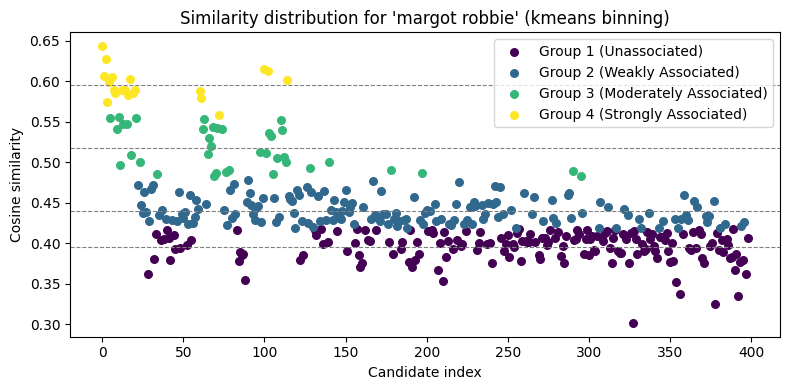


=== persian cat ===
Bin 1: Unassociated
  Bin center:  0.5255
  Group mean:  0.5262
  Test mean:   0.5186
  Train mean:  0.5286
  Group size:  42
  Test size:   10
  Train size:  32
Bin 2: Weakly Associated
  Bin center:  0.5836
  Group mean:  0.5838
  Test mean:   0.5855
  Train mean:  0.5837
  Group size:  205
  Test size:   10
  Train size:  195
Bin 3: Moderately Associated
  Bin center:  0.6507
  Group mean:  0.6507
  Test mean:   0.6519
  Train mean:  0.6506
  Group size:  93
  Test size:   10
  Train size:  83
Bin 4: Strongly Associated
  Bin center:  0.7648
  Group mean:  0.7648
  Test mean:   0.7736
  Train mean:  0.7630
  Group size:  60
  Test size:   10
  Train size:  50


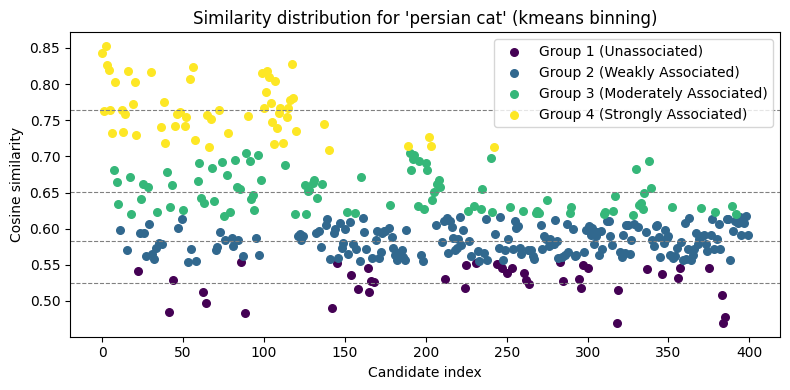


=== mickey mouse ===
Bin 1: Unassociated
  Bin center:  0.6169
  Group mean:  0.6169
  Test mean:   0.6228
  Train mean:  0.6163
  Group size:  112
  Test size:   10
  Train size:  102
Bin 2: Weakly Associated
  Bin center:  0.6686
  Group mean:  0.6680
  Test mean:   0.6619
  Train mean:  0.6684
  Group size:  162
  Test size:   10
  Train size:  152
Bin 3: Moderately Associated
  Bin center:  0.7172
  Group mean:  0.7162
  Test mean:   0.7165
  Train mean:  0.7162
  Group size:  101
  Test size:   10
  Train size:  91
Bin 4: Strongly Associated
  Bin center:  0.7858
  Group mean:  0.7858
  Test mean:   0.7861
  Train mean:  0.7856
  Group size:  25
  Test size:   10
  Train size:  15


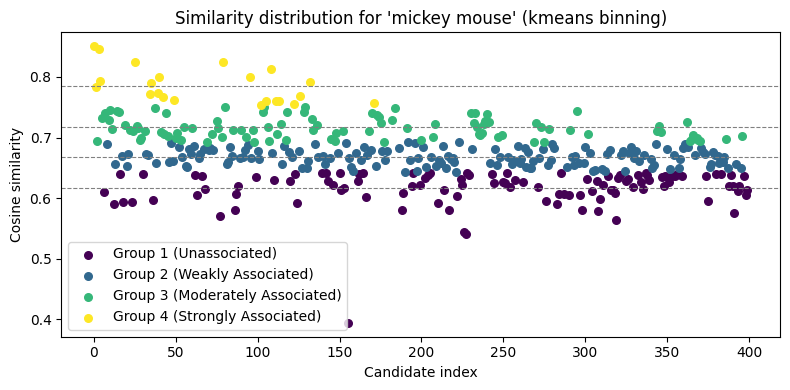


=== pad thai ===
Bin 1: Unassociated
  Bin center:  0.4905
  Group mean:  0.4911
  Test mean:   0.4975
  Train mean:  0.4902
  Group size:  83
  Test size:   10
  Train size:  73
Bin 2: Weakly Associated
  Bin center:  0.5423
  Group mean:  0.5427
  Test mean:   0.5472
  Train mean:  0.5424
  Group size:  162
  Test size:   10
  Train size:  152
Bin 3: Moderately Associated
  Bin center:  0.6128
  Group mean:  0.6128
  Test mean:   0.6105
  Train mean:  0.6131
  Group size:  96
  Test size:   10
  Train size:  86
Bin 4: Strongly Associated
  Bin center:  0.7044
  Group mean:  0.7044
  Test mean:   0.6984
  Train mean:  0.7056
  Group size:  59
  Test size:   10
  Train size:  49


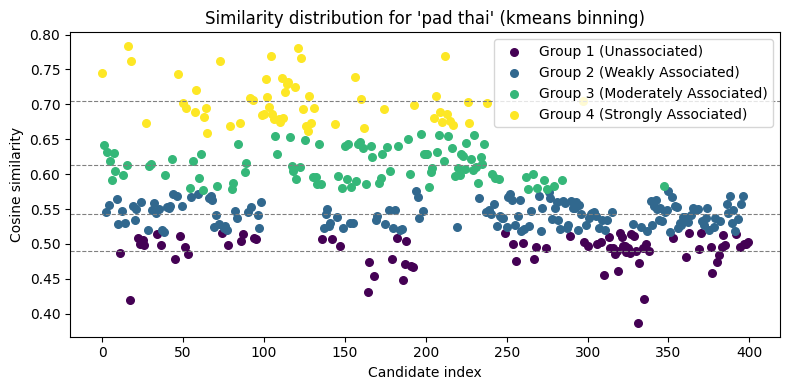


=== ganesha ===
Bin 1: Unassociated
  Bin center:  0.5766
  Group mean:  0.5769
  Test mean:   0.5734
  Train mean:  0.5773
  Group size:  96
  Test size:   10
  Train size:  86
Bin 2: Weakly Associated
  Bin center:  0.6243
  Group mean:  0.6244
  Test mean:   0.6212
  Train mean:  0.6246
  Group size:  171
  Test size:   10
  Train size:  161
Bin 3: Moderately Associated
  Bin center:  0.6709
  Group mean:  0.6709
  Test mean:   0.6733
  Train mean:  0.6706
  Group size:  106
  Test size:   10
  Train size:  96
Bin 4: Strongly Associated
  Bin center:  0.7399
  Group mean:  0.7399
  Test mean:   0.7438
  Train mean:  0.7376
  Group size:  27
  Test size:   10
  Train size:  17


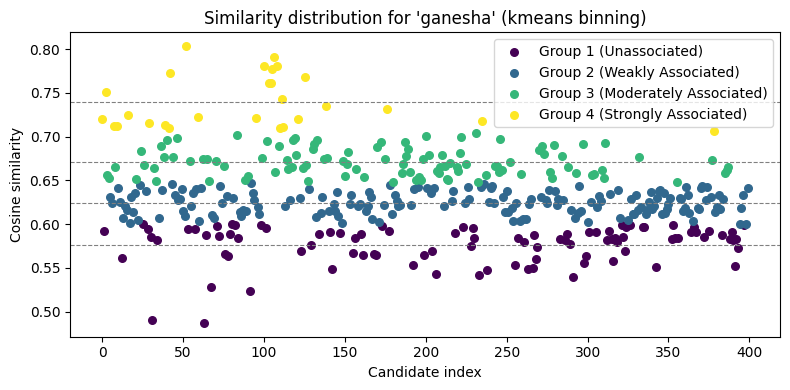


=== tank ===
Bin 1: Unassociated
  Bin center:  0.5438
  Group mean:  0.5438
  Test mean:   0.5534
  Train mean:  0.4959
  Group size:  12
  Test size:   10
  Train size:  2
Bin 2: Weakly Associated
  Bin center:  0.6259
  Group mean:  0.6262
  Test mean:   0.6311
  Train mean:  0.6256
  Group size:  87
  Test size:   10
  Train size:  77
Bin 3: Moderately Associated
  Bin center:  0.6766
  Group mean:  0.6768
  Test mean:   0.6733
  Train mean:  0.6770
  Group size:  189
  Test size:   10
  Train size:  179
Bin 4: Strongly Associated
  Bin center:  0.7229
  Group mean:  0.7229
  Test mean:   0.7201
  Train mean:  0.7231
  Group size:  112
  Test size:   10
  Train size:  102


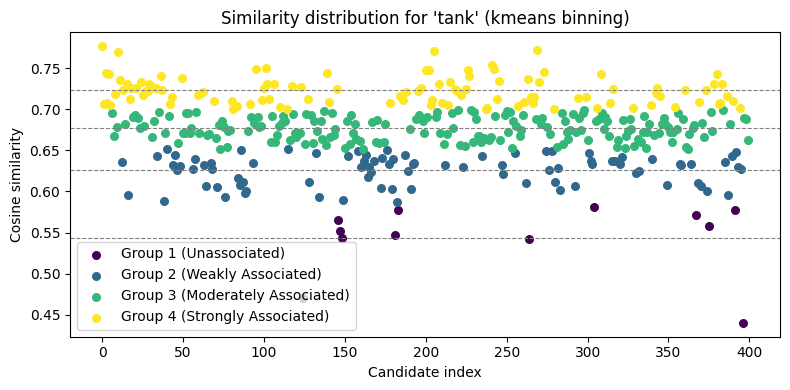


=== donald trump ===
Bin 1: Unassociated
  Bin center:  0.5947
  Group mean:  0.5947
  Test mean:   0.6004
  Train mean:  0.5940
  Group size:  96
  Test size:   10
  Train size:  86
Bin 2: Weakly Associated
  Bin center:  0.6474
  Group mean:  0.6471
  Test mean:   0.6436
  Train mean:  0.6473
  Group size:  188
  Test size:   10
  Train size:  178
Bin 3: Moderately Associated
  Bin center:  0.7059
  Group mean:  0.7053
  Test mean:   0.7178
  Train mean:  0.7038
  Group size:  91
  Test size:   10
  Train size:  81
Bin 4: Strongly Associated
  Bin center:  0.7967
  Group mean:  0.7967
  Test mean:   0.8081
  Train mean:  0.7891
  Group size:  25
  Test size:   10
  Train size:  15


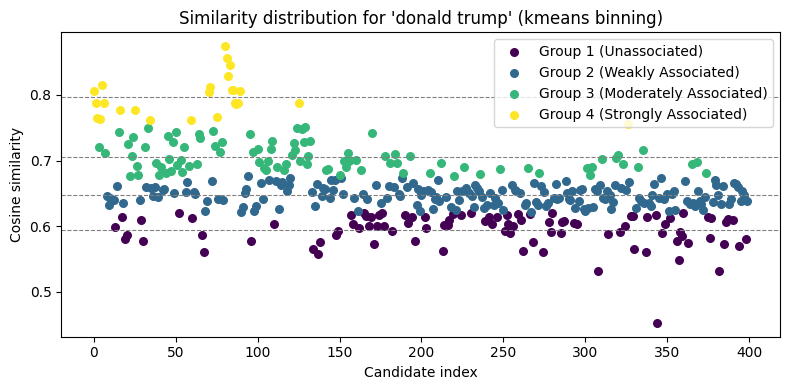


=== barack obama ===
Bin 1: Unassociated
  Bin center:  0.5950
  Group mean:  0.5950
  Test mean:   0.5999
  Train mean:  0.5945
  Group size:  112
  Test size:   10
  Train size:  102
Bin 2: Weakly Associated
  Bin center:  0.6428
  Group mean:  0.6430
  Test mean:   0.6329
  Train mean:  0.6435
  Group size:  193
  Test size:   10
  Train size:  183
Bin 3: Moderately Associated
  Bin center:  0.6905
  Group mean:  0.6908
  Test mean:   0.6936
  Train mean:  0.6905
  Group size:  82
  Test size:   10
  Train size:  72
Bin 4: Strongly Associated
  Bin center:  0.7897
  Group mean:  0.7897
  Test mean:   0.8003
  Train mean:  0.7543
  Group size:  13
  Test size:   10
  Train size:  3


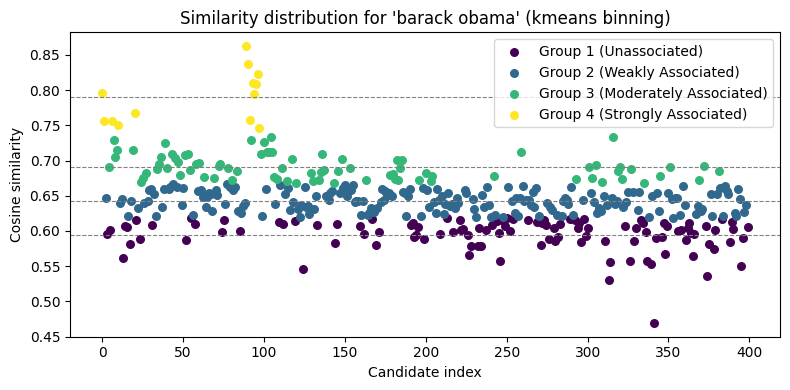


=== a painting in the style of van gogh ===
Bin 1: Unassociated
  Bin center:  0.5505
  Group mean:  0.5498
  Test mean:   0.5492
  Train mean:  0.5499
  Group size:  77
  Test size:   10
  Train size:  67
Bin 2: Weakly Associated
  Bin center:  0.6049
  Group mean:  0.6046
  Test mean:   0.6047
  Train mean:  0.6046
  Group size:  165
  Test size:   10
  Train size:  155
Bin 3: Moderately Associated
  Bin center:  0.6918
  Group mean:  0.6918
  Test mean:   0.6951
  Train mean:  0.6910
  Group size:  50
  Test size:   10
  Train size:  40
Bin 4: Strongly Associated
  Bin center:  0.7953
  Group mean:  0.7953
  Test mean:   0.7954
  Train mean:  0.7953
  Group size:  108
  Test size:   10
  Train size:  98


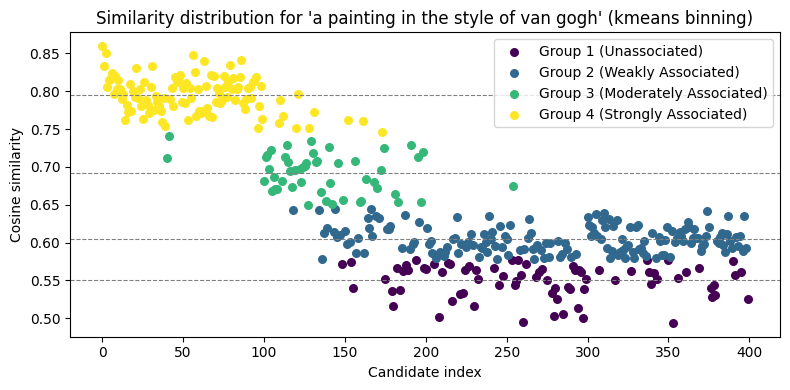


=== a painting in the style of claude monet ===
Bin 1: Unassociated
  Bin center:  0.5021
  Group mean:  0.5021
  Test mean:   0.4971
  Train mean:  0.5023
  Group size:  188
  Test size:   10
  Train size:  178
Bin 2: Weakly Associated
  Bin center:  0.5646
  Group mean:  0.5646
  Test mean:   0.5649
  Train mean:  0.5646
  Group size:  101
  Test size:   10
  Train size:  91
Bin 3: Moderately Associated
  Bin center:  0.6929
  Group mean:  0.6929
  Test mean:   0.6879
  Train mean:  0.6945
  Group size:  41
  Test size:   10
  Train size:  31
Bin 4: Strongly Associated
  Bin center:  0.7960
  Group mean:  0.7960
  Test mean:   0.7938
  Train mean:  0.7964
  Group size:  70
  Test size:   10
  Train size:  60


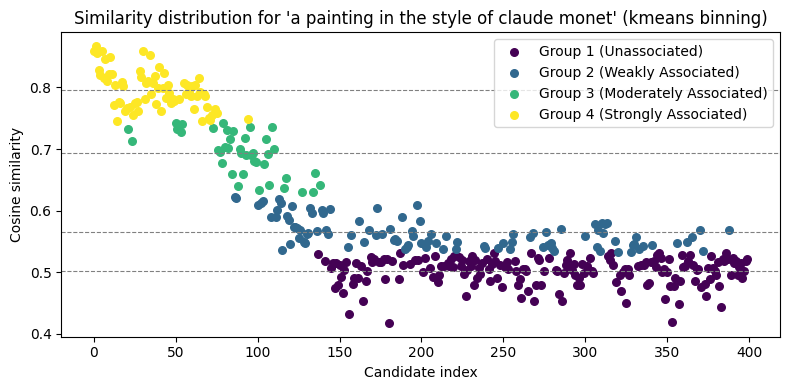

{'margot robbie': {'Strongly Associated': ['Jennifer Lawrence',
   'Reese Witherspoon',
   'Jessica Chastain',
   'Gal Gadot',
   'Brad Pitt',
   'Kristen Stewart',
   'Anne Hathaway',
   'Leonardo DiCaprio',
   'Meryl Streep',
   'Nicole Kidman'],
  'Moderately Associated': ['Emily Blunt',
   'Megan Fox',
   'Will Smith',
   'Cate Blanchett',
   'model portfolio',
   'Zoe Saldana',
   'Jared Leto',
   'Ryan Gosling',
   'Martin Scorsese',
   'Penelope Cruz'],
  'Weakly Associated': ['handbag',
   'heels',
   'film festival banner',
   'radio host',
   'luxury handbag',
   'smiling star',
   'fashion magazine',
   'smiling actress',
   'highway',
   'Las Vegas casino'],
  'Unassociated': ['smartphone screen',
   'satellite dish',
   'toolbox',
   'shipping container',
   'forest waterfall',
   'smiling portrait',
   'stylist fitting room',
   'classroom desk',
   'barn house',
   'school chalkboard']},
 'persian cat': {'Strongly Associated': ['Bengal cat',
   'Maine Coon cat',
   'pure

In [68]:

concepts = ['margot robbie', 'persian cat', 'mickey mouse','pad thai','ganesha', 'tank'] + ['donald trump', 'barack obama'] + ["a painting in the style of van gogh","a painting in the style of claude monet"]

sample_per_bin = 10; sampling_seed = 123
concept_to_levels_TEST, concept_to_levels_TRAIN, concept_to_data = build_concept_to_associate_levels_to_preservation_concepts(concepts, sample_per_bin=sample_per_bin, verbose=True, sampling_seed=sampling_seed)
concept_to_levels_TEST


In [69]:

save_dir = "data_root/data/preservation_concepts/"
os.makedirs(save_dir, exist_ok=True)
# save_path = osp.join(save_dir, f"all_pe_v1_r{sampling_seed}.pth")
save_path = osp.join(save_dir, f"all_pe_v3_r{sampling_seed}.pth")
torch.save(concept_to_data,  save_path)

In [70]:

# save_dir = "data_root/data/preservation_concepts/"
# os.makedirs(save_dir, exist_ok=True)
# # save_path = osp.join(save_dir, f"all_pe_v1_r{sampling_seed}.pth")
# save_path = osp.join(save_dir, f"all_pe_v2_r{sampling_seed}.pth")
# torch.save(concept_to_data,  save_path)

In [71]:
t1 = torch.load(osp.join(save_dir, f"all_pe_v2_r{sampling_seed}.pth"))
t2 = torch.load(osp.join(save_dir, f"all_pe_v3_r{sampling_seed}.pth"))


/tmp/ipykernel_2764104/3810052661.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  t1 = torch.load(osp.join(save_dir, f"all_pe_v2_r{sampling_seed}.pth"))
/tmp/ipykernel_2

In [72]:
# be sure that the old concepts from v1 are unchanged in v2
from copy import deepcopy
for concepts in ['margot robbie', 'persian cat', 'mickey mouse','pad thai','ganesha', 'tank']:
    
    t1_ = deepcopy(t1)
    t1_[concepts]['train'][-1] = 'xxx'
    assert t1[concepts] == t2[concepts]
    assert t2[concepts] != t1_[concepts]


=== margot robbie ===
Bin 1: Unassociated
  Bin center:  0.3959
  Group mean:  0.3957
  Test mean:   0.3974
  Train mean:  0.3955
  Group size:  177
  Test size:   10
  Train size:  167
Bin 2: Weakly Associated
  Bin center:  0.4404
  Group mean:  0.4401
  Test mean:   0.4391
  Train mean:  0.4402
  Group size:  163
  Test size:   10
  Train size:  153
Bin 3: Moderately Associated
  Bin center:  0.5169
  Group mean:  0.5169
  Test mean:   0.5283
  Train mean:  0.5129
  Group size:  38
  Test size:   10
  Train size:  28
Bin 4: Strongly Associated
  Bin center:  0.5952
  Group mean:  0.5952
  Test mean:   0.5932
  Train mean:  0.5971
  Group size:  21
  Test size:   10
  Train size:  11


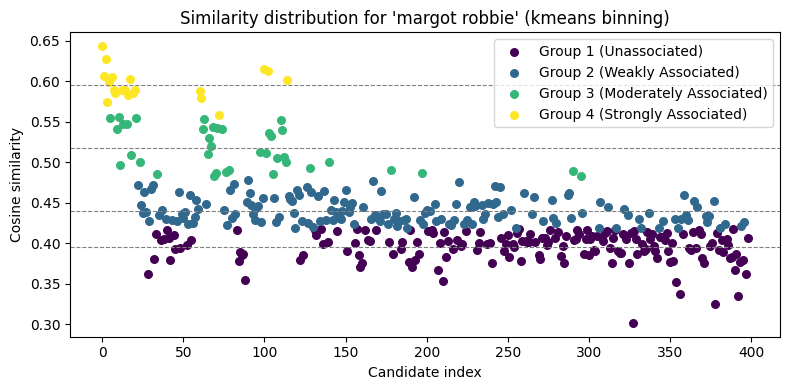


=== persian cat ===
Bin 1: Unassociated
  Bin center:  0.5255
  Group mean:  0.5262
  Test mean:   0.5186
  Train mean:  0.5286
  Group size:  42
  Test size:   10
  Train size:  32
Bin 2: Weakly Associated
  Bin center:  0.5836
  Group mean:  0.5838
  Test mean:   0.5855
  Train mean:  0.5837
  Group size:  205
  Test size:   10
  Train size:  195
Bin 3: Moderately Associated
  Bin center:  0.6507
  Group mean:  0.6507
  Test mean:   0.6519
  Train mean:  0.6506
  Group size:  93
  Test size:   10
  Train size:  83
Bin 4: Strongly Associated
  Bin center:  0.7648
  Group mean:  0.7648
  Test mean:   0.7736
  Train mean:  0.7630
  Group size:  60
  Test size:   10
  Train size:  50


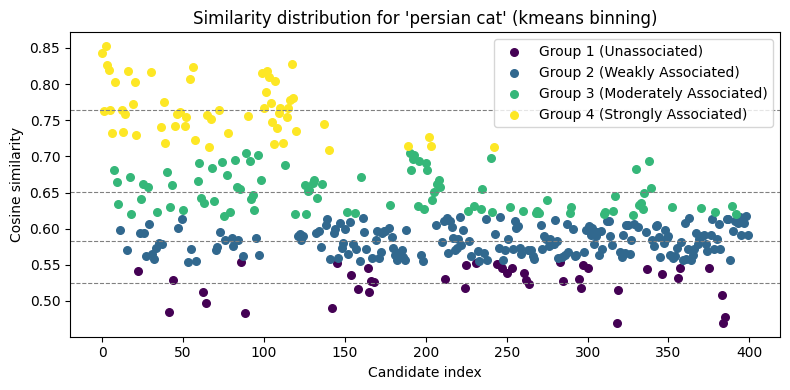


=== mickey mouse ===
Bin 1: Unassociated
  Bin center:  0.6169
  Group mean:  0.6169
  Test mean:   0.6228
  Train mean:  0.6163
  Group size:  112
  Test size:   10
  Train size:  102
Bin 2: Weakly Associated
  Bin center:  0.6686
  Group mean:  0.6680
  Test mean:   0.6619
  Train mean:  0.6684
  Group size:  162
  Test size:   10
  Train size:  152
Bin 3: Moderately Associated
  Bin center:  0.7172
  Group mean:  0.7162
  Test mean:   0.7165
  Train mean:  0.7162
  Group size:  101
  Test size:   10
  Train size:  91
Bin 4: Strongly Associated
  Bin center:  0.7858
  Group mean:  0.7858
  Test mean:   0.7861
  Train mean:  0.7856
  Group size:  25
  Test size:   10
  Train size:  15


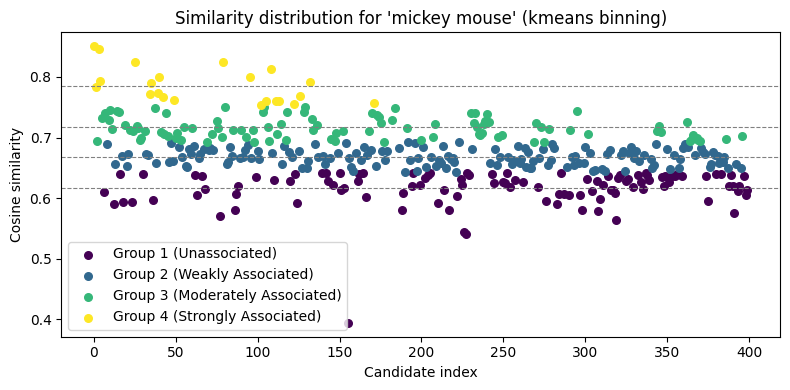


=== pad thai ===
Bin 1: Unassociated
  Bin center:  0.4905
  Group mean:  0.4911
  Test mean:   0.4975
  Train mean:  0.4902
  Group size:  83
  Test size:   10
  Train size:  73
Bin 2: Weakly Associated
  Bin center:  0.5423
  Group mean:  0.5427
  Test mean:   0.5472
  Train mean:  0.5424
  Group size:  162
  Test size:   10
  Train size:  152
Bin 3: Moderately Associated
  Bin center:  0.6128
  Group mean:  0.6128
  Test mean:   0.6105
  Train mean:  0.6131
  Group size:  96
  Test size:   10
  Train size:  86
Bin 4: Strongly Associated
  Bin center:  0.7044
  Group mean:  0.7044
  Test mean:   0.6984
  Train mean:  0.7056
  Group size:  59
  Test size:   10
  Train size:  49


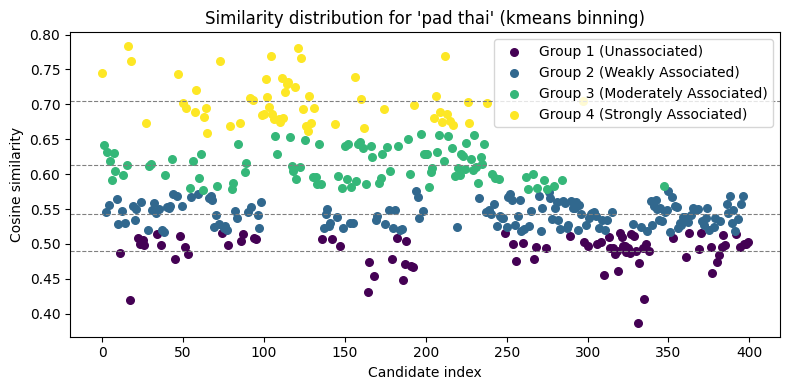


=== ganesha ===
Bin 1: Unassociated
  Bin center:  0.5766
  Group mean:  0.5769
  Test mean:   0.5734
  Train mean:  0.5773
  Group size:  96
  Test size:   10
  Train size:  86
Bin 2: Weakly Associated
  Bin center:  0.6243
  Group mean:  0.6244
  Test mean:   0.6212
  Train mean:  0.6246
  Group size:  171
  Test size:   10
  Train size:  161
Bin 3: Moderately Associated
  Bin center:  0.6709
  Group mean:  0.6709
  Test mean:   0.6733
  Train mean:  0.6706
  Group size:  106
  Test size:   10
  Train size:  96
Bin 4: Strongly Associated
  Bin center:  0.7399
  Group mean:  0.7399
  Test mean:   0.7438
  Train mean:  0.7376
  Group size:  27
  Test size:   10
  Train size:  17


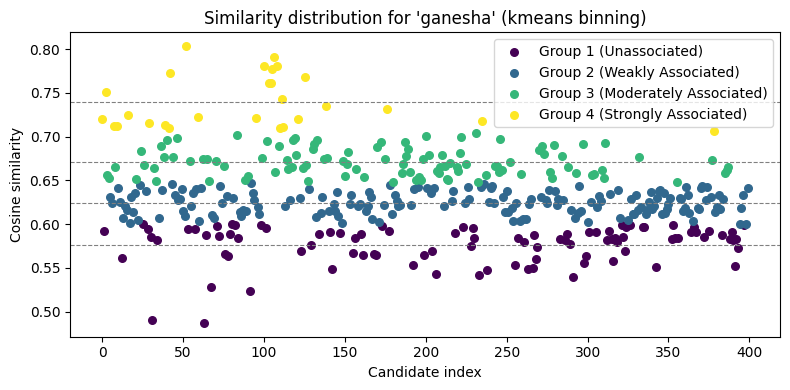


=== tank ===
Bin 1: Unassociated
  Bin center:  0.5438
  Group mean:  0.5438
  Test mean:   0.5534
  Train mean:  0.4959
  Group size:  12
  Test size:   10
  Train size:  2
Bin 2: Weakly Associated
  Bin center:  0.6259
  Group mean:  0.6262
  Test mean:   0.6311
  Train mean:  0.6256
  Group size:  87
  Test size:   10
  Train size:  77
Bin 3: Moderately Associated
  Bin center:  0.6766
  Group mean:  0.6768
  Test mean:   0.6733
  Train mean:  0.6770
  Group size:  189
  Test size:   10
  Train size:  179
Bin 4: Strongly Associated
  Bin center:  0.7229
  Group mean:  0.7229
  Test mean:   0.7201
  Train mean:  0.7231
  Group size:  112
  Test size:   10
  Train size:  102


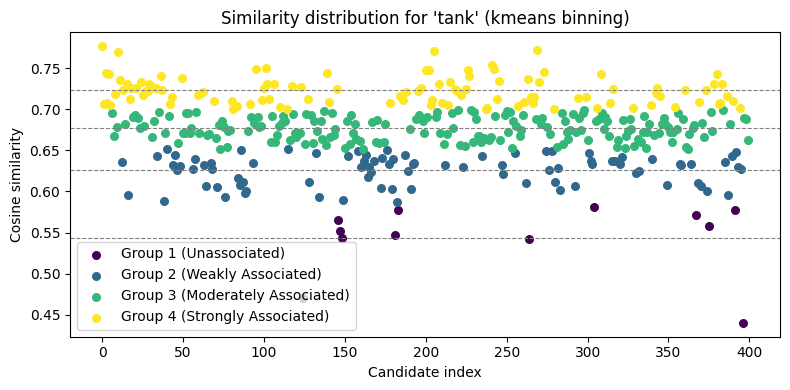

{'margot robbie': {'Strongly Associated': ['Jennifer Lawrence',
   'Reese Witherspoon',
   'Jessica Chastain',
   'Gal Gadot',
   'Brad Pitt',
   'Kristen Stewart',
   'Anne Hathaway',
   'Leonardo DiCaprio',
   'Meryl Streep',
   'Nicole Kidman'],
  'Moderately Associated': ['Emily Blunt',
   'Megan Fox',
   'Will Smith',
   'Cate Blanchett',
   'model portfolio',
   'Zoe Saldana',
   'Jared Leto',
   'Ryan Gosling',
   'Martin Scorsese',
   'Penelope Cruz'],
  'Weakly Associated': ['handbag',
   'heels',
   'film festival banner',
   'radio host',
   'luxury handbag',
   'smiling star',
   'fashion magazine',
   'smiling actress',
   'highway',
   'Las Vegas casino'],
  'Unassociated': ['smartphone screen',
   'satellite dish',
   'toolbox',
   'shipping container',
   'forest waterfall',
   'smiling portrait',
   'stylist fitting room',
   'classroom desk',
   'barn house',
   'school chalkboard']},
 'persian cat': {'Strongly Associated': ['Bengal cat',
   'Maine Coon cat',
   'pure

In [ ]:

concepts = ['margot robbie', 'persian cat', 'mickey mouse','pad thai','ganesha', 'tank']

sample_per_bin = 10; sampling_seed = 123
concept_to_levels_TEST, concept_to_levels_TRAIN, concept_to_data = build_concept_to_associate_levels_to_preservation_concepts(concepts, sample_per_bin=sample_per_bin, verbose=True, sampling_seed=sampling_seed)
concept_to_levels_TEST


In [ ]:

save_dir = "data_root/data/preservation_concepts/"
os.makedirs(save_dir, exist_ok=True)
# save_path = osp.join(save_dir, f"all_pe_v1_r{sampling_seed}.pth")
save_path = osp.join(save_dir, f"all_pe_v2_r{sampling_seed}.pth")
torch.save(concept_to_data,  save_path)

NameError: name 'torch' is not defined

In [28]:
pwd

'/home/nessessence/mnt_tl_vision16/home/nessessence'

In [31]:
concept_to_data["margot robbie"]

{'train': {'Strongly Associated': ['Emma Stone',
   'Scarlett Johansson',
   'Anne Hathaway',
   'Natalie Portman',
   'Charlize Theron',
   'Amber Heard',
   'Blake Lively',
   'Harley Quinn',
   'Johnny Depp',
   'Angelina Jolie',
   'Emma Watson'],
  'Moderately Associated': ['Keira Knightley',
   'Kate Winslet',
   'Rachel McAdams',
   'Amy Adams',
   'Naomi Watts',
   'Suicide Squad',
   'DC Comics',
   'movie premiere',
   'Quentin Tarantino',
   'Greta Gerwig',
   'Tom Hardy',
   'Christian Bale',
   'Hugh Jackman',
   'Viola Davis',
   'Golden Globes',
   'movie trailer',
   'celebrity photo',
   'Sandra Bullock',
   'Julia Roberts',
   'Cameron Diaz',
   'Drew Barrymore',
   'Michelle Pfeiffer',
   'Helena Bonham Carter',
   'Vogue cover',
   'TV series cast',
   'celebrity interview',
   'celebrity magazine cover',
   'celebrity PR manager'],
  'Weakly Associated': ['Birds of Prey',
   'comic book panel',
   'comic convention',
   'superhero costume',
   'joker playing card',


=== margot robbie ===
Bin 1: Unassociated
  Bin center:  0.3959
  Group mean:  0.3957
  Sample mean: 0.3974
  Total in group: 177
  Sampled count: 10
Bin 2: Weakly Associated
  Bin center:  0.4404
  Group mean:  0.4401
  Sample mean: 0.4391
  Total in group: 163
  Sampled count: 10
Bin 3: Moderately Associated
  Bin center:  0.5169
  Group mean:  0.5169
  Sample mean: 0.5283
  Total in group: 38
  Sampled count: 10
Bin 4: Strongly Associated
  Bin center:  0.5952
  Group mean:  0.5952
  Sample mean: 0.5932
  Total in group: 21
  Sampled count: 10


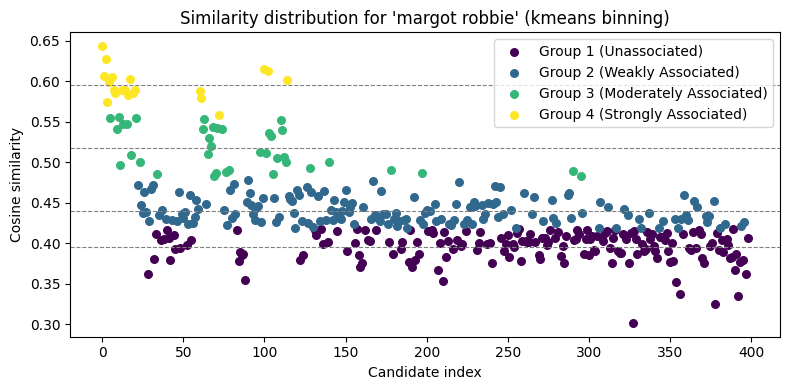


=== persian cat ===
Bin 1: Unassociated
  Bin center:  0.5255
  Group mean:  0.5262
  Sample mean: 0.5186
  Total in group: 42
  Sampled count: 10
Bin 2: Weakly Associated
  Bin center:  0.5836
  Group mean:  0.5838
  Sample mean: 0.5855
  Total in group: 205
  Sampled count: 10
Bin 3: Moderately Associated
  Bin center:  0.6507
  Group mean:  0.6507
  Sample mean: 0.6519
  Total in group: 93
  Sampled count: 10
Bin 4: Strongly Associated
  Bin center:  0.7648
  Group mean:  0.7648
  Sample mean: 0.7736
  Total in group: 60
  Sampled count: 10


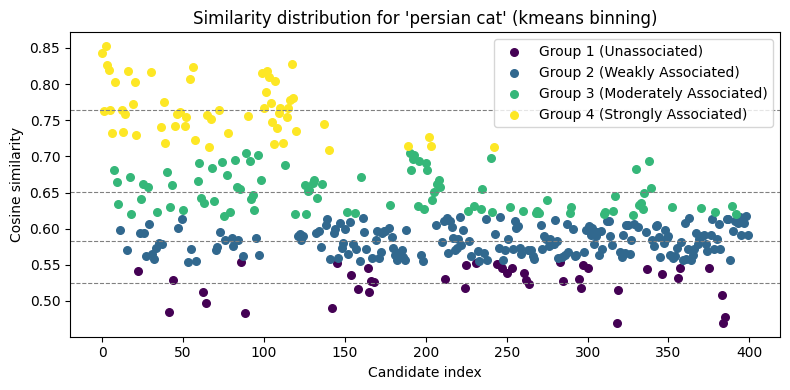


=== mickey mouse ===
Bin 1: Unassociated
  Bin center:  0.6169
  Group mean:  0.6169
  Sample mean: 0.6228
  Total in group: 112
  Sampled count: 10
Bin 2: Weakly Associated
  Bin center:  0.6686
  Group mean:  0.6680
  Sample mean: 0.6619
  Total in group: 162
  Sampled count: 10
Bin 3: Moderately Associated
  Bin center:  0.7172
  Group mean:  0.7162
  Sample mean: 0.7165
  Total in group: 101
  Sampled count: 10
Bin 4: Strongly Associated
  Bin center:  0.7858
  Group mean:  0.7858
  Sample mean: 0.7861
  Total in group: 25
  Sampled count: 10


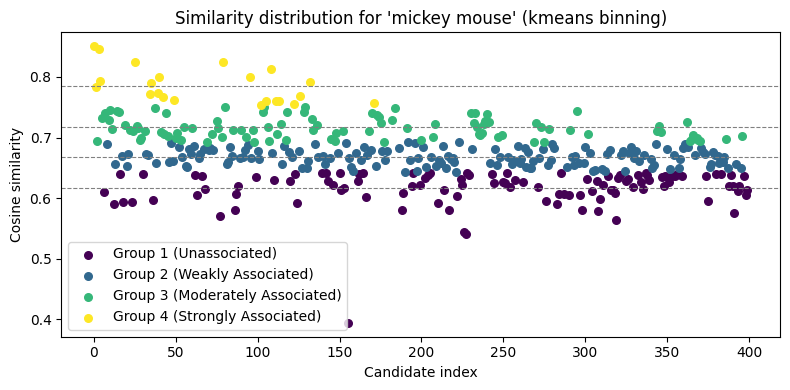


=== pad thai ===
Bin 1: Unassociated
  Bin center:  0.4905
  Group mean:  0.4911
  Sample mean: 0.4975
  Total in group: 83
  Sampled count: 10
Bin 2: Weakly Associated
  Bin center:  0.5423
  Group mean:  0.5427
  Sample mean: 0.5472
  Total in group: 162
  Sampled count: 10
Bin 3: Moderately Associated
  Bin center:  0.6128
  Group mean:  0.6128
  Sample mean: 0.6105
  Total in group: 96
  Sampled count: 10
Bin 4: Strongly Associated
  Bin center:  0.7044
  Group mean:  0.7044
  Sample mean: 0.6984
  Total in group: 59
  Sampled count: 10


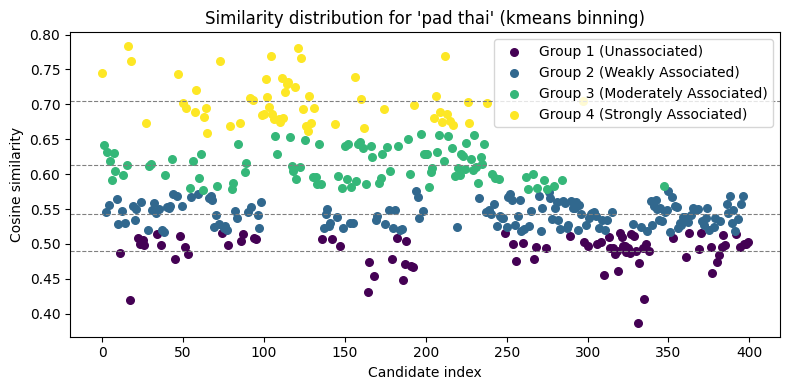


=== ganesha ===
Bin 1: Unassociated
  Bin center:  0.5766
  Group mean:  0.5769
  Sample mean: 0.5734
  Total in group: 96
  Sampled count: 10
Bin 2: Weakly Associated
  Bin center:  0.6243
  Group mean:  0.6244
  Sample mean: 0.6212
  Total in group: 171
  Sampled count: 10
Bin 3: Moderately Associated
  Bin center:  0.6709
  Group mean:  0.6709
  Sample mean: 0.6733
  Total in group: 106
  Sampled count: 10
Bin 4: Strongly Associated
  Bin center:  0.7399
  Group mean:  0.7399
  Sample mean: 0.7438
  Total in group: 27
  Sampled count: 10


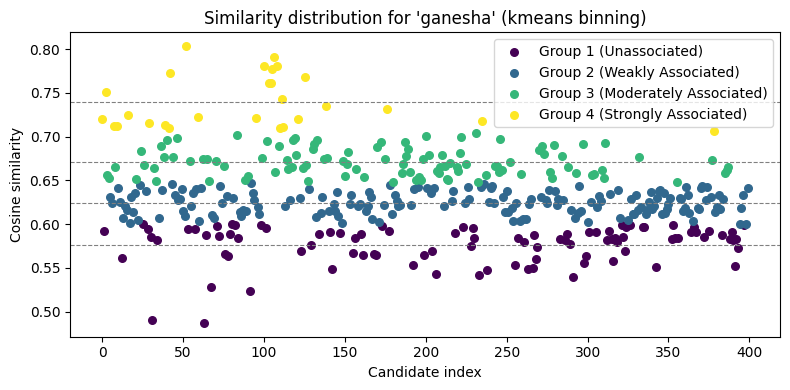


=== tank ===
Bin 1: Unassociated
  Bin center:  0.5438
  Group mean:  0.5438
  Sample mean: 0.5534
  Total in group: 12
  Sampled count: 10
Bin 2: Weakly Associated
  Bin center:  0.6259
  Group mean:  0.6262
  Sample mean: 0.6311
  Total in group: 87
  Sampled count: 10
Bin 3: Moderately Associated
  Bin center:  0.6766
  Group mean:  0.6768
  Sample mean: 0.6733
  Total in group: 189
  Sampled count: 10
Bin 4: Strongly Associated
  Bin center:  0.7229
  Group mean:  0.7229
  Sample mean: 0.7201
  Total in group: 112
  Sampled count: 10


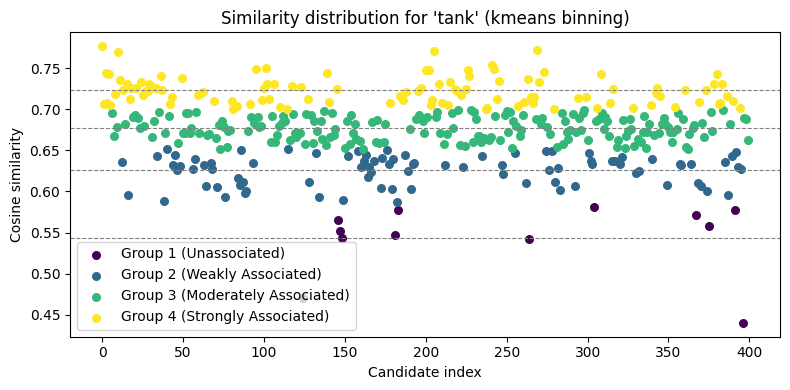

{'margot robbie': {'Strongly Associated': ['Jennifer Lawrence',
   'Reese Witherspoon',
   'Jessica Chastain',
   'Gal Gadot',
   'Brad Pitt',
   'Kristen Stewart',
   'Anne Hathaway',
   'Leonardo DiCaprio',
   'Meryl Streep',
   'Nicole Kidman'],
  'Moderately Associated': ['Emily Blunt',
   'Megan Fox',
   'Will Smith',
   'Cate Blanchett',
   'model portfolio',
   'Zoe Saldana',
   'Jared Leto',
   'Ryan Gosling',
   'Martin Scorsese',
   'Penelope Cruz'],
  'Weakly Associated': ['handbag',
   'heels',
   'film festival banner',
   'radio host',
   'luxury handbag',
   'smiling star',
   'fashion magazine',
   'smiling actress',
   'highway',
   'Las Vegas casino'],
  'Unassociated': ['smartphone screen',
   'satellite dish',
   'toolbox',
   'shipping container',
   'forest waterfall',
   'smiling portrait',
   'stylist fitting room',
   'classroom desk',
   'barn house',
   'school chalkboard']},
 'persian cat': {'Strongly Associated': ['Bengal cat',
   'Maine Coon cat',
   'pure

In [22]:
concepts = ['margot robbie', 'persian cat', 'mickey mouse','pad thai','ganesha', 'tank']

sample_per_bin = 10
concept_to_associate_levels_to_preservation_concept = build_concept_to_associate_levels_to_preservation_concepts(concepts, sample_per_bin=sample_per_bin, verbose=True)
concept_to_associate_levels_to_preservation_concept

In [24]:
concept_to_associate_levels_to_preservation_concept["margot robbie"]

{'Strongly Associated': ['Jennifer Lawrence',
  'Reese Witherspoon',
  'Jessica Chastain',
  'Gal Gadot',
  'Brad Pitt',
  'Kristen Stewart',
  'Anne Hathaway',
  'Leonardo DiCaprio',
  'Meryl Streep',
  'Nicole Kidman'],
 'Moderately Associated': ['Emily Blunt',
  'Megan Fox',
  'Will Smith',
  'Cate Blanchett',
  'model portfolio',
  'Zoe Saldana',
  'Jared Leto',
  'Ryan Gosling',
  'Martin Scorsese',
  'Penelope Cruz'],
 'Weakly Associated': ['handbag',
  'heels',
  'film festival banner',
  'radio host',
  'luxury handbag',
  'smiling star',
  'fashion magazine',
  'smiling actress',
  'highway',
  'Las Vegas casino'],
 'Unassociated': ['smartphone screen',
  'satellite dish',
  'toolbox',
  'shipping container',
  'forest waterfall',
  'smiling portrait',
  'stylist fitting room',
  'classroom desk',
  'barn house',
  'school chalkboard']}


=== margot robbie ===
Bin 1: Unassociated
  Bin center:  0.3959
  Group mean:  0.3957
  Sample mean: 0.3974
  Total in group: 177
  Sampled count: 10
Bin 2: Weakly Associated
  Bin center:  0.4404
  Group mean:  0.4401
  Sample mean: 0.4391
  Total in group: 163
  Sampled count: 10
Bin 3: Moderately Associated
  Bin center:  0.5169
  Group mean:  0.5169
  Sample mean: 0.5283
  Total in group: 38
  Sampled count: 10
Bin 4: Strongly Associated
  Bin center:  0.5952
  Group mean:  0.5952
  Sample mean: 0.5932
  Total in group: 21
  Sampled count: 10


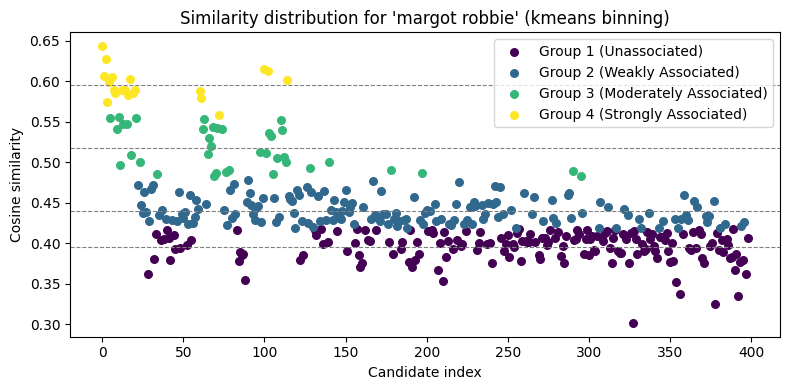


=== persian cat ===
Bin 1: Unassociated
  Bin center:  0.5255
  Group mean:  0.5262
  Sample mean: 0.5186
  Total in group: 42
  Sampled count: 10
Bin 2: Weakly Associated
  Bin center:  0.5836
  Group mean:  0.5838
  Sample mean: 0.5855
  Total in group: 205
  Sampled count: 10
Bin 3: Moderately Associated
  Bin center:  0.6507
  Group mean:  0.6507
  Sample mean: 0.6519
  Total in group: 93
  Sampled count: 10
Bin 4: Strongly Associated
  Bin center:  0.7648
  Group mean:  0.7648
  Sample mean: 0.7736
  Total in group: 60
  Sampled count: 10


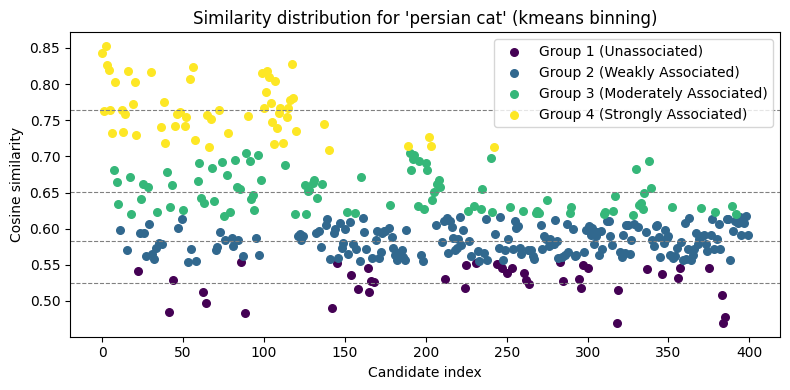


=== mickey mouse ===
Bin 1: Unassociated
  Bin center:  0.6169
  Group mean:  0.6169
  Sample mean: 0.6228
  Total in group: 112
  Sampled count: 10
Bin 2: Weakly Associated
  Bin center:  0.6686
  Group mean:  0.6680
  Sample mean: 0.6619
  Total in group: 162
  Sampled count: 10
Bin 3: Moderately Associated
  Bin center:  0.7172
  Group mean:  0.7162
  Sample mean: 0.7165
  Total in group: 101
  Sampled count: 10
Bin 4: Strongly Associated
  Bin center:  0.7858
  Group mean:  0.7858
  Sample mean: 0.7861
  Total in group: 25
  Sampled count: 10


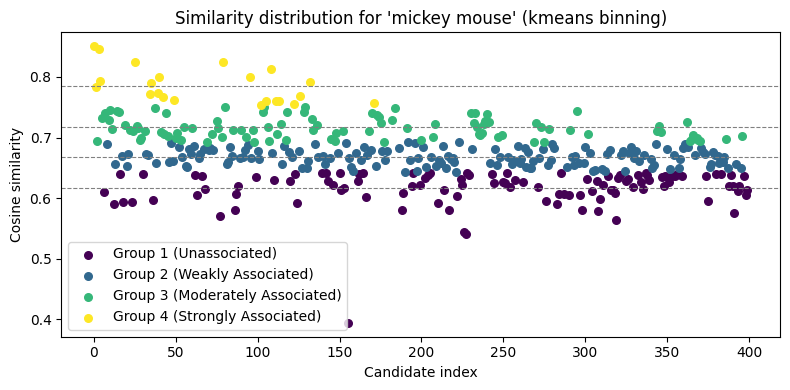


=== pad thai ===
Bin 1: Unassociated
  Bin center:  0.4905
  Group mean:  0.4911
  Sample mean: 0.4975
  Total in group: 83
  Sampled count: 10
Bin 2: Weakly Associated
  Bin center:  0.5423
  Group mean:  0.5427
  Sample mean: 0.5472
  Total in group: 162
  Sampled count: 10
Bin 3: Moderately Associated
  Bin center:  0.6128
  Group mean:  0.6128
  Sample mean: 0.6105
  Total in group: 96
  Sampled count: 10
Bin 4: Strongly Associated
  Bin center:  0.7044
  Group mean:  0.7044
  Sample mean: 0.6984
  Total in group: 59
  Sampled count: 10


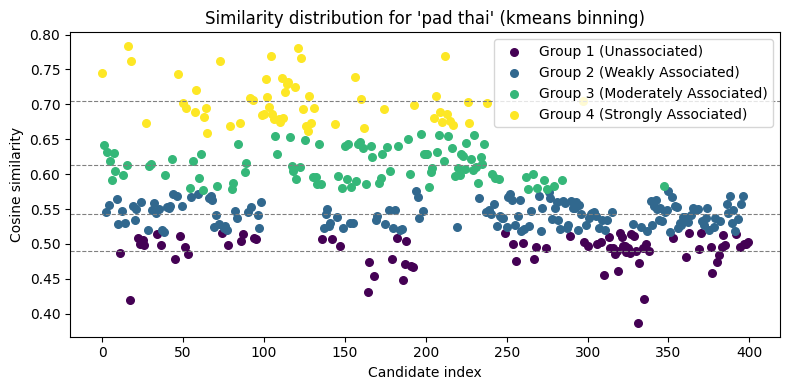


=== ganesha ===
Bin 1: Unassociated
  Bin center:  0.5766
  Group mean:  0.5769
  Sample mean: 0.5734
  Total in group: 96
  Sampled count: 10
Bin 2: Weakly Associated
  Bin center:  0.6243
  Group mean:  0.6244
  Sample mean: 0.6212
  Total in group: 171
  Sampled count: 10
Bin 3: Moderately Associated
  Bin center:  0.6709
  Group mean:  0.6709
  Sample mean: 0.6733
  Total in group: 106
  Sampled count: 10
Bin 4: Strongly Associated
  Bin center:  0.7399
  Group mean:  0.7399
  Sample mean: 0.7438
  Total in group: 27
  Sampled count: 10


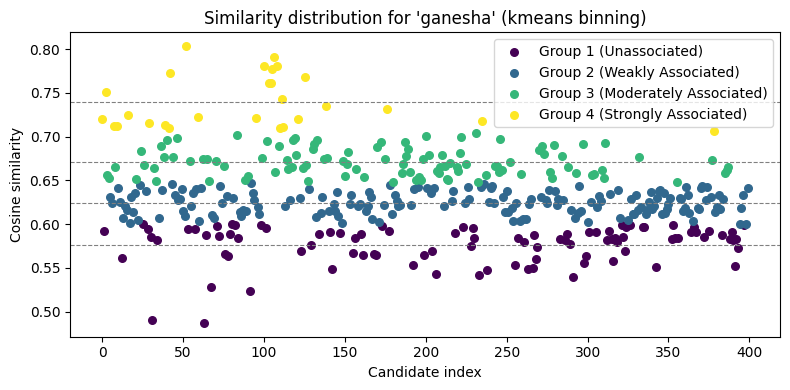


=== tank ===
Bin 1: Unassociated
  Bin center:  0.5438
  Group mean:  0.5438
  Sample mean: 0.5534
  Total in group: 12
  Sampled count: 10
Bin 2: Weakly Associated
  Bin center:  0.6259
  Group mean:  0.6262
  Sample mean: 0.6311
  Total in group: 87
  Sampled count: 10
Bin 3: Moderately Associated
  Bin center:  0.6766
  Group mean:  0.6768
  Sample mean: 0.6733
  Total in group: 189
  Sampled count: 10
Bin 4: Strongly Associated
  Bin center:  0.7229
  Group mean:  0.7229
  Sample mean: 0.7201
  Total in group: 112
  Sampled count: 10


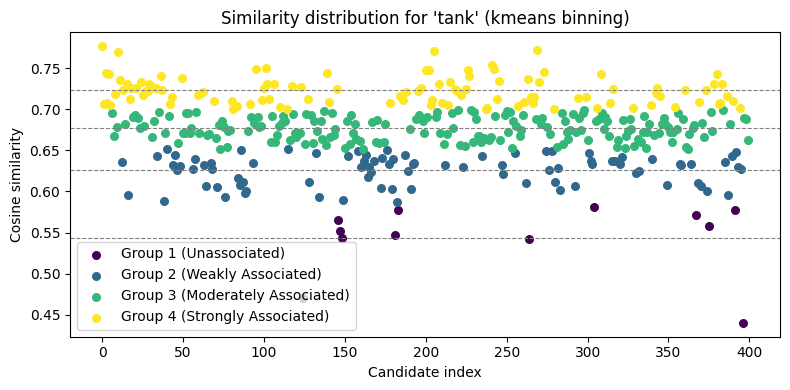

{'margot robbie': {'Strongly Associated': ['Jennifer Lawrence',
   'Reese Witherspoon',
   'Jessica Chastain',
   'Gal Gadot',
   'Brad Pitt',
   'Kristen Stewart',
   'Anne Hathaway',
   'Leonardo DiCaprio',
   'Meryl Streep',
   'Nicole Kidman'],
  'Moderately Associated': ['Emily Blunt',
   'Megan Fox',
   'Will Smith',
   'Cate Blanchett',
   'model portfolio',
   'Zoe Saldana',
   'Jared Leto',
   'Ryan Gosling',
   'Martin Scorsese',
   'Penelope Cruz'],
  'Weakly Associated': ['handbag',
   'heels',
   'film festival banner',
   'radio host',
   'luxury handbag',
   'smiling star',
   'fashion magazine',
   'smiling actress',
   'highway',
   'Las Vegas casino'],
  'Unassociated': ['smartphone screen',
   'satellite dish',
   'toolbox',
   'shipping container',
   'forest waterfall',
   'smiling portrait',
   'stylist fitting room',
   'classroom desk',
   'barn house',
   'school chalkboard']},
 'persian cat': {'Strongly Associated': ['Bengal cat',
   'Maine Coon cat',
   'pure

In [93]:
concepts = ['margot robbie', 'persian cat', 'mickey mouse','pad thai','ganesha', 'tank']

sample_per_bin = 10
concept_to_associate_levels_to_preservation_concept = build_concept_to_associate_levels_to_preservation_concepts(concepts, sample_per_bin=sample_per_bin, verbose=True)
concept_to_associate_levels_to_preservation_concept

[persian cat] top-30: Himalayan cat (0.853, Strongly Associated), fluffy long-haired cat (0.842, Strongly Associated), mixed-breed cat (0.828, Moderately Associated), Turkish Angora cat (0.827, Strongly Associated), fluffy kitten (0.824, Strongly Associated)


{'persian cat': [{'candidate': 'Himalayan cat',
   'score': 0.8525011539459229,
   'associate_level': 'Strongly Associated',
   'rank': 1},
  {'candidate': 'fluffy long-haired cat',
   'score': 0.842495858669281,
   'associate_level': 'Strongly Associated',
   'rank': 2},
  {'candidate': 'mixed-breed cat',
   'score': 0.8276082873344421,
   'associate_level': 'Moderately Associated',
   'rank': 3},
  {'candidate': 'Turkish Angora cat',
   'score': 0.8267934322357178,
   'associate_level': 'Strongly Associated',
   'rank': 4},
  {'candidate': 'fluffy kitten',
   'score': 0.8235507607460022,
   'associate_level': 'Strongly Associated',
   'rank': 5},
  {'candidate': 'white fluffy cat',
   'score': 0.8198506832122803,
   'associate_level': 'Strongly Associated',
   'rank': 6},
  {'candidate': 'Maine Coon cat',
   'score': 0.8185114860534668,
   'associate_level': 'Moderately Associated',
   'rank': 7},
  {'candidate': 'purebred feline',
   'score': 0.8184626698493958,
   'associate_level'

{'persian cat': [{'candidate': 'Himalayan cat',
   'score': 0.8525011539459229,
   'associate_level': 'Strongly Associated',
   'rank': 1},
  {'candidate': 'fluffy long-haired cat',
   'score': 0.842495858669281,
   'associate_level': 'Strongly Associated',
   'rank': 2},
  {'candidate': 'mixed-breed cat',
   'score': 0.8276082873344421,
   'associate_level': 'Moderately Associated',
   'rank': 3},
  {'candidate': 'Turkish Angora cat',
   'score': 0.8267934322357178,
   'associate_level': 'Strongly Associated',
   'rank': 4},
  {'candidate': 'fluffy kitten',
   'score': 0.8235507607460022,
   'associate_level': 'Strongly Associated',
   'rank': 5},
  {'candidate': 'white fluffy cat',
   'score': 0.8198506832122803,
   'associate_level': 'Strongly Associated',
   'rank': 6},
  {'candidate': 'Maine Coon cat',
   'score': 0.8185114860534668,
   'associate_level': 'Moderately Associated',
   'rank': 7},
  {'candidate': 'purebred feline',
   'score': 0.8184626698493958,
   'associate_level'

In [127]:
concepts = ['margot robbie', 'persian cat', 'mickey mouse','pad thai','ganesha', 'rifle']

sample_per_bin = 5
concept_to_associate_levels_to_preservation_concept = build_concept_to_associate_levels_to_preservation_concepts(concepts, sample_per_bin=sample_per_bin, verbose=True)
concept_to_associate_levels_to_preservation_concept


=== margot robbie ===
Bin 1: Unassociated (center: 0.1285) — 5 sampled of total 243

=== margot robbie ===
Bin 2: Weakly Associated (center: 0.2642) — 5 sampled of total 31

=== margot robbie ===
Bin 3: Moderately Associated (center: 0.3999) — 5 sampled of total 27

=== margot robbie ===
Bin 4: Strongly Associated (center: 0.5356) — 5 sampled of total 19

=== persian cat ===
Bin 1: Unassociated (center: 0.2283) — 5 sampled of total 186

=== persian cat ===
Bin 2: Weakly Associated (center: 0.3860) — 5 sampled of total 148

=== persian cat ===
Bin 3: Moderately Associated (center: 0.5439) — 5 sampled of total 52

=== persian cat ===
Bin 4: Strongly Associated (center: 0.7012) — 4 sampled of total 4

=== mickey mouse ===
Bin 1: Unassociated (center: 0.2783) — 5 sampled of total 95

=== mickey mouse ===
Bin 2: Weakly Associated (center: 0.4131) — 5 sampled of total 190

=== mickey mouse ===
Bin 3: Moderately Associated (center: 0.5479) — 5 sampled of total 53

=== mickey mouse ===
Bin 4:

{'margot robbie': {'Strongly Associated': ['Angelina Jolie',
   'Jennifer Lawrence',
   'Natalie Portman',
   'Reese Witherspoon',
   'Amber Heard'],
  'Moderately Associated': ['Will Smith',
   'Jared Leto',
   'Harley Quinn',
   'Drew Barrymore',
   'Cate Blanchett'],
  'Weakly Associated': ['Birds of Prey',
   'blonde child',
   'DC Comics',
   'Ryan Gosling',
   'Suicide Squad'],
  'Unassociated': ['planet Saturn',
   'curly hairstyle',
   'beaded gown',
   'parrot cage',
   'film festival']},
 'persian cat': {'Strongly Associated': ['himalayan cat',
   'angora cat',
   'persian kitten (implied appearance)',
   'cat'],
  'Moderately Associated': ['cat show',
   'relaxed feline',
   'fancy feline',
   'owner with cat',
   'calico cat'],
  'Weakly Associated': ['cat grooming comb',
   'purring sound',
   'light fur detail',
   'long fur grooming',
   'pet sculpture'],
  'Unassociated': ['beach',
   'runner',
   'laboratory',
   'blue cream coat',
   'watch']},
 'mickey mouse': {'Stro

In [ ]:
# Usage:
# 
# concepts = ['margot robbie','mickey mouse','pad thai','nordic house','ganesha']
concepts = ['margot robbie', 'persian cat', 'mickey mouse','pad thai','ganesha', 'rifle']


level_labels = ["Strongly Associated", "Moderately Associated", "Weakly Associated", "Unassociated"]
concept2level_preservationconcepts = {}
for concept in concepts:
    prompts_1 = [concept]
    prompts_2 = (concept2gpt_preservation_concepts[concept]["Strongly Associated"] + 
                 concept2gpt_preservation_concepts[concept]["Moderately Associated"] + 
                 concept2gpt_preservation_concepts[concept]["Weakly Associated"] + 
                 concept2gpt_preservation_concepts[concept]["Unassociated"])

    prompts_2 = [ p for p in prompts_2 if contains_word(p, concept) is False]

    cosine_sim_ = compute_cosine_sim(prompts_1, prompts_2, tokenizer, text_encoder, device=DEVICE)

    # Group into bins
    n_bins = 4
    bin_centers, grouped_prompts = group_by_similarity(prompts_1, prompts_2, cosine_sim_, n_bins=n_bins)


    # Sample from each group
    n_sample = 10
    sampled_prompts = sample_from_groups(grouped_prompts, n_sample=n_sample, seed=123)

    # Print results
    print(f"\n=== Concept: {concept} ===")
    all_sampled_prompts = []
    d_ = {level: [] for level in level_labels} # init
    for i, (center, prompts) in enumerate(zip(bin_centers, sampled_prompts)):
        print(f"\nBin {i+1}: {level_labels[::-1][i]} (center: {center:.4f}):")
        print(f"  Sampled {len(prompts)} prompts:")
        for prompt in prompts:
            print(f"    - {prompt}")
            all_sampled_prompts.append(prompt)
            d_[level_labels[::-1][i]].append(prompt)
    concept2level_preservationconcepts[concept] = d_

# Hack: Why are they equal n?    
            
    # Print results
    # for i, (center, prompts) in enumerate(zip(bin_centers, grouped_prompts)):
    #     print(f"\nBin {i+1} (center: {center:.4f}):")
    #     print(f"  Number of prompts: {len(prompts)}")
    #     print(f"  Prompts: {prompts[:5]}")  # Show first 5
    #     if len(prompts) > 5:
    #         print(f"  ... and {len(prompts) - 5} more")


=== Concept: margot robbie ===

Bin 1: Unassociated (center: 0.1285):
  Sampled 10 prompts:
    - planet Saturn
    - curly hairstyle
    - beaded gown
    - parrot cage
    - film festival
    - gala dinner
    - barn house
    - backstage dressing room
    - luxury car
    - cosmetic palette

Bin 2: Weakly Associated (center: 0.2642):
  Sampled 10 prompts:
    - Birds of Prey
    - blonde child
    - DC Comics
    - Ryan Gosling
    - Suicide Squad
    - Joaquin Phoenix
    - high heels
    - zebra
    - surfboard
    - nail polish

Bin 3: Moderately Associated (center: 0.3999):
  Sampled 10 prompts:
    - Will Smith
    - Jared Leto
    - Harley Quinn
    - Drew Barrymore
    - Cate Blanchett
    - Salma Hayek
    - Leonardo DiCaprio
    - Hugh Jackman
    - Naomi Watts
    - Penelope Cruz

Bin 4: Strongly Associated (center: 0.5356):
  Sampled 10 prompts:
    - Angelina Jolie
    - Jennifer Lawrence
    - Natalie Portman
    - Reese Witherspoon
    - Amber Heard
    - Emily Blunt


In [ ]:

prompts_1 = ["Margot Robbie"]
prompts_2 = preservation_concepts["Strongly Associated"] + preservation_concepts["Moderately Associated"] + preservation_concepts["Weakly Associated"] + preservation_concepts["Unassociated"]
cosine_sim_ = compute_cosine_sim(prompts_1, prompts_2, tokenizer, text_encoder, device="cuda")


topk_results = topk_cosine_sim(prompts_1, prompts_2, tokenizer, text_encoder, device="cuda", topk=500)

for concept, score in topk_results["Margot Robbie"][::-1][:10]:
    print(f"{concept:<25} {score:.4f}")

KeyError: 'Margot Robbie'

In [ ]:
# Usage:


# prompts_1 = ["mickey mouse"]
prompts_1 = ["rifle"]
prompts_2 = (preservation_concepts["Strongly Associated"] + 
             preservation_concepts["Moderately Associated"] + 
             preservation_concepts["Weakly Associated"] + 
             preservation_concepts["Unassociated"])

cosine_sim_ = compute_cosine_sim(prompts_1, prompts_2, tokenizer, text_encoder, device=DEVICE)

# Group into bins
n_bins = 4
bin_centers, grouped_prompts = group_by_similarity(prompts_1, prompts_2, cosine_sim_, n_bins=n_bins)


# Sample from each group
n_sample = 10
sampled_prompts = sample_from_groups(grouped_prompts, n_sample=n_sample, seed=42)

# Print results
level_labels = ["Strongly Associated", "Moderately Associated", "Weakly Associated", "Unassociated"]

all_sampled_prompts = []
for i, (center, prompts) in enumerate(zip(bin_centers, sampled_prompts)):
    print(f"\nBin {i+1} (center: {center:.4f}):")
    print(f"  Sampled {len(prompts)} prompts:")
    for prompt in prompts:
        print(f"    - {prompt}")
        all_sampled_prompts.append(prompt)
all_sampled_prompts

        
# Print results
# for i, (center, prompts) in enumerate(zip(bin_centers, grouped_prompts)):
#     print(f"\nBin {i+1} (center: {center:.4f}):")
#     print(f"  Number of prompts: {len(prompts)}")
#     print(f"  Prompts: {prompts[:5]}")  # Show first 5
#     if len(prompts) > 5:
#         print(f"  ... and {len(prompts) - 5} more")


Bin 1 (center: 0.2578):
  Sampled 10 prompts:
    - tarp shelter
    - bread loaf
    - target board
    - map spread
    - target stand
    - teacup
    - duck decoy
    - smoke grenade
    - book stack
    - tent pegs

Bin 2 (center: 0.3967):
  Sampled 10 prompts:
    - camouflage tent
    - bullet belt
    - ballistic calculator
    - campfire kettle
    - backpack gear
    - mountain range
    - sunset
    - night operation
    - scope lens
    - military base

Bin 3 (center: 0.5356):
  Sampled 10 prompts:
    - banana
    - rangefinder device
    - pen
    - military marksman
    - gun safe
    - weapon maintenance
    - rifle magazine pouch
    - dog
    - long barrel
    - sniper scope

Bin 4 (center: 0.6748):
  Sampled 9 prompts:
    - gun
    - pistol
    - rifle barrel
    - rifle strap
    - rifle sling
    - rifle bipod
    - rifle bullet
    - sniper soldier
    - sniper rifle bag


['tarp shelter',
 'bread loaf',
 'target board',
 'map spread',
 'target stand',
 'teacup',
 'duck decoy',
 'smoke grenade',
 'book stack',
 'tent pegs',
 'camouflage tent',
 'bullet belt',
 'ballistic calculator',
 'campfire kettle',
 'backpack gear',
 'mountain range',
 'sunset',
 'night operation',
 'scope lens',
 'military base',
 'banana',
 'rangefinder device',
 'pen',
 'military marksman',
 'gun safe',
 'weapon maintenance',
 'rifle magazine pouch',
 'dog',
 'long barrel',
 'sniper scope',
 'gun',
 'pistol',
 'rifle barrel',
 'rifle strap',
 'rifle sling',
 'rifle bipod',
 'rifle bullet',
 'sniper soldier',
 'sniper rifle bag']

margot robbie

Bin 1 (center: 0.1285):
  Sampled 5 prompts:
    - planet Saturn
    - curly hairstyle
    - beaded gown
    - parrot cage
    - film festival

Bin 2 (center: 0.2642):
  Sampled 5 prompts:
    - Birds of Prey
    - blonde child
    - DC Comics
    - Ryan Gosling
    - Suicide Squad

Bin 3 (center: 0.3999):
  Sampled 5 prompts:
    - Will Smith
    - Jared Leto
    - Harley Quinn
    - Drew Barrymore
    - Cate Blanchett

Bin 4 (center: 0.5356):
  Sampled 5 prompts:
    - Angelina Jolie
    - Jennifer Lawrence
    - Natalie Portman
    - Reese Witherspoon
    - Amber Heard
persian cat

Bin 1 (center: 0.2283):
  Sampled 5 prompts:
    - beach
    - runner
    - laboratory
    - blue cream coat
    - watch

Bin 2 (center: 0.3860):
  Sampled 5 prompts:
    - cat grooming comb
    - purring sound
    - light fur detail
    - long fur grooming
    - pet sculpture

Bin 3 (center: 0.5439):
  Sampled 5 prompts:
    - cat show
    - relaxed feline
    - fancy feline
    - owner wi

In [85]:
concept2level_preservationconcepts

{'margot robbie': {'Strongly Associated': ['Angelina Jolie',
   'Jennifer Lawrence',
   'Natalie Portman',
   'Reese Witherspoon',
   'Amber Heard',
   'Emily Blunt',
   'Michelle Pfeiffer',
   'Charlize Theron',
   'Megan Fox',
   'Keira Knightley'],
  'Moderately Associated': ['Will Smith',
   'Jared Leto',
   'Harley Quinn',
   'Drew Barrymore',
   'Cate Blanchett',
   'Salma Hayek',
   'Leonardo DiCaprio',
   'Hugh Jackman',
   'Naomi Watts',
   'Penelope Cruz'],
  'Weakly Associated': ['Birds of Prey',
   'blonde child',
   'DC Comics',
   'Ryan Gosling',
   'Suicide Squad',
   'Joaquin Phoenix',
   'high heels',
   'zebra',
   'surfboard',
   'nail polish'],
  'Unassociated': ['planet Saturn',
   'curly hairstyle',
   'beaded gown',
   'parrot cage',
   'film festival',
   'gala dinner',
   'barn house',
   'backstage dressing room',
   'luxury car',
   'cosmetic palette']},
 'persian cat': {'Strongly Associated': ['himalayan cat',
   'angora cat',
   'persian kitten (implied app

['cliffside',
 'animated sketchbook',
 'pyramid',
 'Taj Mahal',
 'Horace Horsecollar',
 'pumpkin carriage',
 'carousel horse',
 'red carpet',
 'drawing board',
 'studio lights',
 'black and white cartoon',
 'Road Runner',
 'Energizer Bunny',
 'cartoon parade',
 'storybook illustration',
 'sunset beach',
 'sandbox',
 'poisoned apple',
 'snowy mountain',
 'voice actor',
 'Lion King',
 'Thor',
 'Disneyland',
 'Bugs Bunny',
 'Tigger',
 'Shrek',
 'Disney World',
 'Wonder Woman',
 'Bart Simpson',
 'Elmo',
 'Donald Duck',
 'Daisy Duck',
 'Oswald the Lucky Rabbit',
 'cartoon mouse',
 'Winnie the Pooh']

# Other Exp

## CLIP vs PE

In [99]:
# PE
res = build_concept_topk_similarities(
    [ "persian cat"],
    top_k=30,
    verbose=True,
)
res

[persian cat] top-30: Himalayan cat (0.853, Strongly Associated), fluffy long-haired cat (0.842, Strongly Associated), mixed-breed cat (0.828, Moderately Associated), Turkish Angora cat (0.827, Strongly Associated), fluffy kitten (0.824, Strongly Associated)


{'persian cat': [{'candidate': 'Himalayan cat',
   'score': 0.8525011539459229,
   'associate_level': 'Strongly Associated',
   'rank': 1},
  {'candidate': 'fluffy long-haired cat',
   'score': 0.842495858669281,
   'associate_level': 'Strongly Associated',
   'rank': 2},
  {'candidate': 'mixed-breed cat',
   'score': 0.8276082873344421,
   'associate_level': 'Moderately Associated',
   'rank': 3},
  {'candidate': 'Turkish Angora cat',
   'score': 0.8267934322357178,
   'associate_level': 'Strongly Associated',
   'rank': 4},
  {'candidate': 'fluffy kitten',
   'score': 0.8235507607460022,
   'associate_level': 'Strongly Associated',
   'rank': 5},
  {'candidate': 'white fluffy cat',
   'score': 0.8198506832122803,
   'associate_level': 'Strongly Associated',
   'rank': 6},
  {'candidate': 'Maine Coon cat',
   'score': 0.8185114860534668,
   'associate_level': 'Moderately Associated',
   'rank': 7},
  {'candidate': 'purebred feline',
   'score': 0.8184626698493958,
   'associate_level'

In [103]:
# CLIP
res = build_concept_topk_similarities(
    [ "persian cat"],
    top_k=30,
    verbose=True,
)
res

[persian cat] top-30: Himalayan cat (0.710, Strongly Associated), fluffy long-haired cat (0.586, Strongly Associated), Turkish Angora cat (0.570, Strongly Associated), domestic kitten (0.559, Strongly Associated), calico cat (0.548, Moderately Associated)


{'persian cat': [{'candidate': 'Himalayan cat',
   'score': 0.7097685933113098,
   'associate_level': 'Strongly Associated',
   'rank': 1},
  {'candidate': 'fluffy long-haired cat',
   'score': 0.585757315158844,
   'associate_level': 'Strongly Associated',
   'rank': 2},
  {'candidate': 'Turkish Angora cat',
   'score': 0.5700838565826416,
   'associate_level': 'Strongly Associated',
   'rank': 3},
  {'candidate': 'domestic kitten',
   'score': 0.559390664100647,
   'associate_level': 'Strongly Associated',
   'rank': 4},
  {'candidate': 'calico cat',
   'score': 0.548244059085846,
   'associate_level': 'Moderately Associated',
   'rank': 5},
  {'candidate': 'calico cat',
   'score': 0.548244059085846,
   'associate_level': 'Strongly Associated',
   'rank': 6},
  {'candidate': 'feral cat',
   'score': 0.543203592300415,
   'associate_level': 'Moderately Associated',
   'rank': 7},
  {'candidate': 'white fluffy cat',
   'score': 0.5361968278884888,
   'associate_level': 'Strongly Assoc

In [100]:

# PE 
res = build_concept_topk_similarities(
    ["pad thai"],
    top_k=30,
    verbose=True,
)
res

[pad thai] top-30: Thai wok (0.783, Strongly Associated), Thai pancake (0.781, Moderately Associated), pho noodles (0.770, Weakly Associated), som tam salad (0.769, Moderately Associated), Thai omelet (0.766, Moderately Associated)


{'pad thai': [{'candidate': 'Thai wok',
   'score': 0.7833000421524048,
   'associate_level': 'Strongly Associated',
   'rank': 1},
  {'candidate': 'Thai pancake',
   'score': 0.780755877494812,
   'associate_level': 'Moderately Associated',
   'rank': 2},
  {'candidate': 'pho noodles',
   'score': 0.7697538137435913,
   'associate_level': 'Weakly Associated',
   'rank': 3},
  {'candidate': 'som tam salad',
   'score': 0.7688502073287964,
   'associate_level': 'Moderately Associated',
   'rank': 4},
  {'candidate': 'Thai omelet',
   'score': 0.7660591006278992,
   'associate_level': 'Moderately Associated',
   'rank': 5},
  {'candidate': 'Thai chef',
   'score': 0.7625313997268677,
   'associate_level': 'Strongly Associated',
   'rank': 6},
  {'candidate': 'Thai food menu',
   'score': 0.762022852897644,
   'associate_level': 'Strongly Associated',
   'rank': 7},
  {'candidate': 'rice noodles',
   'score': 0.7448974847793579,
   'associate_level': 'Strongly Associated',
   'rank': 8},


In [101]:

# PE 
res = build_concept_topk_similarities(
    ["ganesha"],
    top_k=30,
    verbose=True,
)
res

[ganesha] top-30: temple elephant (0.803, Strongly Associated), Krishna (0.791, Moderately Associated), Durga (0.781, Moderately Associated), Shiva (0.780, Moderately Associated), Hanuman (0.777, Moderately Associated)


{'ganesha': [{'candidate': 'temple elephant',
   'score': 0.8034123182296753,
   'associate_level': 'Strongly Associated',
   'rank': 1},
  {'candidate': 'Krishna',
   'score': 0.7908463478088379,
   'associate_level': 'Moderately Associated',
   'rank': 2},
  {'candidate': 'Durga',
   'score': 0.7811765074729919,
   'associate_level': 'Moderately Associated',
   'rank': 3},
  {'candidate': 'Shiva',
   'score': 0.7803215980529785,
   'associate_level': 'Moderately Associated',
   'rank': 4},
  {'candidate': 'Hanuman',
   'score': 0.7774511575698853,
   'associate_level': 'Moderately Associated',
   'rank': 5},
  {'candidate': 'om symbol',
   'score': 0.7724528312683105,
   'associate_level': 'Strongly Associated',
   'rank': 6},
  {'candidate': 'Buddha statue',
   'score': 0.7687057256698608,
   'associate_level': 'Moderately Associated',
   'rank': 7},
  {'candidate': 'Vishnu',
   'score': 0.7618705034255981,
   'associate_level': 'Moderately Associated',
   'rank': 8},
  {'candidate'